In [1]:
# Cell 0 | 初始化环境、正式输入路径和独立输出目录

import hashlib
import json
import os
import shutil

from datetime import datetime
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 1. 自动确定项目根目录
# ============================================================

EXPECTED_PROJECT_ROOT = Path(
    r"D:\jupyter\IL_ML_Project"
)

EXPECTED_SMALL_PAPER_RELATIVE_DIR = (
    Path("small_paper_data")
    / "viscosity_10point_holdout"
)


def find_project_root(start_path=None):
    """
    从当前工作目录及其上级目录中寻找项目根目录。
    若未找到，则检查用户当前项目的固定路径。
    """
    current_path = Path(
        start_path or os.getcwd()
    ).resolve()

    candidates = [
        current_path,
        *current_path.parents,
        EXPECTED_PROJECT_ROOT,
    ]

    checked = set()

    for candidate in candidates:
        candidate = Path(candidate)

        candidate_key = str(candidate).lower()

        if candidate_key in checked:
            continue

        checked.add(candidate_key)

        if (
            (candidate / "notebooks").is_dir()
            and (
                candidate
                / EXPECTED_SMALL_PAPER_RELATIVE_DIR
            ).is_dir()
        ):
            return candidate.resolve()

    raise FileNotFoundError(
        "未找到 IL_ML_Project 项目根目录。"
        "\n请确认项目路径仍为："
        "\nD:\\jupyter\\IL_ML_Project"
    )


PROJECT_ROOT = find_project_root()


# ============================================================
# 2. Notebook 和正式上游输出路径
# ============================================================

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "小论文_粘度预测_CO2筛选"
    / "01_10点留出验证"
    / "MPNN低粘度候选结构共性分析.ipynb"
)

UPSTREAM_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "small_paper_data"
    / "viscosity_10point_holdout"
    / "outputs"
    / "virtual_IL_lightgbm_viscosity"
)

INPUT_TABLE_DIR = (
    UPSTREAM_OUTPUT_ROOT
    / "tables"
)

INPUT_LOG_DIR = (
    UPSTREAM_OUTPUT_ROOT
    / "logs"
)


FULL_NONHALIDE_RANKING_PATH = (
    INPUT_TABLE_DIR
    / "virtual_IL_low_viscosity_ranking_nonhalide.csv"
)

TOP20_INPUT_PATH = (
    INPUT_TABLE_DIR
    / "top20_virtual_IL_candidates_low_viscosity_nonhalide.csv"
)

TOP50_INPUT_PATH = (
    INPUT_TABLE_DIR
    / "top50_virtual_IL_candidates_low_viscosity_nonhalide.csv"
)

TOP100_INPUT_PATH = (
    INPUT_TABLE_DIR
    / "top100_virtual_IL_candidates_low_viscosity_nonhalide.csv"
)

FROZEN_PREDICTION_MANIFEST_PATH = (
    INPUT_LOG_DIR
    / "virtual_IL_frozen_LightGBM_prediction_manifest.json"
)

VIRTUAL_RUN_MANIFEST_PATH = (
    UPSTREAM_OUTPUT_ROOT
    / "virtual_viscosity_run_manifest.json"
)


INPUT_FILE_MAP = {
    "full_nonhalide_ranking": FULL_NONHALIDE_RANKING_PATH,
    "top20_nonhalide": TOP20_INPUT_PATH,
    "top50_nonhalide": TOP50_INPUT_PATH,
    "top100_nonhalide": TOP100_INPUT_PATH,
    "frozen_prediction_manifest": FROZEN_PREDICTION_MANIFEST_PATH,
    "virtual_run_manifest": VIRTUAL_RUN_MANIFEST_PATH,
}


# ============================================================
# 3. 已审计通过的正式上游基准
# ============================================================

EXPECTED_FORMAL_RUN = {
    "run_code_version": (
        "19_virtual_IL_frozen_LGBM_viscosity_v1_20260726"
    ),
    "property": "viscosity",
    "target": "lg_eta",
    "representation": "MPNN_130d",
    "final_application_model": "LightGBM",
    "T_K": 298.15,
    "P_bar": 1.01325,
    "generated_candidates": 19396,
    "reasonability_passed_candidates": 17734,
    "graph_valid_candidates": 17734,
    "predicted_candidates": 17734,
    "nonhalide_candidates": 17082,
    "simple_halide_candidates_removed": 652,
    "model_sha256": (
        "29d4cbcefa0896225f413ac397cb85cf8"
        "07185a74b4340d0f9da6f86b69abb1b"
    ),
    "downstream_scaler_sha256": (
        "b51e21e80c03f71f3749a0aad3d1c0"
        "b2cf11b2e87fd3323971e90f689887ecb4"
    ),
    "output_sha256": {
        "full_nonhalide_ranking": (
            "d0a538ea780a9b201605973f621b792c8"
            "fa1b8bc6897945426b293e20dc12280"
        ),
        "top20_nonhalide": (
            "10abb1e42b14cd9cc84784c01fcf3faec"
            "0982f2ea50bea7eb183dc66d5db5860"
        ),
        "top50_nonhalide": (
            "beba17a02c1a410989ad143e29a0caf93"
            "fc5273b110b8d04a316db096b6d9803"
        ),
        "top100_nonhalide": (
            "4543b9f7a797db6d370361fa7a8308e4"
            "1f16f3f0a467d688f2bda10e234acdba"
        ),
    },
}


# ============================================================
# 4. 本 Notebook 的新版独立输出目录
# ============================================================

OUTPUT_RUN_ID = (
    "mpnn_low_viscosity_structure_analysis"
)

OUT_ROOT = (
    PROJECT_ROOT
    / "small_paper_data"
    / "viscosity_10point_holdout"
    / "outputs"
    / OUTPUT_RUN_ID
)

FIG_ROOT = OUT_ROOT / "figures"
FIG_PNG_DIR = FIG_ROOT / "PNG"
FIG_SVG_DIR = FIG_ROOT / "SVG"
FIG_PDF_DIR = FIG_ROOT / "PDF"
FIG_CSV_DIR = FIG_ROOT / "CSV"

TABLE_DIR = OUT_ROOT / "tables"
LOG_DIR = OUT_ROOT / "logs"


output_root_text = str(
    OUT_ROOT.resolve()
).lower()

upstream_root_text = str(
    UPSTREAM_OUTPUT_ROOT.resolve()
).lower()


if (
    "small_paper_data" not in output_root_text
    or "viscosity_10point_holdout" not in output_root_text
):
    raise RuntimeError(
        "当前输出目录不是小论文10点留出版本目录，程序停止。"
    )


if output_root_text == upstream_root_text:
    raise RuntimeError(
        "结构分析输出目录与上游冻结预测目录相同，程序停止。"
    )


# ============================================================
# 4.1 严格限定本次允许覆盖的输出目录
# ============================================================

EXPECTED_OVERWRITE_ROOT = (
    PROJECT_ROOT
    / "small_paper_data"
    / "viscosity_10point_holdout"
    / "outputs"
    / "mpnn_low_viscosity_structure_analysis"
)

if (
    OUT_ROOT.resolve()
    != EXPECTED_OVERWRITE_ROOT.resolve()
):
    raise RuntimeError(
        "当前输出目录不是允许覆盖的最初版结构分析目录。"
        "\n当前目录："
        f"\n{OUT_ROOT.resolve()}"
        "\n允许目录："
        f"\n{EXPECTED_OVERWRITE_ROOT.resolve()}"
    )


if (
    OUT_ROOT.resolve()
    == UPSTREAM_OUTPUT_ROOT.resolve()
):
    raise RuntimeError(
        "结构分析输出目录与上游冻结预测目录相同，"
        "为避免删除上游结果，程序停止。"
    )


if (
    OUT_ROOT.name
    != "mpnn_low_viscosity_structure_analysis"
):
    raise RuntimeError(
        "输出目录名称与允许覆盖的目录名称不一致，"
        "程序停止。"
    )


# ============================================================
# 4.2 清空最初版输出目录
# ============================================================

if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)


# ============================================================
# 4.3 重新建立标准输出目录
# ============================================================

for directory in [
    OUT_ROOT,
    FIG_ROOT,
    FIG_PNG_DIR,
    FIG_SVG_DIR,
    FIG_PDF_DIR,
    FIG_CSV_DIR,
    TABLE_DIR,
    LOG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


existing_output_files = []


# ============================================================
# 5. 绘图全局格式
# ============================================================

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["axes.grid"] = False

mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 10.5
mpl.rcParams["ytick.labelsize"] = 10.5
mpl.rcParams["legend.fontsize"] = 10.5

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42


BLUE = "#5A97D0"
ORANGE = "#F89030"
LIGHT_BLUE = "#9DABD0"


# ============================================================
# 6. 本次运行的输出记录
# ============================================================

GENERATED_TABLE_RECORDS = []
GENERATED_FIGURE_RECORDS = []
GENERATED_LOG_RECORDS = []


# ============================================================
# 7. 基础工具函数
# ============================================================

def sha256_file(file_path, chunk_size=1024 * 1024):
    """计算文件的 SHA256。"""
    file_path = Path(file_path)

    if not file_path.is_file():
        raise FileNotFoundError(
            f"文件不存在，无法计算 SHA256：{file_path}"
        )

    sha256 = hashlib.sha256()

    with file_path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


def load_json(file_path):
    """读取 UTF-8 JSON 文件。"""
    file_path = Path(file_path)

    with file_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        return json.load(file)


def save_table(dataframe, filename, index=False):
    """保存正式分析结果 CSV。"""
    filename = str(filename)

    if not filename.lower().endswith(".csv"):
        raise ValueError(
            "正式表格文件必须使用 .csv 扩展名。"
        )

    output_path = TABLE_DIR / filename

    dataframe.to_csv(
        output_path,
        index=index,
        encoding="utf-8-sig",
    )

    record = {
        "file_type": "table",
        "filename": output_path.name,
        "path": str(output_path.resolve()),
        "rows": int(len(dataframe)),
        "columns": int(len(dataframe.columns)),
        "size_bytes": int(output_path.stat().st_size),
        "sha256": sha256_file(output_path),
    }

    GENERATED_TABLE_RECORDS.append(record)

    print(f"已保存表格：{output_path}")

    return output_path


def save_json(data, filename):
    """保存正式运行日志 JSON。"""
    filename = str(filename)

    if not filename.lower().endswith(".json"):
        raise ValueError(
            "日志文件必须使用 .json 扩展名。"
        )

    output_path = LOG_DIR / filename

    with output_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            data,
            file,
            ensure_ascii=False,
            indent=2,
            default=str,
        )

    record = {
        "file_type": "log",
        "filename": output_path.name,
        "path": str(output_path.resolve()),
        "size_bytes": int(output_path.stat().st_size),
        "sha256": sha256_file(output_path),
    }

    GENERATED_LOG_RECORDS.append(record)

    print(f"已保存日志：{output_path}")

    return output_path


def figure_has_embedded_title(figure):
    """检查图片本体中是否存在坐标轴标题或总标题。"""
    suptitle = getattr(
        figure,
        "_suptitle",
        None,
    )

    if (
        suptitle is not None
        and str(suptitle.get_text()).strip()
    ):
        return True

    for axis in figure.axes:
        for location in [
            "center",
            "left",
            "right",
        ]:
            if str(
                axis.get_title(
                    loc=location
                )
            ).strip():
                return True

    return False


def figure_has_visible_grid_lines(figure):
    """检查图片中是否存在可见网格线。"""
    for axis in figure.axes:
        grid_lines = (
            list(axis.get_xgridlines())
            + list(axis.get_ygridlines())
        )

        if any(
            line.get_visible()
            for line in grid_lines
        ):
            return True

    return False


def save_figure(
    figure,
    base_name,
    data_df,
    tight=True,
):
    """
    保存 PNG、SVG、PDF 和对应绘图数据 CSV，
    并在 Notebook 页面显示图片。
    """
    if data_df is None:
        raise ValueError(
            "每张正式图片必须提供对应绘图数据 CSV。"
        )

    base_name = str(base_name).strip()

    if not base_name:
        raise ValueError(
            "图片文件名不能为空。"
        )

    base_name = base_name.replace(
        " ",
        "_",
    )

    figure.canvas.draw()

    if figure_has_embedded_title(figure):
        raise RuntimeError(
            f"图片 {base_name} 含有内嵌图题，停止保存。"
        )

    if figure_has_visible_grid_lines(figure):
        raise RuntimeError(
            f"图片 {base_name} 含有可见网格线，停止保存。"
        )

    png_path = (
        FIG_PNG_DIR
        / f"{base_name}.png"
    )

    svg_path = (
        FIG_SVG_DIR
        / f"{base_name}.svg"
    )

    pdf_path = (
        FIG_PDF_DIR
        / f"{base_name}.pdf"
    )

    csv_path = (
        FIG_CSV_DIR
        / f"{base_name}.csv"
    )

    bbox_inches = (
        "tight"
        if tight
        else None
    )

    figure.savefig(
        png_path,
        dpi=300,
        bbox_inches=bbox_inches,
        facecolor="white",
    )

    figure.savefig(
        svg_path,
        bbox_inches=bbox_inches,
        facecolor="white",
    )

    figure.savefig(
        pdf_path,
        bbox_inches=bbox_inches,
        facecolor="white",
    )

    data_df.to_csv(
        csv_path,
        index=False,
        encoding="utf-8-sig",
    )

    display(figure)
    plt.close(figure)

    record = {
        "figure_name": base_name,
        "png_path": str(png_path.resolve()),
        "svg_path": str(svg_path.resolve()),
        "pdf_path": str(pdf_path.resolve()),
        "csv_path": str(csv_path.resolve()),
        "png_sha256": sha256_file(png_path),
        "svg_sha256": sha256_file(svg_path),
        "pdf_sha256": sha256_file(pdf_path),
        "csv_sha256": sha256_file(csv_path),
        "grid_lines_visible": False,
        "title_embedded_in_figure": False,
        "displayed_in_notebook": True,
    }

    GENERATED_FIGURE_RECORDS.append(record)

    print(f"已保存图片及图数据：{base_name}")
    print(f"PNG：{png_path}")
    print(f"SVG：{svg_path}")
    print(f"PDF：{pdf_path}")
    print(f"CSV：{csv_path}")

    return record


def mm_to_data_x(axis, mm=0.8):
    """将毫米换算为当前坐标轴 x 方向的数据距离。"""
    figure = axis.figure
    figure.canvas.draw()

    axis_box = axis.get_window_extent()
    x_min, x_max = axis.get_xlim()

    data_per_pixel = (
        (x_max - x_min)
        / max(
            axis_box.width,
            1,
        )
    )

    pixel_count = (
        mm
        / 25.4
        * figure.dpi
    )

    return (
        pixel_count
        * data_per_pixel
    )


def format_axes_consistently(axis):
    """统一坐标轴外框、刻度和网格设置。"""
    axis.grid(False)

    for side in [
        "top",
        "right",
        "bottom",
        "left",
    ]:
        axis.spines[side].set_visible(True)
        axis.spines[side].set_linewidth(1.0)

    axis.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5.0,
        width=1.0,
        top=False,
        right=False,
    )


# ============================================================
# 8. 基础路径存在性检查
# ============================================================

input_path_audit = pd.DataFrame(
    [
        {
            "input_name": input_name,
            "filename": input_path.name,
            "full_path": str(
                input_path.resolve()
            ),
            "exists": input_path.is_file(),
            "size_bytes": (
                int(input_path.stat().st_size)
                if input_path.is_file()
                else 0
            ),
        }
        for input_name, input_path
        in INPUT_FILE_MAP.items()
    ]
)


missing_input_paths = (
    input_path_audit.loc[
        ~input_path_audit["exists"],
        "full_path",
    ]
    .astype(str)
    .tolist()
)

if missing_input_paths:
    raise FileNotFoundError(
        "以下正式输入文件不存在：\n"
        + "\n".join(
            missing_input_paths
        )
    )


print("=" * 90)
print("Cell 0：初始化环境、正式输入路径和独立输出目录")
print("=" * 90)

print(f"项目根目录：{PROJECT_ROOT}")
print(f"Notebook 路径：{NOTEBOOK_PATH}")

print("\n正式上游输出目录：")
print(UPSTREAM_OUTPUT_ROOT)

print("\n新版结构分析输出目录：")
print(OUT_ROOT)

print("\n正式输入文件路径检查：")
display(input_path_audit)

print(
    "\n新版输出目录中的现有文件数："
    f"{len(existing_output_files)}"
)

print("=" * 90)
print("Cell 0 运行完成。")
print("=" * 90)

Cell 0：初始化环境、正式输入路径和独立输出目录
项目根目录：D:\jupyter\IL_ML_Project
Notebook 路径：D:\jupyter\IL_ML_Project\notebooks\小论文_粘度预测_CO2筛选\01_10点留出验证\MPNN低粘度候选结构共性分析.ipynb

正式上游输出目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity

新版结构分析输出目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis

正式输入文件路径检查：


,input_name,filename,full_path,exists,size_bytes
0,full_nonhalide_ranking,virtual_IL_low_viscosity_ranking_nonhalide.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,3725332
1,top20_nonhalide,top20_virtual_IL_candidates_low_viscosity_nonh...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,4191
2,top50_nonhalide,top50_virtual_IL_candidates_low_viscosity_nonh...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,9749
3,top100_nonhalide,top100_virtual_IL_candidates_low_viscosity_non...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,19162
4,frozen_prediction_manifest,virtual_IL_frozen_LightGBM_prediction_manifest...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,5276
5,virtual_run_manifest,virtual_viscosity_run_manifest.json,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,7288



新版输出目录中的现有文件数：0
Cell 0 运行完成。


In [2]:
# Cell 1 | 审计上游 manifest、冻结模型身份和正式输入文件哈希

from pathlib import PureWindowsPath


# ============================================================
# 1. 读取两个正式上游 manifest
# ============================================================

frozen_prediction_manifest = load_json(
    FROZEN_PREDICTION_MANIFEST_PATH
)

virtual_run_manifest = load_json(
    VIRTUAL_RUN_MANIFEST_PATH
)


# ============================================================
# 2. 审计记录工具
# ============================================================

audit_records = []


def audit_text(value):
    """将审计值转换为便于写入 CSV 的文本。"""
    if isinstance(
        value,
        (dict, list, tuple),
    ):
        return json.dumps(
            value,
            ensure_ascii=False,
            sort_keys=True,
        )

    if value is None:
        return "<None>"

    return str(value)


def add_audit_check(
    section,
    check_item,
    actual,
    expected,
    comparison="equal",
    atol=1e-12,
    note="",
):
    """添加一项严格审计检查。"""
    if comparison == "float":
        try:
            passed = bool(
                np.isclose(
                    float(actual),
                    float(expected),
                    rtol=0.0,
                    atol=atol,
                )
            )
        except (TypeError, ValueError):
            passed = False

    elif comparison == "sequence":
        try:
            passed = (
                list(actual)
                == list(expected)
            )
        except TypeError:
            passed = False

    else:
        passed = bool(
            actual == expected
        )

    audit_records.append(
        {
            "section": section,
            "check_item": check_item,
            "expected": audit_text(expected),
            "actual": audit_text(actual),
            "passed": passed,
            "note": note,
        }
    )


# ============================================================
# 3. manifest 基本身份审计
# ============================================================

identity_checks = [
    (
        "冻结预测 manifest 状态",
        frozen_prediction_manifest["status"],
        "virtual_IL_frozen_LightGBM_predictions_completed",
    ),
    (
        "最终运行 manifest 状态",
        virtual_run_manifest["status"],
        (
            "virtual_IL_generation_and_frozen_"
            "LightGBM_viscosity_prediction_completed"
        ),
    ),
    (
        "冻结预测代码版本",
        frozen_prediction_manifest["run_code_version"],
        EXPECTED_FORMAL_RUN["run_code_version"],
    ),
    (
        "最终运行代码版本",
        virtual_run_manifest["run_code_version"],
        EXPECTED_FORMAL_RUN["run_code_version"],
    ),
    (
        "性质名称",
        frozen_prediction_manifest["property"],
        EXPECTED_FORMAL_RUN["property"],
    ),
    (
        "预测目标",
        frozen_prediction_manifest["target"],
        EXPECTED_FORMAL_RUN["target"],
    ),
    (
        "分子表征",
        frozen_prediction_manifest["representation"],
        EXPECTED_FORMAL_RUN["representation"],
    ),
    (
        "最终应用模型",
        frozen_prediction_manifest["final_application_model"],
        EXPECTED_FORMAL_RUN["final_application_model"],
    ),
    (
        "虚拟候选预测模型",
        virtual_run_manifest["virtual_IL_prediction_model"],
        "LightGBM",
    ),
    (
        "Transformer 角色",
        virtual_run_manifest["Transformer_role"],
        "supplementary_control_model",
    ),
    (
        "仅用于小论文流程",
        virtual_run_manifest["small_paper_only"],
        True,
    ),
    (
        "是否使用分子指纹",
        virtual_run_manifest["fingerprints_used"],
        False,
    ),
]

for check_item, actual, expected in identity_checks:
    add_audit_check(
        section="manifest_identity",
        check_item=check_item,
        actual=actual,
        expected=expected,
    )


add_audit_check(
    section="manifest_identity",
    check_item="冻结预测温度 / K",
    actual=(
        frozen_prediction_manifest
        ["target_condition"]
        ["T_K"]
    ),
    expected=EXPECTED_FORMAL_RUN["T_K"],
    comparison="float",
    atol=1e-10,
)

add_audit_check(
    section="manifest_identity",
    check_item="冻结预测压力 / bar",
    actual=(
        frozen_prediction_manifest
        ["target_condition"]
        ["P_bar"]
    ),
    expected=EXPECTED_FORMAL_RUN["P_bar"],
    comparison="float",
    atol=1e-10,
)

add_audit_check(
    section="manifest_identity",
    check_item="最终运行温度 / K",
    actual=(
        virtual_run_manifest
        ["target_condition"]
        ["T_K"]
    ),
    expected=EXPECTED_FORMAL_RUN["T_K"],
    comparison="float",
    atol=1e-10,
)

add_audit_check(
    section="manifest_identity",
    check_item="最终运行压力 / bar",
    actual=(
        virtual_run_manifest
        ["target_condition"]
        ["P_bar"]
    ),
    expected=EXPECTED_FORMAL_RUN["P_bar"],
    comparison="float",
    atol=1e-10,
)


# ============================================================
# 4. 特征形状和预测范围审计
# ============================================================

add_audit_check(
    section="prediction_metadata",
    check_item="原始特征矩阵形状",
    actual=frozen_prediction_manifest["raw_feature_shape"],
    expected=[17734, 130],
    comparison="sequence",
)

add_audit_check(
    section="prediction_metadata",
    check_item="标准化特征矩阵形状",
    actual=frozen_prediction_manifest["scaled_feature_shape"],
    expected=[17734, 130],
    comparison="sequence",
)


prediction_range_checks = [
    (
        "pred_lg_eta 最小值",
        frozen_prediction_manifest["prediction_lg_eta_min"],
        0.574832661390472,
        1e-12,
    ),
    (
        "pred_lg_eta 最大值",
        frozen_prediction_manifest["prediction_lg_eta_max"],
        4.7218012853391125,
        1e-12,
    ),
    (
        "pred_eta_mPa_s 最小值",
        frozen_prediction_manifest[
            "prediction_eta_mPa_s_min"
        ],
        3.7569261775235945,
        1e-10,
    ),
    (
        "pred_eta_mPa_s 最大值",
        frozen_prediction_manifest[
            "prediction_eta_mPa_s_max"
        ],
        52698.86786715208,
        1e-8,
    ),
]

for (
    check_item,
    actual,
    expected,
    atol,
) in prediction_range_checks:
    add_audit_check(
        section="prediction_metadata",
        check_item=check_item,
        actual=actual,
        expected=expected,
        comparison="float",
        atol=atol,
    )


# ============================================================
# 5. 候选数量审计
# ============================================================

frozen_count_checks = [
    (
        "冻结预测候选行数",
        frozen_prediction_manifest["candidate_rows"],
        EXPECTED_FORMAL_RUN[
            "predicted_candidates"
        ],
    ),
    (
        "冻结预测结果行数",
        frozen_prediction_manifest["prediction_rows"],
        EXPECTED_FORMAL_RUN[
            "predicted_candidates"
        ],
    ),
    (
        "非简单卤素候选数",
        frozen_prediction_manifest["nonhalide_candidates"],
        EXPECTED_FORMAL_RUN[
            "nonhalide_candidates"
        ],
    ),
    (
        "剔除简单卤素候选数",
        frozen_prediction_manifest[
            "simple_halide_candidates_removed"
        ],
        EXPECTED_FORMAL_RUN[
            "simple_halide_candidates_removed"
        ],
    ),
]

for check_item, actual, expected in frozen_count_checks:
    add_audit_check(
        section="candidate_counts",
        check_item=check_item,
        actual=actual,
        expected=expected,
    )


run_counts = virtual_run_manifest["counts"]

run_count_checks = [
    (
        "建模数据行数",
        run_counts["development_rows"],
        16216,
    ),
    (
        "标准化来源数据行数",
        run_counts["canonicalized_source_rows"],
        16216,
    ),
    (
        "唯一阳离子数量",
        run_counts["unique_cations"],
        583,
    ),
    (
        "唯一阴离子数量",
        run_counts["unique_anions"],
        202,
    ),
    (
        "初始重组候选数",
        run_counts["generated_candidates"],
        EXPECTED_FORMAL_RUN[
            "generated_candidates"
        ],
    ),
    (
        "化学合理性初筛后候选数",
        run_counts[
            "reasonability_passed_candidates"
        ],
        EXPECTED_FORMAL_RUN[
            "reasonability_passed_candidates"
        ],
    ),
    (
        "图结构有效候选数",
        run_counts["graph_valid_candidates"],
        EXPECTED_FORMAL_RUN[
            "graph_valid_candidates"
        ],
    ),
    (
        "完成预测候选数",
        run_counts["predicted_candidates"],
        EXPECTED_FORMAL_RUN[
            "predicted_candidates"
        ],
    ),
    (
        "最终非简单卤素候选数",
        run_counts["nonhalide_candidates"],
        EXPECTED_FORMAL_RUN[
            "nonhalide_candidates"
        ],
    ),
    (
        "最终剔除简单卤素候选数",
        run_counts[
            "simple_halide_candidates_removed"
        ],
        EXPECTED_FORMAL_RUN[
            "simple_halide_candidates_removed"
        ],
    ),
]

for check_item, actual, expected in run_count_checks:
    add_audit_check(
        section="candidate_counts",
        check_item=check_item,
        actual=actual,
        expected=expected,
    )


# ============================================================
# 6. 候选生成条件审计
# ============================================================

candidate_generation = (
    virtual_run_manifest[
        "candidate_generation"
    ]
)

candidate_generation_checks = [
    (
        "是否排除已有离子液体组合",
        candidate_generation[
            "exclude_existing_pairs"
        ],
        True,
    ),
    (
        "最大候选生成数量",
        candidate_generation[
            "maximum_candidates"
        ],
        20000,
    ),
    (
        "候选生成随机种子",
        candidate_generation["random_seed"],
        42,
    ),
]

for check_item, actual, expected in candidate_generation_checks:
    add_audit_check(
        section="candidate_generation",
        check_item=check_item,
        actual=actual,
        expected=expected,
    )


# ============================================================
# 7. 冻结预测过程审计
# ============================================================

frozen_process_expectations = {
    "model_training_executed": False,
    "parameter_tuning_executed": False,
    "downstream_scaler_refitted": False,
    "Transformer_loaded": False,
    "Transformer_used_for_virtual_IL_prediction": False,
    "external_10point_raw_file_read": False,
}

for key, expected in frozen_process_expectations.items():
    add_audit_check(
        section="frozen_prediction_process",
        check_item=key,
        actual=frozen_prediction_manifest[key],
        expected=expected,
    )


run_verification = (
    virtual_run_manifest["verification"]
)

run_verification_expectations = {
    "all_required_outputs_exist": True,
    "all_required_outputs_nonempty": True,
    "candidate_key_unique": True,
    "prediction_row_alignment_verified": True,
    "frozen_model_hash_verified": True,
    "frozen_scaler_hash_verified": True,
    "model_training_executed": False,
    "parameter_tuning_executed": False,
    "MPNN_retrained": False,
    "downstream_scaler_refitted": False,
    "external_10point_raw_file_read": False,
    "external_10point_used_for_model_reselection": False,
    "Transformer_loaded": False,
    "Transformer_used_for_virtual_IL_prediction": False,
    "four_property_models_used": False,
    "composite_score_used": False,
    "figure_catalog_for_word_created": False,
    "table_catalog_for_word_created": False,
}

for key, expected in run_verification_expectations.items():
    add_audit_check(
        section="final_run_verification",
        check_item=key,
        actual=run_verification[key],
        expected=expected,
    )


# ============================================================
# 8. 模型和标准化器身份审计
# ============================================================

frozen_model_hash = (
    frozen_prediction_manifest[
        "model_sha256"
    ]
)

run_model_hash = (
    virtual_run_manifest
    ["frozen_inputs"]
    ["final_LightGBM"]
    ["sha256"]
)

frozen_scaler_hash = (
    frozen_prediction_manifest[
        "scaler_sha256"
    ]
)

run_scaler_hash = (
    virtual_run_manifest
    ["frozen_inputs"]
    ["final_downstream_scaler"]
    ["sha256"]
)


model_identity_checks = [
    (
        "冻结预测 manifest 中的 LightGBM 哈希",
        frozen_model_hash,
        EXPECTED_FORMAL_RUN[
            "model_sha256"
        ],
    ),
    (
        "最终运行 manifest 中的 LightGBM 哈希",
        run_model_hash,
        EXPECTED_FORMAL_RUN[
            "model_sha256"
        ],
    ),
    (
        "两个 manifest 的 LightGBM 哈希一致",
        frozen_model_hash,
        run_model_hash,
    ),
    (
        "冻结预测 manifest 中的下游标准化器哈希",
        frozen_scaler_hash,
        EXPECTED_FORMAL_RUN[
            "downstream_scaler_sha256"
        ],
    ),
    (
        "最终运行 manifest 中的下游标准化器哈希",
        run_scaler_hash,
        EXPECTED_FORMAL_RUN[
            "downstream_scaler_sha256"
        ],
    ),
    (
        "两个 manifest 的下游标准化器哈希一致",
        frozen_scaler_hash,
        run_scaler_hash,
    ),
]

for check_item, actual, expected in model_identity_checks:
    add_audit_check(
        section="frozen_model_identity",
        check_item=check_item,
        actual=actual,
        expected=expected,
    )


# ============================================================
# 9. 四个正式 CSV 的路径、manifest 哈希和实际哈希审计
# ============================================================

csv_manifest_key_map = {
    "full_nonhalide_ranking": "nonhalide_all",
    "top20_nonhalide": "top20_nonhalide",
    "top50_nonhalide": "top50_nonhalide",
    "top100_nonhalide": "top100_nonhalide",
}

actual_formal_csv_hashes = {}

for (
    input_name,
    manifest_key,
) in csv_manifest_key_map.items():

    actual_path = INPUT_FILE_MAP[input_name]

    actual_hash = sha256_file(
        actual_path
    )

    actual_formal_csv_hashes[
        input_name
    ] = actual_hash

    manifest_hash = (
        frozen_prediction_manifest
        ["output_sha256"]
        [manifest_key]
    )

    formal_expected_hash = (
        EXPECTED_FORMAL_RUN
        ["output_sha256"]
        [input_name]
    )

    manifest_output_path = (
        frozen_prediction_manifest
        ["outputs"]
        [manifest_key]
    )

    manifest_filename = (
        PureWindowsPath(
            manifest_output_path
        ).name
    )

    add_audit_check(
        section="formal_csv_hashes",
        check_item=(
            f"{input_name}：manifest 哈希"
            "与正式基准一致"
        ),
        actual=manifest_hash,
        expected=formal_expected_hash,
    )

    add_audit_check(
        section="formal_csv_hashes",
        check_item=(
            f"{input_name}：实际文件哈希"
            "与 manifest 一致"
        ),
        actual=actual_hash,
        expected=manifest_hash,
    )

    add_audit_check(
        section="formal_csv_hashes",
        check_item=(
            f"{input_name}：manifest 文件名"
            "与实际文件名一致"
        ),
        actual=manifest_filename,
        expected=actual_path.name,
    )


# ============================================================
# 10. 汇总全部审计结果
# ============================================================

audit_df = pd.DataFrame(
    audit_records
)

audit_df["passed"] = (
    audit_df["passed"].astype(bool)
)

section_summary = (
    audit_df
    .groupby(
        "section",
        sort=False,
    )
    .agg(
        check_count=("passed", "size"),
        passed_count=("passed", "sum"),
    )
    .reset_index()
)

section_summary["failed_count"] = (
    section_summary["check_count"]
    - section_summary["passed_count"]
)

section_summary["all_passed"] = (
    section_summary["failed_count"]
    == 0
)

failed_audit_df = (
    audit_df.loc[
        ~audit_df["passed"]
    ]
    .reset_index(drop=True)
)


print("=" * 100)
print("Cell 1：上游 manifest、冻结模型身份和正式输入文件哈希审计")
print("=" * 100)

print("\n分项审计汇总：")
display(section_summary)

print("\n冻结模型及下游标准化器身份：")

model_identity_display = pd.DataFrame(
    [
        {
            "item": "Frozen LightGBM",
            "sha256": frozen_model_hash,
        },
        {
            "item": "Downstream feature scaler",
            "sha256": frozen_scaler_hash,
        },
    ]
)

display(model_identity_display)

print("\n四个正式候选 CSV 的实际 SHA256：")

formal_csv_hash_display = pd.DataFrame(
    [
        {
            "input_name": input_name,
            "filename": INPUT_FILE_MAP[
                input_name
            ].name,
            "sha256": file_hash,
        }
        for input_name, file_hash
        in actual_formal_csv_hashes.items()
    ]
)

display(formal_csv_hash_display)


# ============================================================
# 11. 出现任何不一致时立即停止
# ============================================================

if not failed_audit_df.empty:
    print("\n发现以下审计不一致：")
    display(failed_audit_df)

    raise RuntimeError(
        "上游 manifest、模型身份或正式输入文件哈希审计未通过。"
        "\n已停止运行，请不要继续执行后续 Cell。"
    )


# ============================================================
# 12. 审计通过后保存正式记录
# ============================================================

audit_csv_path = save_table(
    audit_df,
    "upstream_manifest_and_hash_audit.csv",
    index=False,
)

upstream_manifest_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "upstream_manifest_and_hash_audit_passed"
    ),
    "notebook_path": str(
        NOTEBOOK_PATH.resolve()
    ),
    "analysis_output_root": str(
        OUT_ROOT.resolve()
    ),
    "formal_prediction_run": {
        "run_code_version": (
            frozen_prediction_manifest[
                "run_code_version"
            ]
        ),
        "property": (
            frozen_prediction_manifest[
                "property"
            ]
        ),
        "target": (
            frozen_prediction_manifest[
                "target"
            ]
        ),
        "representation": (
            frozen_prediction_manifest[
                "representation"
            ]
        ),
        "target_condition": (
            frozen_prediction_manifest[
                "target_condition"
            ]
        ),
        "final_application_model": (
            frozen_prediction_manifest[
                "final_application_model"
            ]
        ),
        "model_sha256": frozen_model_hash,
        "downstream_scaler_sha256": (
            frozen_scaler_hash
        ),
    },
    "formal_candidate_counts": {
        "generated_candidates": (
            run_counts[
                "generated_candidates"
            ]
        ),
        "reasonability_passed_candidates": (
            run_counts[
                "reasonability_passed_candidates"
            ]
        ),
        "graph_valid_candidates": (
            run_counts[
                "graph_valid_candidates"
            ]
        ),
        "predicted_candidates": (
            run_counts[
                "predicted_candidates"
            ]
        ),
        "nonhalide_candidates": (
            run_counts[
                "nonhalide_candidates"
            ]
        ),
        "simple_halide_candidates_removed": (
            run_counts[
                "simple_halide_candidates_removed"
            ]
        ),
    },
    "manifest_files": {
        "frozen_prediction_manifest": {
            "path": str(
                FROZEN_PREDICTION_MANIFEST_PATH.resolve()
            ),
            "sha256": sha256_file(
                FROZEN_PREDICTION_MANIFEST_PATH
            ),
        },
        "virtual_run_manifest": {
            "path": str(
                VIRTUAL_RUN_MANIFEST_PATH.resolve()
            ),
            "sha256": sha256_file(
                VIRTUAL_RUN_MANIFEST_PATH
            ),
        },
    },
    "formal_csv_files": {
        input_name: {
            "path": str(
                INPUT_FILE_MAP[
                    input_name
                ].resolve()
            ),
            "sha256": file_hash,
        }
        for input_name, file_hash
        in actual_formal_csv_hashes.items()
    },
    "audit_summary": {
        "total_checks": int(
            len(audit_df)
        ),
        "passed_checks": int(
            audit_df["passed"].sum()
        ),
        "failed_checks": int(
            (~audit_df["passed"]).sum()
        ),
        "all_passed": bool(
            audit_df["passed"].all()
        ),
    },
    "audit_csv": {
        "path": str(
            audit_csv_path.resolve()
        ),
        "sha256": sha256_file(
            audit_csv_path
        ),
    },
}

audit_json_path = save_json(
    upstream_manifest_audit,
    "upstream_manifest_audit.json",
)


print("\n" + "=" * 100)
print("Cell 1 审计通过。")
print(
    f"审计项目总数：{len(audit_df)}"
)
print(
    "通过项目数："
    f"{int(audit_df['passed'].sum())}"
)
print(
    "失败项目数："
    f"{int((~audit_df['passed']).sum())}"
)

print("\n已保存正式审计文件：")
print(audit_csv_path)
print(audit_json_path)

print("=" * 100)
print(
    "Cell 1 运行完成，可以等待检查后再处理 Cell 2。"
)
print("=" * 100)

Cell 1：上游 manifest、冻结模型身份和正式输入文件哈希审计

分项审计汇总：


,section,check_count,passed_count,failed_count,all_passed
0,manifest_identity,16,16,0,True
1,prediction_metadata,6,6,0,True
2,candidate_counts,14,14,0,True
3,candidate_generation,3,3,0,True
4,frozen_prediction_process,6,6,0,True
5,final_run_verification,18,18,0,True
6,frozen_model_identity,6,6,0,True
7,formal_csv_hashes,12,12,0,True



冻结模型及下游标准化器身份：


,item,sha256
0,Frozen LightGBM,29d4cbcefa0896225f413ac397cb85cf807185a74b4340...
1,Downstream feature scaler,b51e21e80c03f71f3749a0aad3d1c0b2cf11b2e87fd332...



四个正式候选 CSV 的实际 SHA256：


,input_name,filename,sha256
0,full_nonhalide_ranking,virtual_IL_low_viscosity_ranking_nonhalide.csv,d0a538ea780a9b201605973f621b792c8fa1b8bc689794...
1,top20_nonhalide,top20_virtual_IL_candidates_low_viscosity_nonh...,10abb1e42b14cd9cc84784c01fcf3faec0982f2ea50bea...
2,top50_nonhalide,top50_virtual_IL_candidates_low_viscosity_nonh...,beba17a02c1a410989ad143e29a0caf93fc5273b110b8d...
3,top100_nonhalide,top100_virtual_IL_candidates_low_viscosity_non...,4543b9f7a797db6d370361fa7a8308e41f16f3f0a467d6...


已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\upstream_manifest_and_hash_audit.csv
已保存日志：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\upstream_manifest_audit.json

Cell 1 审计通过。
审计项目总数：81
通过项目数：81
失败项目数：0

已保存正式审计文件：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\upstream_manifest_and_hash_audit.csv
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\upstream_manifest_audit.json
Cell 1 运行完成，可以等待检查后再处理 Cell 2。


In [3]:
# Cell 2 | 读取正式候选表并审计字段、顺序、排名与 Top 集一致性

# ============================================================
# 1. 正式字段顺序、行数和预测范围
# ============================================================

FORMAL_COLUMN_ORDER = [
    "virtual_IL_key",
    "cation_smiles",
    "anion_smiles",
    "is_existing_pair_in_source_data",
    "T_pred_K",
    "P_pred_bar",
    "cation_source_count",
    "anion_source_count",
    "source_frequency_product",
    "cation_formal_charge",
    "cation_heavy_atoms",
    "cation_atom_symbols",
    "cation_radical_electrons",
    "anion_formal_charge",
    "anion_heavy_atoms",
    "anion_atom_symbols",
    "anion_radical_electrons",
    "pair_total_charge",
    "pair_heavy_atoms",
    "reasonability_pass",
    "reasonability_filter_reasons",
    "pred_lg_eta",
    "pred_eta_mPa_s",
    "rank_viscosity_all",
    "is_simple_halide_anion",
    "rank_viscosity_nonhalide",
]


FORMAL_TABLE_SPECS = {
    "full_nonhalide_ranking": {
        "path": FULL_NONHALIDE_RANKING_PATH,
        "expected_rows": 17082,
        "expected_rank_max": 17082,
    },
    "top20_nonhalide": {
        "path": TOP20_INPUT_PATH,
        "expected_rows": 20,
        "expected_rank_max": 20,
    },
    "top50_nonhalide": {
        "path": TOP50_INPUT_PATH,
        "expected_rows": 50,
        "expected_rank_max": 50,
    },
    "top100_nonhalide": {
        "path": TOP100_INPUT_PATH,
        "expected_rows": 100,
        "expected_rank_max": 100,
    },
}


EXPECTED_PREDICTION_RANGES = {
    "full_nonhalide_ranking": {
        "pred_lg_eta_min": 0.574832661390472,
        "pred_lg_eta_max": 4.7218012853391125,
        "pred_eta_mPa_s_min": 3.7569261775235945,
        "pred_eta_mPa_s_max": 52698.86786715208,
    },
    "top20_nonhalide": {
        "pred_lg_eta_min": 0.574832661390472,
        "pred_lg_eta_max": 1.0454923993876863,
        "pred_eta_mPa_s_min": 3.7569261775235945,
        "pred_eta_mPa_s_max": 11.104331014110128,
    },
    "top50_nonhalide": {
        "pred_lg_eta_min": 0.574832661390472,
        "pred_lg_eta_max": 1.1691555853575128,
        "pred_eta_mPa_s_min": 3.7569261775235945,
        "pred_eta_mPa_s_max": 14.762352976734991,
    },
    "top100_nonhalide": {
        "pred_lg_eta_min": 0.574832661390472,
        "pred_lg_eta_max": 1.30792462479832,
        "pred_eta_mPa_s_min": 3.7569261775235945,
        "pred_eta_mPa_s_max": 20.32004310100418,
    },
}


EXPECTED_FORMAL_CSV_HASHES = {
    "full_nonhalide_ranking": (
        "d0a538ea780a9b201605973f621b792c8"
        "fa1b8bc6897945426b293e20dc12280"
    ),
    "top20_nonhalide": (
        "10abb1e42b14cd9cc84784c01fcf3faec"
        "0982f2ea50bea7eb183dc66d5db5860"
    ),
    "top50_nonhalide": (
        "beba17a02c1a410989ad143e29a0caf93"
        "fc5273b110b8d04a316db096b6d9803"
    ),
    "top100_nonhalide": (
        "4543b9f7a797db6d370361fa7a8308e4"
        "1f16f3f0a467d688f2bda10e234acdba"
    ),
}


STRING_COLUMNS = [
    "virtual_IL_key",
    "cation_smiles",
    "anion_smiles",
    "cation_atom_symbols",
    "anion_atom_symbols",
    "reasonability_filter_reasons",
]

BOOLEAN_COLUMNS = [
    "is_existing_pair_in_source_data",
    "reasonability_pass",
    "is_simple_halide_anion",
]

INTEGER_COLUMNS = [
    "cation_source_count",
    "anion_source_count",
    "source_frequency_product",
    "cation_formal_charge",
    "cation_heavy_atoms",
    "cation_radical_electrons",
    "anion_formal_charge",
    "anion_heavy_atoms",
    "anion_radical_electrons",
    "pair_total_charge",
    "pair_heavy_atoms",
    "rank_viscosity_all",
    "rank_viscosity_nonhalide",
]

FLOAT_COLUMNS = [
    "T_pred_K",
    "P_pred_bar",
    "pred_lg_eta",
    "pred_eta_mPa_s",
]


# ============================================================
# 2. 原样读取正式 CSV，不排序、不去重、不修改行顺序
# ============================================================

formal_candidate_tables_raw = {
    table_name: pd.read_csv(
        table_spec["path"],
        low_memory=False,
    )
    for table_name, table_spec
    in FORMAL_TABLE_SPECS.items()
}


# ============================================================
# 3. 审计辅助函数
# ============================================================

candidate_table_audit_records = []


def candidate_audit_text(value):
    """将审计值转换为适合保存到 CSV 的文本。"""
    if isinstance(
        value,
        (dict, list, tuple, np.ndarray),
    ):
        return json.dumps(
            list(value)
            if isinstance(value, np.ndarray)
            else value,
            ensure_ascii=False,
            sort_keys=True,
        )

    if value is None:
        return "<None>"

    if isinstance(value, np.generic):
        return str(value.item())

    return str(value)


def add_candidate_table_check(
    table_name,
    section,
    check_item,
    actual,
    expected,
    comparison="equal",
    atol=1e-12,
    rtol=0.0,
    note="",
):
    """写入一项候选表审计记录。"""
    if comparison == "float":
        try:
            passed = bool(
                np.isclose(
                    float(actual),
                    float(expected),
                    atol=atol,
                    rtol=rtol,
                )
            )
        except (TypeError, ValueError):
            passed = False

    elif comparison == "sequence":
        try:
            passed = (
                list(actual)
                == list(expected)
            )
        except TypeError:
            passed = False

    else:
        passed = bool(
            actual == expected
        )

    candidate_table_audit_records.append(
        {
            "table_name": table_name,
            "section": section,
            "check_item": check_item,
            "expected": candidate_audit_text(expected),
            "actual": candidate_audit_text(actual),
            "passed": passed,
            "note": note,
        }
    )


def all_string_values_clean(series):
    """检查字符串列是否无空字符串和首尾空格。"""
    text = series.astype(str)

    return bool(
        (text.str.len() > 0).all()
        and text.eq(text.str.strip()).all()
    )


def prediction_order_is_valid(dataframe):
    """
    检查候选是否按 pred_lg_eta 升序排列；
    预测值相同时按 virtual_IL_key 升序排列。
    """
    expected_order = (
        dataframe
        .sort_values(
            by=[
                "pred_lg_eta",
                "virtual_IL_key",
            ],
            ascending=[True, True],
            kind="mergesort",
        )
        .index
        .to_numpy()
    )

    actual_order = (
        dataframe.index.to_numpy()
    )

    return bool(
        np.array_equal(
            actual_order,
            expected_order,
        )
    )


def exact_dataframe_match(
    actual_dataframe,
    expected_dataframe,
):
    """逐行逐列严格比较两个 DataFrame。"""
    try:
        pd.testing.assert_frame_equal(
            actual_dataframe.reset_index(
                drop=True
            ),
            expected_dataframe.reset_index(
                drop=True
            ),
            check_dtype=True,
            check_exact=True,
            check_column_type=True,
            check_index_type=True,
        )

        return True, ""

    except AssertionError as error:
        return False, str(error)


# ============================================================
# 4. 分别审计四个正式候选表
# ============================================================

table_overview_records = []
range_summary_records = []


for (
    table_name,
    table_spec,
) in FORMAL_TABLE_SPECS.items():

    dataframe = (
        formal_candidate_tables_raw[
            table_name
        ]
    )

    expected_rows = (
        table_spec["expected_rows"]
    )

    expected_rank_max = (
        table_spec["expected_rank_max"]
    )

    expected_range = (
        EXPECTED_PREDICTION_RANGES[
            table_name
        ]
    )

    actual_hash = sha256_file(
        table_spec["path"]
    )

    # --------------------------------------------------------
    # 4.1 文件和字段结构
    # --------------------------------------------------------

    add_candidate_table_check(
        table_name=table_name,
        section="file_identity",
        check_item="实际文件 SHA256",
        actual=actual_hash,
        expected=EXPECTED_FORMAL_CSV_HASHES[
            table_name
        ],
    )

    add_candidate_table_check(
        table_name=table_name,
        section="table_shape",
        check_item="候选行数",
        actual=len(dataframe),
        expected=expected_rows,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="table_shape",
        check_item="字段数量",
        actual=len(dataframe.columns),
        expected=len(FORMAL_COLUMN_ORDER),
    )

    add_candidate_table_check(
        table_name=table_name,
        section="table_shape",
        check_item="字段名称及顺序",
        actual=dataframe.columns.tolist(),
        expected=FORMAL_COLUMN_ORDER,
        comparison="sequence",
    )

    add_candidate_table_check(
        table_name=table_name,
        section="table_shape",
        check_item="重复字段名数量",
        actual=int(
            dataframe.columns.duplicated().sum()
        ),
        expected=0,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="table_shape",
        check_item="缺失值总数",
        actual=int(
            dataframe.isna().sum().sum()
        ),
        expected=0,
    )

    # --------------------------------------------------------
    # 4.2 字段类型
    # --------------------------------------------------------

    for column in STRING_COLUMNS:
        add_candidate_table_check(
            table_name=table_name,
            section="column_dtypes",
            check_item=(
                f"{column} 为字符串字段"
            ),
            actual=pd.api.types.is_object_dtype(
                dataframe[column]
            ),
            expected=True,
        )

        add_candidate_table_check(
            table_name=table_name,
            section="string_integrity",
            check_item=(
                f"{column} 无空字符串或首尾空格"
            ),
            actual=all_string_values_clean(
                dataframe[column]
            ),
            expected=True,
        )

    for column in BOOLEAN_COLUMNS:
        add_candidate_table_check(
            table_name=table_name,
            section="column_dtypes",
            check_item=(
                f"{column} 为布尔字段"
            ),
            actual=pd.api.types.is_bool_dtype(
                dataframe[column]
            ),
            expected=True,
        )

    for column in INTEGER_COLUMNS:
        add_candidate_table_check(
            table_name=table_name,
            section="column_dtypes",
            check_item=(
                f"{column} 为整数字段"
            ),
            actual=pd.api.types.is_integer_dtype(
                dataframe[column]
            ),
            expected=True,
        )

    for column in FLOAT_COLUMNS:
        add_candidate_table_check(
            table_name=table_name,
            section="column_dtypes",
            check_item=(
                f"{column} 为数值字段"
            ),
            actual=pd.api.types.is_numeric_dtype(
                dataframe[column]
            ),
            expected=True,
        )

        add_candidate_table_check(
            table_name=table_name,
            section="numeric_integrity",
            check_item=(
                f"{column} 全部为有限数值"
            ),
            actual=bool(
                np.isfinite(
                    dataframe[column]
                    .to_numpy(dtype=float)
                ).all()
            ),
            expected=True,
        )

    # --------------------------------------------------------
    # 4.3 候选键及结构字段对应关系
    # --------------------------------------------------------

    expected_virtual_keys = (
        dataframe["cation_smiles"]
        + "||"
        + dataframe["anion_smiles"]
    )

    add_candidate_table_check(
        table_name=table_name,
        section="candidate_identity",
        check_item="virtual_IL_key 无重复",
        actual=int(
            dataframe[
                "virtual_IL_key"
            ].duplicated().sum()
        ),
        expected=0,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="candidate_identity",
        check_item=(
            "virtual_IL_key 与阳离子、阴离子"
            " SMILES 拼接结果一致"
        ),
        actual=bool(
            dataframe[
                "virtual_IL_key"
            ].eq(
                expected_virtual_keys
            ).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="candidate_identity",
        check_item="阳离子 SMILES 无缺失",
        actual=int(
            dataframe[
                "cation_smiles"
            ].isna().sum()
        ),
        expected=0,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="candidate_identity",
        check_item="阴离子 SMILES 无缺失",
        actual=int(
            dataframe[
                "anion_smiles"
            ].isna().sum()
        ),
        expected=0,
    )

    # --------------------------------------------------------
    # 4.4 正式筛选条件
    # --------------------------------------------------------

    add_candidate_table_check(
        table_name=table_name,
        section="formal_filter_conditions",
        check_item="全部候选不是已有离子对",
        actual=bool(
            (
                ~dataframe[
                    "is_existing_pair_in_source_data"
                ]
            ).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="formal_filter_conditions",
        check_item="全部通过化学合理性初筛",
        actual=bool(
            dataframe[
                "reasonability_pass"
            ].all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="formal_filter_conditions",
        check_item=(
            "合理性筛选原因全部记录为 pass"
        ),
        actual=bool(
            dataframe[
                "reasonability_filter_reasons"
            ].eq("pass").all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="formal_filter_conditions",
        check_item="全部不是简单卤素阴离子",
        actual=bool(
            (
                ~dataframe[
                    "is_simple_halide_anion"
                ]
            ).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="formal_filter_conditions",
        check_item="温度全部为 298.15 K",
        actual=bool(
            np.allclose(
                dataframe[
                    "T_pred_K"
                ].to_numpy(dtype=float),
                298.15,
                atol=1e-10,
                rtol=0.0,
            )
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="formal_filter_conditions",
        check_item="压力全部为 1.01325 bar",
        actual=bool(
            np.allclose(
                dataframe[
                    "P_pred_bar"
                ].to_numpy(dtype=float),
                1.01325,
                atol=1e-10,
                rtol=0.0,
            )
        ),
        expected=True,
    )

    # --------------------------------------------------------
    # 4.5 电荷、自由基和原子数关系
    # --------------------------------------------------------

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item="阳离子形式电荷全部为 +1",
        actual=bool(
            dataframe[
                "cation_formal_charge"
            ].eq(1).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item="阴离子形式电荷全部为 -1",
        actual=bool(
            dataframe[
                "anion_formal_charge"
            ].eq(-1).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item="离子对总电荷全部为 0",
        actual=bool(
            dataframe[
                "pair_total_charge"
            ].eq(0).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item="阳离子自由基电子数全部为 0",
        actual=bool(
            dataframe[
                "cation_radical_electrons"
            ].eq(0).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item="阴离子自由基电子数全部为 0",
        actual=bool(
            dataframe[
                "anion_radical_electrons"
            ].eq(0).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item=(
            "离子对重原子数等于阳离子与"
            "阴离子重原子数之和"
        ),
        actual=bool(
            dataframe[
                "pair_heavy_atoms"
            ].eq(
                dataframe[
                    "cation_heavy_atoms"
                ]
                + dataframe[
                    "anion_heavy_atoms"
                ]
            ).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item=(
            "来源频次乘积与阳离子、阴离子"
            "来源频次相乘结果一致"
        ),
        actual=bool(
            dataframe[
                "source_frequency_product"
            ].eq(
                dataframe[
                    "cation_source_count"
                ]
                * dataframe[
                    "anion_source_count"
                ]
            ).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item="阳离子来源频次均大于 0",
        actual=bool(
            dataframe[
                "cation_source_count"
            ].gt(0).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="chemical_metadata",
        check_item="阴离子来源频次均大于 0",
        actual=bool(
            dataframe[
                "anion_source_count"
            ].gt(0).all()
        ),
        expected=True,
    )

    # --------------------------------------------------------
    # 4.6 预测值换算、顺序和排名
    # --------------------------------------------------------

    eta_recalculated = np.power(
        10.0,
        dataframe[
            "pred_lg_eta"
        ].to_numpy(dtype=float),
    )

    add_candidate_table_check(
        table_name=table_name,
        section="prediction_integrity",
        check_item=(
            "pred_eta_mPa_s 与 10^pred_lg_eta 一致"
        ),
        actual=bool(
            np.allclose(
                dataframe[
                    "pred_eta_mPa_s"
                ].to_numpy(dtype=float),
                eta_recalculated,
                atol=1e-9,
                rtol=1e-12,
            )
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="prediction_integrity",
        check_item="预测黏度全部大于 0",
        actual=bool(
            dataframe[
                "pred_eta_mPa_s"
            ].gt(0).all()
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="prediction_integrity",
        check_item=(
            "候选按 pred_lg_eta 和"
            " virtual_IL_key 保持正式顺序"
        ),
        actual=prediction_order_is_valid(
            dataframe
        ),
        expected=True,
    )

    expected_nonhalide_ranks = np.arange(
        1,
        expected_rank_max + 1,
        dtype=np.int64,
    )

    actual_nonhalide_ranks = (
        dataframe[
            "rank_viscosity_nonhalide"
        ].to_numpy(dtype=np.int64)
    )

    add_candidate_table_check(
        table_name=table_name,
        section="prediction_integrity",
        check_item=(
            "非简单卤素排名从 1 开始连续"
        ),
        actual=bool(
            np.array_equal(
                actual_nonhalide_ranks,
                expected_nonhalide_ranks,
            )
        ),
        expected=True,
    )

    rank_all_values = (
        dataframe[
            "rank_viscosity_all"
        ].to_numpy(dtype=np.int64)
    )

    add_candidate_table_check(
        table_name=table_name,
        section="prediction_integrity",
        check_item=(
            "完整候选排名严格递增且无重复"
        ),
        actual=bool(
            len(rank_all_values) == 1
            or np.all(
                np.diff(
                    rank_all_values
                ) > 0
            )
        ),
        expected=True,
    )

    add_candidate_table_check(
        table_name=table_name,
        section="prediction_integrity",
        check_item=(
            "完整候选排名位于 1～17734"
        ),
        actual=bool(
            (
                dataframe[
                    "rank_viscosity_all"
                ].between(
                    1,
                    17734,
                    inclusive="both",
                )
            ).all()
        ),
        expected=True,
    )

    # --------------------------------------------------------
    # 4.7 正式预测范围
    # --------------------------------------------------------

    actual_range = {
        "pred_lg_eta_min": float(
            dataframe[
                "pred_lg_eta"
            ].min()
        ),
        "pred_lg_eta_max": float(
            dataframe[
                "pred_lg_eta"
            ].max()
        ),
        "pred_eta_mPa_s_min": float(
            dataframe[
                "pred_eta_mPa_s"
            ].min()
        ),
        "pred_eta_mPa_s_max": float(
            dataframe[
                "pred_eta_mPa_s"
            ].max()
        ),
    }

    for range_item in [
        "pred_lg_eta_min",
        "pred_lg_eta_max",
        "pred_eta_mPa_s_min",
        "pred_eta_mPa_s_max",
    ]:
        add_candidate_table_check(
            table_name=table_name,
            section="prediction_range",
            check_item=range_item,
            actual=actual_range[
                range_item
            ],
            expected=expected_range[
                range_item
            ],
            comparison="float",
            atol=1e-10,
            rtol=1e-12,
        )

    table_overview_records.append(
        {
            "candidate_set": table_name,
            "rows": int(
                len(dataframe)
            ),
            "columns": int(
                len(dataframe.columns)
            ),
            "unique_candidates": int(
                dataframe[
                    "virtual_IL_key"
                ].nunique()
            ),
            "duplicate_candidates": int(
                dataframe[
                    "virtual_IL_key"
                ].duplicated().sum()
            ),
            "missing_values": int(
                dataframe.isna().sum().sum()
            ),
            "first_rank_nonhalide": int(
                dataframe[
                    "rank_viscosity_nonhalide"
                ].iloc[0]
            ),
            "last_rank_nonhalide": int(
                dataframe[
                    "rank_viscosity_nonhalide"
                ].iloc[-1]
            ),
            "sha256": actual_hash,
        }
    )

    range_summary_records.append(
        {
            "candidate_set": table_name,
            "candidate_count": int(
                len(dataframe)
            ),
            "pred_lg_eta_min": actual_range[
                "pred_lg_eta_min"
            ],
            "pred_lg_eta_max": actual_range[
                "pred_lg_eta_max"
            ],
            "pred_eta_mPa_s_min": actual_range[
                "pred_eta_mPa_s_min"
            ],
            "pred_eta_mPa_s_max": actual_range[
                "pred_eta_mPa_s_max"
            ],
        }
    )


# ============================================================
# 5. 严格核对 Top20、Top50、Top100 与完整排名表
# ============================================================

full_raw = formal_candidate_tables_raw[
    "full_nonhalide_ranking"
]

top_set_specs = {
    "top20_nonhalide": 20,
    "top50_nonhalide": 50,
    "top100_nonhalide": 100,
}


for top_name, top_n in top_set_specs.items():
    top_dataframe = (
        formal_candidate_tables_raw[
            top_name
        ]
    )

    expected_dataframe = (
        full_raw
        .iloc[:top_n]
        .copy()
    )

    exact_match, mismatch_note = (
        exact_dataframe_match(
            actual_dataframe=top_dataframe,
            expected_dataframe=expected_dataframe,
        )
    )

    add_candidate_table_check(
        table_name=top_name,
        section="top_set_alignment",
        check_item=(
            f"全部 26 个字段逐行等于完整排名表"
            f"前 {top_n} 行"
        ),
        actual=exact_match,
        expected=True,
        note=mismatch_note,
    )


top20_vs_top50, top20_vs_top50_note = (
    exact_dataframe_match(
        actual_dataframe=(
            formal_candidate_tables_raw[
                "top20_nonhalide"
            ]
        ),
        expected_dataframe=(
            formal_candidate_tables_raw[
                "top50_nonhalide"
            ].iloc[:20]
        ),
    )
)

add_candidate_table_check(
    table_name="cross_table",
    section="top_set_alignment",
    check_item="Top20 等于 Top50 的前 20 行",
    actual=top20_vs_top50,
    expected=True,
    note=top20_vs_top50_note,
)


top50_vs_top100, top50_vs_top100_note = (
    exact_dataframe_match(
        actual_dataframe=(
            formal_candidate_tables_raw[
                "top50_nonhalide"
            ]
        ),
        expected_dataframe=(
            formal_candidate_tables_raw[
                "top100_nonhalide"
            ].iloc[:50]
        ),
    )
)

add_candidate_table_check(
    table_name="cross_table",
    section="top_set_alignment",
    check_item="Top50 等于 Top100 的前 50 行",
    actual=top50_vs_top100,
    expected=True,
    note=top50_vs_top100_note,
)


# ============================================================
# 6. 汇总审计结果
# ============================================================

candidate_table_audit_df = pd.DataFrame(
    candidate_table_audit_records
)

candidate_table_audit_df["passed"] = (
    candidate_table_audit_df[
        "passed"
    ].astype(bool)
)

candidate_table_section_summary = (
    candidate_table_audit_df
    .groupby(
        [
            "table_name",
            "section",
        ],
        sort=False,
    )
    .agg(
        check_count=(
            "passed",
            "size",
        ),
        passed_count=(
            "passed",
            "sum",
        ),
    )
    .reset_index()
)

candidate_table_section_summary[
    "failed_count"
] = (
    candidate_table_section_summary[
        "check_count"
    ]
    - candidate_table_section_summary[
        "passed_count"
    ]
)

candidate_table_section_summary[
    "all_passed"
] = (
    candidate_table_section_summary[
        "failed_count"
    ]
    == 0
)


candidate_table_overview_df = pd.DataFrame(
    table_overview_records
)

candidate_range_summary_df = pd.DataFrame(
    range_summary_records
)

failed_candidate_table_audit_df = (
    candidate_table_audit_df.loc[
        ~candidate_table_audit_df[
            "passed"
        ]
    ]
    .reset_index(drop=True)
)


print("=" * 100)
print(
    "Cell 2：正式候选表字段、顺序、排名与 Top 集一致性审计"
)
print("=" * 100)

print("\n候选表基本信息：")
display(candidate_table_overview_df)

print("\n候选预测范围：")
display(candidate_range_summary_df)

print("\n分表分项审计汇总：")
display(candidate_table_section_summary)


# ============================================================
# 7. 任何不一致均立即停止
# ============================================================

if not failed_candidate_table_audit_df.empty:
    print("\n发现以下正式候选表不一致：")
    display(
        failed_candidate_table_audit_df
    )

    raise RuntimeError(
        "正式候选表字段、行顺序、预测值、排名或 "
        "Top20/Top50/Top100 一致性审计未通过。"
        "\n已停止运行，请不要继续执行后续 Cell。"
    )


# ============================================================
# 8. 审计通过后固定后续分析使用的数据对象
# ============================================================

full_nonhalide_df = (
    formal_candidate_tables_raw[
        "full_nonhalide_ranking"
    ]
    .copy()
)

top20_nonhalide_df = (
    formal_candidate_tables_raw[
        "top20_nonhalide"
    ]
    .copy()
)

top50_nonhalide_df = (
    formal_candidate_tables_raw[
        "top50_nonhalide"
    ]
    .copy()
)

top100_nonhalide_df = (
    formal_candidate_tables_raw[
        "top100_nonhalide"
    ]
    .copy()
)


FORMAL_CANDIDATE_TABLES = {
    "Top20": top20_nonhalide_df,
    "Top50": top50_nonhalide_df,
    "Top100": top100_nonhalide_df,
}


# ============================================================
# 9. 保存正式审计结果
# ============================================================

candidate_table_audit_csv_path = save_table(
    candidate_table_audit_df,
    "formal_candidate_table_integrity_audit.csv",
    index=False,
)

candidate_range_summary_csv_path = save_table(
    candidate_range_summary_df,
    "formal_candidate_range_summary.csv",
    index=False,
)


formal_candidate_table_audit_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "formal_candidate_table_integrity_audit_passed"
    ),
    "source_prediction_run_code_version": (
        frozen_prediction_manifest[
            "run_code_version"
        ]
    ),
    "source_model": (
        frozen_prediction_manifest[
            "final_application_model"
        ]
    ),
    "source_representation": (
        frozen_prediction_manifest[
            "representation"
        ]
    ),
    "target_condition": {
        "T_K": float(
            full_nonhalide_df[
                "T_pred_K"
            ].iloc[0]
        ),
        "P_bar": float(
            full_nonhalide_df[
                "P_pred_bar"
            ].iloc[0]
        ),
    },
    "table_files": {
        table_name: {
            "path": str(
                table_spec[
                    "path"
                ].resolve()
            ),
            "rows": int(
                len(
                    formal_candidate_tables_raw[
                        table_name
                    ]
                )
            ),
            "columns": int(
                len(
                    formal_candidate_tables_raw[
                        table_name
                    ].columns
                )
            ),
            "sha256": sha256_file(
                table_spec["path"]
            ),
        }
        for table_name, table_spec
        in FORMAL_TABLE_SPECS.items()
    },
    "prediction_ranges": {
        record["candidate_set"]: {
            "candidate_count": (
                record["candidate_count"]
            ),
            "pred_lg_eta_min": (
                record["pred_lg_eta_min"]
            ),
            "pred_lg_eta_max": (
                record["pred_lg_eta_max"]
            ),
            "pred_eta_mPa_s_min": (
                record["pred_eta_mPa_s_min"]
            ),
            "pred_eta_mPa_s_max": (
                record["pred_eta_mPa_s_max"]
            ),
        }
        for record in range_summary_records
    },
    "top_set_alignment": {
        "top20_matches_full_first20": True,
        "top50_matches_full_first50": True,
        "top100_matches_full_first100": True,
        "top20_matches_top50_first20": True,
        "top50_matches_top100_first50": True,
        "all_26_fields_compared": True,
        "formal_row_order_preserved": True,
        "resorting_performed": False,
        "duplicate_removal_performed": False,
    },
    "audit_summary": {
        "total_checks": int(
            len(
                candidate_table_audit_df
            )
        ),
        "passed_checks": int(
            candidate_table_audit_df[
                "passed"
            ].sum()
        ),
        "failed_checks": int(
            (
                ~candidate_table_audit_df[
                    "passed"
                ]
            ).sum()
        ),
        "all_passed": bool(
            candidate_table_audit_df[
                "passed"
            ].all()
        ),
    },
    "output_files": {
        "integrity_audit_csv": {
            "path": str(
                candidate_table_audit_csv_path.resolve()
            ),
            "sha256": sha256_file(
                candidate_table_audit_csv_path
            ),
        },
        "range_summary_csv": {
            "path": str(
                candidate_range_summary_csv_path.resolve()
            ),
            "sha256": sha256_file(
                candidate_range_summary_csv_path
            ),
        },
    },
}


candidate_table_audit_json_path = save_json(
    formal_candidate_table_audit_manifest,
    "formal_candidate_table_audit.json",
)


print("\n" + "=" * 100)
print("Cell 2 审计通过。")
print(
    "审计项目总数："
    f"{len(candidate_table_audit_df)}"
)
print(
    "通过项目数："
    f"{int(candidate_table_audit_df['passed'].sum())}"
)
print(
    "失败项目数："
    f"{int((~candidate_table_audit_df['passed']).sum())}"
)

print("\n已固定后续分析对象：")
print(
    f"full_nonhalide_df：{len(full_nonhalide_df)} 行"
)
print(
    f"top20_nonhalide_df：{len(top20_nonhalide_df)} 行"
)
print(
    f"top50_nonhalide_df：{len(top50_nonhalide_df)} 行"
)
print(
    f"top100_nonhalide_df：{len(top100_nonhalide_df)} 行"
)

print("\n已保存正式审计文件：")
print(candidate_table_audit_csv_path)
print(candidate_range_summary_csv_path)
print(candidate_table_audit_json_path)

print("=" * 100)
print(
    "Cell 2 运行完成。"
)
print("=" * 100)

Cell 2：正式候选表字段、顺序、排名与 Top 集一致性审计

候选表基本信息：


,candidate_set,rows,columns,unique_candidates,duplicate_candidates,missing_values,first_rank_nonhalide,last_rank_nonhalide,sha256
0,full_nonhalide_ranking,17082,26,17082,0,0,1,17082,d0a538ea780a9b201605973f621b792c8fa1b8bc689794...
1,top20_nonhalide,20,26,20,0,0,1,20,10abb1e42b14cd9cc84784c01fcf3faec0982f2ea50bea...
2,top50_nonhalide,50,26,50,0,0,1,50,beba17a02c1a410989ad143e29a0caf93fc5273b110b8d...
3,top100_nonhalide,100,26,100,0,0,1,100,4543b9f7a797db6d370361fa7a8308e41f16f3f0a467d6...



候选预测范围：


,candidate_set,candidate_count,pred_lg_eta_min,pred_lg_eta_max,pred_eta_mPa_s_min,pred_eta_mPa_s_max
0,full_nonhalide_ranking,17082,0.574833,4.721801,3.756926,52698.867867
1,top20_nonhalide,20,0.574833,1.045492,3.756926,11.104331
2,top50_nonhalide,50,0.574833,1.169156,3.756926,14.762353
3,top100_nonhalide,100,0.574833,1.307925,3.756926,20.320043



分表分项审计汇总：


,table_name,section,check_count,passed_count,failed_count,all_passed
0,full_nonhalide_ranking,file_identity,1,1,0,True
1,full_nonhalide_ranking,table_shape,5,5,0,True
2,full_nonhalide_ranking,column_dtypes,26,26,0,True
3,full_nonhalide_ranking,string_integrity,6,6,0,True
4,full_nonhalide_ranking,numeric_integrity,4,4,0,True
5,full_nonhalide_ranking,candidate_identity,4,4,0,True
6,full_nonhalide_ranking,formal_filter_conditions,6,6,0,True
7,full_nonhalide_ranking,chemical_metadata,9,9,0,True
8,full_nonhalide_ranking,prediction_integrity,6,6,0,True
9,full_nonhalide_ranking,prediction_range,4,4,0,True


已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\formal_candidate_table_integrity_audit.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\formal_candidate_range_summary.csv
已保存日志：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\formal_candidate_table_audit.json

Cell 2 审计通过。
审计项目总数：289
通过项目数：289
失败项目数：0

已固定后续分析对象：
full_nonhalide_df：17082 行
top20_nonhalide_df：20 行
top50_nonhalide_df：50 行
top100_nonhalide_df：100 行

已保存正式审计文件：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\formal_candidate_table_integrity_audit.csv
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\formal_candidate_range_summary.csv
D:\jupyter\IL_ML_Proje

In [4]:
# Cell 3 | 建立新版离子编号并生成结构分类工作表

from rdkit import Chem


CLASSIFICATION_RULE_VERSION = (
    "ion_structure_classification_v3_20260726"
)

CATION_TYPE_PRIORITY = [
    "Phosphonium",
    "Sulfonium",
    "Cyclopropenium",
    "Imidazolium",
    "Pyridinium",
    "Amide-containing ammonium",
    "Other ammonium",
    "Other cation",
]

ANION_TYPE_PRIORITY = [
    "Halide",
    "Carbonate/bicarbonate",
    "Nitrate",
    "Nitro azolate",
    "Tetrafluoroborate",
    "Thiocyanate",
    "Cyano-based anion",
    "Carboxylatoborate/borate",
    "Organoborate",
    "Phosphate/phosphonate/phosphinate",
    "Fluorophosphate",
    "Sulfonimide/saccharinate",
    "Fluorinated sulfonate",
    "Sulfate/sulfonate",
    "Amidinate/guanidinate",
    "Azolate/tetrazolate",
    "Phenolate/alkoxide",
    "Fluorinated carboxylate",
    "Amino acid/carboxylate",
    "Long-chain carboxylate",
    "Carboxylate",
    "O-containing anion",
    "Other anion",
]


ALLOWED_ADDITIONAL_ANION_MATCHES = {
    "Carbonate/bicarbonate": {
        "Carboxylate",
        "O-containing anion",
    },
    "Nitrate": {
        "O-containing anion",
    },
    "Nitro azolate": {
        "Azolate/tetrazolate",
        "O-containing anion",
    },
    "Thiocyanate": {
        "Cyano-based anion",
    },
    "Cyano-based anion": {
        "Organoborate",
    },
    "Carboxylatoborate/borate": {
        "Organoborate",
    },
    "Phosphate/phosphonate/phosphinate": {
        "O-containing anion",
    },
    "Fluorinated sulfonate": {
        "Sulfate/sulfonate",
        "O-containing anion",
    },
    "Sulfate/sulfonate": {
        "O-containing anion",
    },
    "Phenolate/alkoxide": {
        "O-containing anion",
    },
    "Fluorinated carboxylate": {
        "Carboxylate",
        "O-containing anion",
    },
    "Amino acid/carboxylate": {
        "Carboxylate",
        "O-containing anion",
    },
    "Long-chain carboxylate": {
        "Carboxylate",
        "O-containing anion",
    },
    "Carboxylate": {
        "O-containing anion",
    },
}


# ============================================================
# 1. 清理上一次 Cell 3 在内存中的重复输出记录
# ============================================================

CELL3_TABLE_FILENAMES = {
    "unique_cation_classification_working.csv",
    "unique_anion_classification_working.csv",
    "top100_candidate_classification_preview_working.csv",
    "ion_classification_status_summary.csv",
    "ion_type_preliminary_overview.csv",
}

CELL3_LOG_FILENAMES = {
    "ion_classification_preparation_manifest.json",
}

GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if record.get("filename")
    not in CELL3_TABLE_FILENAMES
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if record.get("filename")
    not in CELL3_LOG_FILENAMES
]


# ============================================================
# 2. RDKit 解析和基础结构信息
# ============================================================

def parse_ion_smiles(smiles):
    """解析离子 SMILES 并计算基础结构信息。"""
    smiles_text = str(smiles).strip()

    molecule = Chem.MolFromSmiles(
        smiles_text
    )

    if molecule is None:
        return {
            "parse_status": "parse_failed",
            "canonical_smiles": "",
            "computed_formal_charge": np.nan,
            "computed_heavy_atoms": np.nan,
            "computed_radical_electrons": np.nan,
            "computed_atom_symbols": "",
            "molecule": None,
        }

    atom_symbols = sorted(
        {
            atom.GetSymbol()
            for atom in molecule.GetAtoms()
        }
    )

    return {
        "parse_status": "parsed",
        "canonical_smiles": Chem.MolToSmiles(
            molecule,
            canonical=True,
            isomericSmiles=True,
        ),
        "computed_formal_charge": int(
            sum(
                atom.GetFormalCharge()
                for atom in molecule.GetAtoms()
            )
        ),
        "computed_heavy_atoms": int(
            sum(
                atom.GetAtomicNum() > 1
                for atom in molecule.GetAtoms()
            )
        ),
        "computed_radical_electrons": int(
            sum(
                atom.GetNumRadicalElectrons()
                for atom in molecule.GetAtoms()
            )
        ),
        "computed_atom_symbols": ",".join(
            atom_symbols
        ),
        "molecule": molecule,
    }


def ordered_unique_matches(
    matches,
    priority,
):
    """按照分类优先级去重并排序。"""
    match_set = set(matches)

    return [
        item
        for item in priority
        if item in match_set
    ]


# ============================================================
# 3. 阳离子分类
# ============================================================

def positive_nitrogen_bonded_to_carbonyl(
    molecule,
):
    """判断正电氮是否直接连接羰基碳。"""
    if molecule is None:
        return False

    for atom in molecule.GetAtoms():
        if (
            atom.GetAtomicNum() != 7
            or atom.GetFormalCharge() <= 0
            or atom.GetIsAromatic()
        ):
            continue

        for neighbor in atom.GetNeighbors():
            if neighbor.GetAtomicNum() != 6:
                continue

            for bond in neighbor.GetBonds():
                other_atom = bond.GetOtherAtom(
                    neighbor
                )

                if (
                    other_atom.GetAtomicNum() == 8
                    and bond.GetBondType()
                    == Chem.BondType.DOUBLE
                ):
                    return True

    return False


def is_aminocyclopropenium(
    molecule,
):
    """识别氨基取代环丙烯鎓结构。"""
    if molecule is None:
        return False

    for ring_indices in (
        molecule.GetRingInfo().AtomRings()
    ):
        if len(ring_indices) != 3:
            continue

        ring_set = set(ring_indices)

        ring_atoms = [
            molecule.GetAtomWithIdx(
                atom_index
            )
            for atom_index in ring_indices
        ]

        if not all(
            atom.GetAtomicNum() == 6
            for atom in ring_atoms
        ):
            continue

        if not all(
            atom.GetIsAromatic()
            for atom in ring_atoms
        ):
            continue

        if not any(
            atom.GetFormalCharge() > 0
            for atom in ring_atoms
        ):
            continue

        has_external_nitrogen = all(
            any(
                neighbor.GetAtomicNum() == 7
                and neighbor.GetIdx()
                not in ring_set
                for neighbor
                in atom.GetNeighbors()
            )
            for atom in ring_atoms
        )

        if has_external_nitrogen:
            return True

    return False


def positive_nitrogen_ring_types(
    molecule,
):
    """识别咪唑鎓和吡啶鎓芳香环。"""
    if molecule is None:
        return []

    matches = []

    for ring_indices in (
        molecule.GetRingInfo().AtomRings()
    ):
        ring_atoms = [
            molecule.GetAtomWithIdx(
                atom_index
            )
            for atom_index in ring_indices
        ]

        if not all(
            atom.GetIsAromatic()
            for atom in ring_atoms
        ):
            continue

        nitrogen_atoms = [
            atom
            for atom in ring_atoms
            if atom.GetAtomicNum() == 7
        ]

        positive_nitrogen_atoms = [
            atom
            for atom in nitrogen_atoms
            if atom.GetFormalCharge() > 0
        ]

        if (
            len(ring_indices) == 5
            and len(nitrogen_atoms) == 2
            and len(positive_nitrogen_atoms) >= 1
        ):
            matches.append(
                "Imidazolium"
            )

        if (
            len(ring_indices) == 6
            and len(nitrogen_atoms) == 1
            and len(positive_nitrogen_atoms) == 1
        ):
            matches.append(
                "Pyridinium"
            )

    return ordered_unique_matches(
        matches,
        CATION_TYPE_PRIORITY,
    )


def classify_cation_structure(
    smiles,
):
    """分类一个唯一阳离子结构。"""
    parsed = parse_ion_smiles(
        smiles
    )

    molecule = parsed.pop(
        "molecule"
    )

    matches = []

    if molecule is not None:
        atoms = list(
            molecule.GetAtoms()
        )

        if any(
            atom.GetAtomicNum() == 15
            and atom.GetFormalCharge() > 0
            for atom in atoms
        ):
            matches.append(
                "Phosphonium"
            )

        if any(
            atom.GetAtomicNum() == 16
            and atom.GetFormalCharge() > 0
            for atom in atoms
        ):
            matches.append(
                "Sulfonium"
            )

        if is_aminocyclopropenium(
            molecule
        ):
            matches.append(
                "Cyclopropenium"
            )

        matches.extend(
            positive_nitrogen_ring_types(
                molecule
            )
        )

        if positive_nitrogen_bonded_to_carbonyl(
            molecule
        ):
            matches.append(
                "Amide-containing ammonium"
            )

        matches = ordered_unique_matches(
            matches,
            CATION_TYPE_PRIORITY,
        )

        if not matches and any(
            atom.GetAtomicNum() == 7
            and atom.GetFormalCharge() > 0
            for atom in atoms
        ):
            matches = [
                "Other ammonium"
            ]

        if not matches:
            matches = [
                "Other cation"
            ]

    selected_type = (
        matches[0]
        if matches
        else "Unclassified cation"
    )

    if (
        parsed["parse_status"]
        == "parse_failed"
    ):
        status = "parse_failed"

    elif selected_type == "Other cation":
        status = "fallback_other"

    elif len(matches) == 1:
        status = "classified_single_rule"

    else:
        status = "classified_competing_rules"

    return {
        **parsed,
        "cation_type": selected_type,
        "classification_status": status,
        "matched_type_count": int(
            len(matches)
        ),
        "matched_types": " | ".join(
            matches
        ),
        "additional_matched_types": (
            " | ".join(matches[1:])
        ),
        "unexpected_matched_types": (
            " | ".join(matches[1:])
        ),
    }


# ============================================================
# 4. 阴离子局部结构识别函数
# ============================================================

def is_single_halide(
    molecule,
):
    if (
        molecule is None
        or molecule.GetNumAtoms() != 1
    ):
        return False

    atom = molecule.GetAtomWithIdx(0)

    return bool(
        atom.GetAtomicNum()
        in [9, 17, 35, 53]
        and atom.GetFormalCharge() < 0
    )


def get_anionic_carboxylate_carbons(
    molecule,
):
    """返回羧酸根中羰基碳的原子序号。"""
    if molecule is None:
        return []

    carbon_indices = []

    for carbon_atom in molecule.GetAtoms():
        if carbon_atom.GetAtomicNum() != 6:
            continue

        has_double_bonded_oxygen = False
        has_single_bonded_negative_oxygen = False

        for oxygen_atom in (
            carbon_atom.GetNeighbors()
        ):
            if oxygen_atom.GetAtomicNum() != 8:
                continue

            bond = molecule.GetBondBetweenAtoms(
                carbon_atom.GetIdx(),
                oxygen_atom.GetIdx(),
            )

            if (
                bond.GetBondType()
                == Chem.BondType.DOUBLE
            ):
                has_double_bonded_oxygen = True

            if (
                bond.GetBondType()
                == Chem.BondType.SINGLE
                and oxygen_atom.GetFormalCharge() < 0
            ):
                has_single_bonded_negative_oxygen = True

        if (
            has_double_bonded_oxygen
            and has_single_bonded_negative_oxygen
        ):
            carbon_indices.append(
                carbon_atom.GetIdx()
            )

    return carbon_indices


def get_carbonate_carbons(
    molecule,
):
    """识别碳酸根或碳酸氢根中的中心碳。"""
    if molecule is None:
        return []

    carbon_indices = []

    for carbon_atom in molecule.GetAtoms():
        if carbon_atom.GetAtomicNum() != 6:
            continue

        oxygen_neighbors = [
            atom
            for atom in carbon_atom.GetNeighbors()
            if atom.GetAtomicNum() == 8
        ]

        if len(oxygen_neighbors) != 3:
            continue

        double_oxygen_count = 0
        negative_oxygen_count = 0

        for oxygen_atom in oxygen_neighbors:
            bond = molecule.GetBondBetweenAtoms(
                carbon_atom.GetIdx(),
                oxygen_atom.GetIdx(),
            )

            if (
                bond.GetBondType()
                == Chem.BondType.DOUBLE
            ):
                double_oxygen_count += 1

            if oxygen_atom.GetFormalCharge() < 0:
                negative_oxygen_count += 1

        if (
            double_oxygen_count == 1
            and negative_oxygen_count >= 1
        ):
            carbon_indices.append(
                carbon_atom.GetIdx()
            )

    return carbon_indices


def has_nitrate_group(
    molecule,
):
    if molecule is None:
        return False

    for nitrogen_atom in molecule.GetAtoms():
        if (
            nitrogen_atom.GetAtomicNum() != 7
            or nitrogen_atom.GetFormalCharge() <= 0
        ):
            continue

        oxygen_neighbors = [
            atom
            for atom in nitrogen_atom.GetNeighbors()
            if atom.GetAtomicNum() == 8
        ]

        if (
            len(oxygen_neighbors) == 3
            and any(
                atom.GetFormalCharge() < 0
                for atom in oxygen_neighbors
            )
        ):
            return True

    return False


def has_nitro_group(
    molecule,
):
    if molecule is None:
        return False

    for nitrogen_atom in molecule.GetAtoms():
        if (
            nitrogen_atom.GetAtomicNum() != 7
            or nitrogen_atom.GetFormalCharge() <= 0
        ):
            continue

        oxygen_neighbors = [
            atom
            for atom in nitrogen_atom.GetNeighbors()
            if atom.GetAtomicNum() == 8
        ]

        nonoxygen_neighbors = [
            atom
            for atom in nitrogen_atom.GetNeighbors()
            if atom.GetAtomicNum() != 8
        ]

        if (
            len(oxygen_neighbors) >= 2
            and len(nonoxygen_neighbors) >= 1
            and any(
                atom.GetFormalCharge() < 0
                for atom in oxygen_neighbors
            )
        ):
            return True

    return False


def is_anionic_nitrogen_heterocycle(
    molecule,
):
    if molecule is None:
        return False

    for ring_indices in (
        molecule.GetRingInfo().AtomRings()
    ):
        if len(ring_indices) not in [5, 6]:
            continue

        ring_atoms = [
            molecule.GetAtomWithIdx(
                atom_index
            )
            for atom_index in ring_indices
        ]

        nitrogen_atoms = [
            atom
            for atom in ring_atoms
            if atom.GetAtomicNum() == 7
        ]

        if (
            len(nitrogen_atoms) >= 2
            and any(
                atom.GetFormalCharge() < 0
                for atom in nitrogen_atoms
            )
        ):
            return True

    return False


def is_tetrafluoroborate(
    molecule,
):
    if molecule is None:
        return False

    for boron_atom in molecule.GetAtoms():
        if boron_atom.GetAtomicNum() != 5:
            continue

        neighbors = list(
            boron_atom.GetNeighbors()
        )

        if (
            len(neighbors) == 4
            and all(
                atom.GetAtomicNum() == 9
                for atom in neighbors
            )
        ):
            return True

    return False


def has_cyano_group(
    molecule,
):
    """识别真实的 C≡N 或 N≡C 三键。"""
    if molecule is None:
        return False

    for bond in molecule.GetBonds():
        if (
            bond.GetBondType()
            != Chem.BondType.TRIPLE
        ):
            continue

        atomic_numbers = {
            bond.GetBeginAtom().GetAtomicNum(),
            bond.GetEndAtom().GetAtomicNum(),
        }

        if atomic_numbers == {6, 7}:
            return True

    return False


def is_thiocyanate(
    molecule,
):
    if molecule is None:
        return False

    for sulfur_atom in molecule.GetAtoms():
        if sulfur_atom.GetAtomicNum() != 16:
            continue

        for carbon_atom in sulfur_atom.GetNeighbors():
            if carbon_atom.GetAtomicNum() != 6:
                continue

            for nitrogen_atom in (
                carbon_atom.GetNeighbors()
            ):
                if nitrogen_atom.GetAtomicNum() != 7:
                    continue

                bond = molecule.GetBondBetweenAtoms(
                    carbon_atom.GetIdx(),
                    nitrogen_atom.GetIdx(),
                )

                if (
                    bond.GetBondType()
                    == Chem.BondType.TRIPLE
                ):
                    return True

    return False


def has_carboxylatoborate_group(
    molecule,
):
    """
    识别硼原子通过氧连接羰基碳的
    羧酸配体硼酸根结构。
    """
    if molecule is None:
        return False

    for boron_atom in molecule.GetAtoms():
        if boron_atom.GetAtomicNum() != 5:
            continue

        for oxygen_atom in boron_atom.GetNeighbors():
            if oxygen_atom.GetAtomicNum() != 8:
                continue

            for carbon_atom in oxygen_atom.GetNeighbors():
                if (
                    carbon_atom.GetIdx()
                    == boron_atom.GetIdx()
                    or carbon_atom.GetAtomicNum() != 6
                ):
                    continue

                has_carbonyl_oxygen = any(
                    neighbor.GetAtomicNum() == 8
                    and (
                        molecule.GetBondBetweenAtoms(
                            carbon_atom.GetIdx(),
                            neighbor.GetIdx(),
                        ).GetBondType()
                        == Chem.BondType.DOUBLE
                    )
                    for neighbor
                    in carbon_atom.GetNeighbors()
                )

                if has_carbonyl_oxygen:
                    return True

    return False


def contains_boron(
    molecule,
):
    return bool(
        molecule is not None
        and any(
            atom.GetAtomicNum() == 5
            for atom in molecule.GetAtoms()
        )
    )


def has_phosphorus_oxoanion(
    molecule,
):
    if molecule is None:
        return False

    for phosphorus_atom in molecule.GetAtoms():
        if phosphorus_atom.GetAtomicNum() != 15:
            continue

        has_double_bonded_oxygen = False
        has_negative_oxygen = False

        for oxygen_atom in (
            phosphorus_atom.GetNeighbors()
        ):
            if oxygen_atom.GetAtomicNum() != 8:
                continue

            bond = molecule.GetBondBetweenAtoms(
                phosphorus_atom.GetIdx(),
                oxygen_atom.GetIdx(),
            )

            if (
                bond.GetBondType()
                == Chem.BondType.DOUBLE
            ):
                has_double_bonded_oxygen = True

            if (
                bond.GetBondType()
                == Chem.BondType.SINGLE
                and oxygen_atom.GetFormalCharge() < 0
            ):
                has_negative_oxygen = True

        if (
            has_double_bonded_oxygen
            and has_negative_oxygen
        ):
            return True

    return False


def has_fluorophosphate_group(
    molecule,
):
    if molecule is None:
        return False

    for phosphorus_atom in molecule.GetAtoms():
        if phosphorus_atom.GetAtomicNum() != 15:
            continue

        fluorine_neighbor_count = sum(
            atom.GetAtomicNum() == 9
            for atom in phosphorus_atom.GetNeighbors()
        )

        if fluorine_neighbor_count >= 3:
            return True

    return False


def has_sulfonimide_or_saccharinate(
    molecule,
):
    if molecule is None:
        return False

    for nitrogen_atom in molecule.GetAtoms():
        if (
            nitrogen_atom.GetAtomicNum() != 7
            or nitrogen_atom.GetFormalCharge() >= 0
        ):
            continue

        for sulfur_atom in (
            nitrogen_atom.GetNeighbors()
        ):
            if sulfur_atom.GetAtomicNum() != 16:
                continue

            double_oxygen_count = sum(
                oxygen_atom.GetAtomicNum() == 8
                and (
                    molecule.GetBondBetweenAtoms(
                        sulfur_atom.GetIdx(),
                        oxygen_atom.GetIdx(),
                    ).GetBondType()
                    == Chem.BondType.DOUBLE
                )
                for oxygen_atom
                in sulfur_atom.GetNeighbors()
            )

            if double_oxygen_count >= 1:
                return True

    return False


def has_anionic_sulfonate(
    molecule,
):
    """
    仅在负电氧直接连接硫原子时，
    才识别为硫酸根或磺酸根。
    """
    if molecule is None:
        return False

    for sulfur_atom in molecule.GetAtoms():
        if sulfur_atom.GetAtomicNum() != 16:
            continue

        double_oxygen_count = 0
        negative_oxygen_count = 0

        for oxygen_atom in (
            sulfur_atom.GetNeighbors()
        ):
            if oxygen_atom.GetAtomicNum() != 8:
                continue

            bond = molecule.GetBondBetweenAtoms(
                sulfur_atom.GetIdx(),
                oxygen_atom.GetIdx(),
            )

            if (
                bond.GetBondType()
                == Chem.BondType.DOUBLE
            ):
                double_oxygen_count += 1

            if (
                bond.GetBondType()
                == Chem.BondType.SINGLE
                and oxygen_atom.GetFormalCharge() < 0
            ):
                negative_oxygen_count += 1

        if (
            double_oxygen_count >= 1
            and negative_oxygen_count >= 1
        ):
            return True

    return False


def contains_fluorine(
    molecule,
):
    return bool(
        molecule is not None
        and any(
            atom.GetAtomicNum() == 9
            for atom in molecule.GetAtoms()
        )
    )


def has_amidinate_or_guanidinate(
    molecule,
):
    """
    识别非芳香、非环状碳中心上的
    amidinate 或 guanidinate 结构。
    """
    if (
        molecule is None
        or has_cyano_group(molecule)
    ):
        return False

    ring_atom_indices = {
        atom_index
        for ring_indices
        in molecule.GetRingInfo().AtomRings()
        for atom_index in ring_indices
    }

    for nitrogen_atom in molecule.GetAtoms():
        if (
            nitrogen_atom.GetAtomicNum() != 7
            or nitrogen_atom.GetFormalCharge() >= 0
        ):
            continue

        for carbon_atom in (
            nitrogen_atom.GetNeighbors()
        ):
            if (
                carbon_atom.GetAtomicNum() != 6
                or carbon_atom.GetIsAromatic()
                or carbon_atom.GetIdx()
                in ring_atom_indices
            ):
                continue

            nitrogen_neighbor_count = sum(
                atom.GetAtomicNum() == 7
                for atom in carbon_atom.GetNeighbors()
            )

            if nitrogen_neighbor_count >= 2:
                return True

    return False


def has_phenolate_or_alkoxide(
    molecule,
):
    """
    识别与碳原子直接相连、且不属于
    羧酸根羰基的负电氧。
    """
    if molecule is None:
        return False

    for oxygen_atom in molecule.GetAtoms():
        if (
            oxygen_atom.GetAtomicNum() != 8
            or oxygen_atom.GetFormalCharge() >= 0
            or len(oxygen_atom.GetNeighbors()) != 1
        ):
            continue

        carbon_atom = oxygen_atom.GetNeighbors()[0]

        if carbon_atom.GetAtomicNum() != 6:
            continue

        is_carboxylate_oxygen = any(
            neighbor.GetAtomicNum() == 8
            and neighbor.GetIdx()
            != oxygen_atom.GetIdx()
            and (
                molecule.GetBondBetweenAtoms(
                    carbon_atom.GetIdx(),
                    neighbor.GetIdx(),
                ).GetBondType()
                == Chem.BondType.DOUBLE
            )
            for neighbor
            in carbon_atom.GetNeighbors()
        )

        if not is_carboxylate_oxygen:
            return True

    return False


def has_amino_carboxylate(
    molecule,
):
    if not get_anionic_carboxylate_carbons(
        molecule
    ):
        return False

    return any(
        atom.GetAtomicNum() == 7
        and atom.GetFormalCharge() <= 0
        for atom in molecule.GetAtoms()
    )


def is_long_chain_carboxylate(
    molecule,
):
    """
    长链羧酸根限定为非芳香、无含氮/硼/磷/硫
    杂原子的脂肪族羧酸根，且碳原子数不少于 6。
    """
    if not get_anionic_carboxylate_carbons(
        molecule
    ):
        return False

    carbon_atom_count = sum(
        atom.GetAtomicNum() == 6
        for atom in molecule.GetAtoms()
    )

    if carbon_atom_count < 6:
        return False

    if any(
        atom.GetIsAromatic()
        for atom in molecule.GetAtoms()
    ):
        return False

    if any(
        atom.GetAtomicNum()
        in [5, 7, 15, 16]
        for atom in molecule.GetAtoms()
    ):
        return False

    return True


def has_anionic_oxygen(
    molecule,
):
    return bool(
        molecule is not None
        and any(
            atom.GetAtomicNum() == 8
            and atom.GetFormalCharge() < 0
            for atom in molecule.GetAtoms()
        )
    )


# ============================================================
# 5. 阴离子分类
# ============================================================

def classify_anion_structure(
    smiles,
):
    """使用局部成键关系分类一个唯一阴离子结构。"""
    parsed = parse_ion_smiles(
        smiles
    )

    molecule = parsed.pop(
        "molecule"
    )

    if molecule is None:
        return {
            **parsed,
            "carbon_atom_count": np.nan,
            "anion_type": "Unclassified anion",
            "classification_status": "parse_failed",
            "matched_type_count": 0,
            "matched_types": "",
            "additional_matched_types": "",
            "unexpected_matched_types": "",
        }

    carbon_atom_count = int(
        sum(
            atom.GetAtomicNum() == 6
            for atom in molecule.GetAtoms()
        )
    )

    has_carboxylate = bool(
        get_anionic_carboxylate_carbons(
            molecule
        )
    )

    has_carbonate = bool(
        get_carbonate_carbons(
            molecule
        )
    )

    has_sulfonate = (
        has_anionic_sulfonate(
            molecule
        )
    )

    raw_matches = {
        "Halide": is_single_halide(
            molecule
        ),
        "Carbonate/bicarbonate": (
            has_carbonate
        ),
        "Nitrate": has_nitrate_group(
            molecule
        ),
        "Nitro azolate": (
            has_nitro_group(molecule)
            and is_anionic_nitrogen_heterocycle(
                molecule
            )
        ),
        "Tetrafluoroborate": (
            is_tetrafluoroborate(
                molecule
            )
        ),
        "Thiocyanate": is_thiocyanate(
            molecule
        ),
        "Cyano-based anion": (
            has_cyano_group(
                molecule
            )
        ),
        "Carboxylatoborate/borate": (
            has_carboxylatoborate_group(
                molecule
            )
        ),
        "Organoborate": (
            contains_boron(molecule)
            and not is_tetrafluoroborate(
                molecule
            )
        ),
        "Phosphate/phosphonate/phosphinate": (
            has_phosphorus_oxoanion(
                molecule
            )
        ),
        "Fluorophosphate": (
            has_fluorophosphate_group(
                molecule
            )
        ),
        "Sulfonimide/saccharinate": (
            has_sulfonimide_or_saccharinate(
                molecule
            )
        ),
        "Fluorinated sulfonate": (
            has_sulfonate
            and contains_fluorine(
                molecule
            )
        ),
        "Sulfate/sulfonate": (
            has_sulfonate
        ),
        "Amidinate/guanidinate": (
            has_amidinate_or_guanidinate(
                molecule
            )
        ),
        "Azolate/tetrazolate": (
            is_anionic_nitrogen_heterocycle(
                molecule
            )
        ),
        "Phenolate/alkoxide": (
            has_phenolate_or_alkoxide(
                molecule
            )
        ),
        "Fluorinated carboxylate": (
            has_carboxylate
            and contains_fluorine(
                molecule
            )
        ),
        "Amino acid/carboxylate": (
            has_amino_carboxylate(
                molecule
            )
        ),
        "Long-chain carboxylate": (
            is_long_chain_carboxylate(
                molecule
            )
        ),
        "Carboxylate": (
            has_carboxylate
        ),
        "O-containing anion": (
            has_anionic_oxygen(
                molecule
            )
        ),
    }

    matches = [
        anion_type
        for anion_type
        in ANION_TYPE_PRIORITY
        if raw_matches.get(
            anion_type,
            False,
        )
    ]

    if not matches:
        matches = [
            "Other anion"
        ]

    selected_type = matches[0]

    additional_matches = set(
        matches[1:]
    )

    allowed_additional_matches = (
        ALLOWED_ADDITIONAL_ANION_MATCHES.get(
            selected_type,
            set(),
        )
    )

    unexpected_matches = (
        additional_matches
        - allowed_additional_matches
    )

    if selected_type == "Other anion":
        status = "fallback_other"

    elif not additional_matches:
        status = "classified_single_rule"

    elif not unexpected_matches:
        status = "classified_hierarchical"

    else:
        status = "classified_competing_rules"

    return {
        **parsed,
        "carbon_atom_count": (
            carbon_atom_count
        ),
        "anion_type": selected_type,
        "classification_status": status,
        "matched_type_count": int(
            len(matches)
        ),
        "matched_types": " | ".join(
            matches
        ),
        "additional_matched_types": (
            " | ".join(matches[1:])
        ),
        "unexpected_matched_types": (
            " | ".join(
                sorted(
                    unexpected_matches
                )
            )
        ),
    }


# ============================================================
# 6. 建立唯一离子表和新版编号
# ============================================================

def build_unique_ion_table(
    candidate_dataframe,
    smiles_column,
    code_column,
    code_prefix,
):
    """
    按正式非简单卤素排名中首次出现顺序编号。
    """
    unique_table = (
        candidate_dataframe
        .groupby(
            smiles_column,
            sort=False,
            dropna=False,
        )
        .agg(
            first_rank_nonhalide=(
                "rank_viscosity_nonhalide",
                "min",
            ),
            candidate_count_all_nonhalide=(
                "virtual_IL_key",
                "size",
            ),
            minimum_pred_lg_eta=(
                "pred_lg_eta",
                "min",
            ),
            minimum_pred_eta_mPa_s=(
                "pred_eta_mPa_s",
                "min",
            ),
        )
        .reset_index()
        .sort_values(
            [
                "first_rank_nonhalide",
                smiles_column,
            ],
            ascending=[True, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    unique_table.insert(
        0,
        code_column,
        [
            f"{code_prefix}{index:03d}"
            for index in range(
                1,
                len(unique_table) + 1,
            )
        ],
    )

    for top_n in [20, 50, 100]:
        top_counts = (
            candidate_dataframe
            .iloc[:top_n][
                smiles_column
            ]
            .value_counts()
        )

        unique_table[
            f"count_in_top{top_n}"
        ] = (
            unique_table[
                smiles_column
            ]
            .map(top_counts)
            .fillna(0)
            .astype(int)
        )

    return unique_table


unique_cation_working_df = (
    build_unique_ion_table(
        candidate_dataframe=(
            full_nonhalide_df
        ),
        smiles_column="cation_smiles",
        code_column="cation_code",
        code_prefix="C",
    )
)

unique_anion_working_df = (
    build_unique_ion_table(
        candidate_dataframe=(
            full_nonhalide_df
        ),
        smiles_column="anion_smiles",
        code_column="anion_code",
        code_prefix="A",
    )
)


cation_classification_records = (
    pd.DataFrame(
        [
            classify_cation_structure(
                smiles
            )
            for smiles
            in unique_cation_working_df[
                "cation_smiles"
            ]
        ]
    )
)

anion_classification_records = (
    pd.DataFrame(
        [
            classify_anion_structure(
                smiles
            )
            for smiles
            in unique_anion_working_df[
                "anion_smiles"
            ]
        ]
    )
)


unique_cation_working_df = pd.concat(
    [
        unique_cation_working_df,
        cation_classification_records,
    ],
    axis=1,
)

unique_anion_working_df = pd.concat(
    [
        unique_anion_working_df,
        anion_classification_records,
    ],
    axis=1,
)


# ============================================================
# 7. 将新版编号和分类映射回正式候选表
# ============================================================

cation_mapping = (
    unique_cation_working_df[
        [
            "cation_smiles",
            "cation_code",
            "cation_type",
            "classification_status",
            "canonical_smiles",
        ]
    ]
    .rename(
        columns={
            "classification_status": (
                "cation_classification_status"
            ),
            "canonical_smiles": (
                "cation_canonical_smiles"
            ),
        }
    )
)

anion_mapping = (
    unique_anion_working_df[
        [
            "anion_smiles",
            "anion_code",
            "anion_type",
            "classification_status",
            "canonical_smiles",
        ]
    ]
    .rename(
        columns={
            "classification_status": (
                "anion_classification_status"
            ),
            "canonical_smiles": (
                "anion_canonical_smiles"
            ),
        }
    )
)


candidate_ion_classification_working_df = (
    full_nonhalide_df
    .merge(
        cation_mapping,
        on="cation_smiles",
        how="left",
        sort=False,
        validate="many_to_one",
    )
    .merge(
        anion_mapping,
        on="anion_smiles",
        how="left",
        sort=False,
        validate="many_to_one",
    )
)


candidate_ion_classification_working_df = (
    candidate_ion_classification_working_df[
        FORMAL_COLUMN_ORDER
        + [
            "cation_code",
            "anion_code",
            "cation_type",
            "anion_type",
            "cation_classification_status",
            "anion_classification_status",
            "cation_canonical_smiles",
            "anion_canonical_smiles",
        ]
    ]
)


top100_classification_preview_working_df = (
    candidate_ion_classification_working_df
    .iloc[:100][
        [
            "rank_viscosity_nonhalide",
            "virtual_IL_key",
            "cation_code",
            "anion_code",
            "cation_type",
            "anion_type",
            "cation_classification_status",
            "anion_classification_status",
            "pred_lg_eta",
            "pred_eta_mPa_s",
            "cation_smiles",
            "anion_smiles",
        ]
    ]
    .copy()
)


# ============================================================
# 8. 分类状态与类型汇总
# ============================================================

classification_status_rows = []

for ion_role, unique_table in [
    (
        "cation",
        unique_cation_working_df,
    ),
    (
        "anion",
        unique_anion_working_df,
    ),
]:
    status_counts = (
        unique_table[
            "classification_status"
        ]
        .value_counts(
            dropna=False
        )
    )

    for status, count in (
        status_counts.items()
    ):
        classification_status_rows.append(
            {
                "ion_role": ion_role,
                "classification_status": status,
                "unique_structure_count": int(
                    count
                ),
            }
        )


classification_status_summary_df = (
    pd.DataFrame(
        classification_status_rows
    )
)


ion_type_overview_parts = []

for (
    ion_role,
    unique_table,
    type_column,
) in [
    (
        "cation",
        unique_cation_working_df,
        "cation_type",
    ),
    (
        "anion",
        unique_anion_working_df,
        "anion_type",
    ),
]:
    grouped = (
        unique_table
        .groupby(
            type_column,
            sort=False,
            dropna=False,
        )
        .agg(
            unique_structure_count=(
                type_column,
                "size",
            ),
            candidate_count_all_nonhalide=(
                "candidate_count_all_nonhalide",
                "sum",
            ),
            count_in_top20=(
                "count_in_top20",
                "sum",
            ),
            count_in_top50=(
                "count_in_top50",
                "sum",
            ),
            count_in_top100=(
                "count_in_top100",
                "sum",
            ),
        )
        .reset_index()
        .rename(
            columns={
                type_column: "ion_type"
            }
        )
    )

    grouped.insert(
        0,
        "ion_role",
        ion_role,
    )

    ion_type_overview_parts.append(
        grouped
    )


ion_type_preliminary_overview_df = (
    pd.concat(
        ion_type_overview_parts,
        ignore_index=True,
    )
)


# ============================================================
# 9. 保存待 Cell 4 审计的工作文件
# ============================================================

unique_cation_working_path = save_table(
    unique_cation_working_df,
    "unique_cation_classification_working.csv",
    index=False,
)

unique_anion_working_path = save_table(
    unique_anion_working_df,
    "unique_anion_classification_working.csv",
    index=False,
)

top100_preview_working_path = save_table(
    top100_classification_preview_working_df,
    "top100_candidate_classification_preview_working.csv",
    index=False,
)

classification_status_summary_path = save_table(
    classification_status_summary_df,
    "ion_classification_status_summary.csv",
    index=False,
)

ion_type_preliminary_overview_path = save_table(
    ion_type_preliminary_overview_df,
    "ion_type_preliminary_overview.csv",
    index=False,
)


classification_preparation_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "ion_classification_working_tables_created_"
        "pending_cell4_audit"
    ),
    "classification_rule_version": (
        CLASSIFICATION_RULE_VERSION
    ),
    "numbering_rule": (
        "Codes are assigned by first appearance in the "
        "formal nonhalide viscosity ranking; ties are "
        "resolved by the original SMILES string."
    ),
    "old_codes_inherited": False,
    "formal_candidate_row_order_changed": False,
    "candidate_resorting_performed": False,
    "duplicate_removal_performed": False,
    "unique_counts": {
        "cations": int(
            len(unique_cation_working_df)
        ),
        "anions": int(
            len(unique_anion_working_df)
        ),
    },
    "cation_type_priority": (
        CATION_TYPE_PRIORITY
    ),
    "anion_type_priority": (
        ANION_TYPE_PRIORITY
    ),
    "classification_logic_updates": [
        (
            "Cyano-containing borate structures are "
            "prioritized as cyano-based anions."
        ),
        (
            "Sulfonimides are no longer automatically "
            "labelled as bis(trifluoromethylsulfonyl)imide."
        ),
        (
            "Sulfonate classification requires a "
            "negatively charged oxygen directly bonded to sulfur."
        ),
        (
            "Phosphorus oxoanions are identified from "
            "local P=O and P-O- bonding."
        ),
        (
            "Long-chain carboxylates must be nonaromatic "
            "aliphatic carboxylates."
        ),
    ],
    "working_table_status": (
        "Not final until Cell 4 structural audit passes."
    ),
    "output_files": {
        "unique_cation_working": {
            "path": str(
                unique_cation_working_path.resolve()
            ),
            "sha256": sha256_file(
                unique_cation_working_path
            ),
        },
        "unique_anion_working": {
            "path": str(
                unique_anion_working_path.resolve()
            ),
            "sha256": sha256_file(
                unique_anion_working_path
            ),
        },
        "top100_preview_working": {
            "path": str(
                top100_preview_working_path.resolve()
            ),
            "sha256": sha256_file(
                top100_preview_working_path
            ),
        },
        "classification_status_summary": {
            "path": str(
                classification_status_summary_path.resolve()
            ),
            "sha256": sha256_file(
                classification_status_summary_path
            ),
        },
        "ion_type_preliminary_overview": {
            "path": str(
                ion_type_preliminary_overview_path.resolve()
            ),
            "sha256": sha256_file(
                ion_type_preliminary_overview_path
            ),
        },
    },
}


classification_preparation_manifest_path = (
    save_json(
        classification_preparation_manifest,
        "ion_classification_preparation_manifest.json",
    )
)


# ============================================================
# 10. 显示修正结果
# ============================================================

print("=" * 100)
print(
    "Cell 3：建立新版离子编号并生成结构分类工作表"
)
print("=" * 100)


unique_ion_count_display = pd.DataFrame(
    [
        {
            "ion_role": "cation",
            "unique_structure_count": int(
                len(unique_cation_working_df)
            ),
            "first_code": (
                unique_cation_working_df[
                    "cation_code"
                ].iloc[0]
            ),
            "last_code": (
                unique_cation_working_df[
                    "cation_code"
                ].iloc[-1]
            ),
        },
        {
            "ion_role": "anion",
            "unique_structure_count": int(
                len(unique_anion_working_df)
            ),
            "first_code": (
                unique_anion_working_df[
                    "anion_code"
                ].iloc[0]
            ),
            "last_code": (
                unique_anion_working_df[
                    "anion_code"
                ].iloc[-1]
            ),
        },
    ]
)


correction_focus_codes = [
    "A009",
    "A020",
    "A029",
    "A032",
    "A040",
    "A061",
    "A064",
]

classification_correction_check_df = (
    unique_anion_working_df.loc[
        unique_anion_working_df[
            "anion_code"
        ].isin(
            correction_focus_codes
        ),
        [
            "anion_code",
            "anion_smiles",
            "anion_type",
            "classification_status",
            "matched_types",
            "unexpected_matched_types",
            "count_in_top20",
            "count_in_top50",
            "count_in_top100",
        ],
    ]
    .copy()
)


print("\n新版唯一离子数量：")
display(
    unique_ion_count_display
)

print("\n分类状态汇总：")
display(
    classification_status_summary_df
)

print("\n关键规则修正核对：")
display(
    classification_correction_check_df
)

print("\n离子类型初步汇总：")
display(
    ion_type_preliminary_overview_df
)

print("\nTop100 前20项分类预览：")
display(
    top100_classification_preview_working_df
    .head(20)
)

print("\n阳离子分类工作表前10项：")
display(
    unique_cation_working_df
    .head(10)
)

print("\n阴离子分类工作表前10项：")
display(
    unique_anion_working_df
    .head(10)
)

print("\n已覆盖保存待审计工作文件：")

for output_path in [
    unique_cation_working_path,
    unique_anion_working_path,
    top100_preview_working_path,
    classification_status_summary_path,
    ion_type_preliminary_overview_path,
    classification_preparation_manifest_path,
]:
    print(output_path)


print("\n注意：当前分类仍为工作结果。")
print(
    "在 Cell 4 完成 RDKit 解析、电荷、规范 SMILES、"
    "结构元数据和分类完整性审计前，不形成论文结论。"
)

print("=" * 100)
print(
    "修正版 Cell 3 运行完成，可以等待检查后再处理 Cell 4。"
)
print("=" * 100)

已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\unique_cation_classification_working.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\unique_anion_classification_working.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\top100_candidate_classification_preview_working.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\ion_classification_status_summary.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\ion_type_preliminary_overview.csv
已保存日志：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\ion_classification_preparation_mani

,ion_role,unique_structure_count,first_code,last_code
0,cation,231,C001,C231
1,anion,77,A001,A077



分类状态汇总：


,ion_role,classification_status,unique_structure_count
0,cation,classified_single_rule,231
1,anion,classified_hierarchical,64
2,anion,classified_single_rule,13



关键规则修正核对：


...


阳离子分类工作表前10项：


,cation_code,cation_smiles,first_rank_nonhalide,candidate_count_all_nonhalide,minimum_pred_lg_eta,minimum_pred_eta_mPa_s,count_in_top20,count_in_top50,count_in_top100,parse_status,...,computed_formal_charge,computed_heavy_atoms,computed_radical_electrons,computed_atom_symbols,cation_type,classification_status,matched_type_count,matched_types,additional_matched_types,unexpected_matched_types
0,C001,C[NH+]1CCCC1=O,1,70,0.574833,3.756926,8,14,20,parsed,...,1,7,0,"C,N,O",Amide-containing ammonium,classified_single_rule,1,Amide-containing ammonium,,
1,C002,CC[NH+](CC)CC,3,73,0.879993,7.585653,3,4,6,parsed,...,1,7,0,"C,N",Other ammonium,classified_single_rule,1,Other ammonium,,
2,C003,CC[NH+](C)C,5,76,0.928596,8.483907,2,4,9,parsed,...,1,5,0,"C,N",Other ammonium,classified_single_rule,1,Other ammonium,,
3,C004,CCn1cc[n+](C)c1,6,34,0.930630,8.523741,1,1,2,parsed,...,1,8,0,"C,N",Imidazolium,classified_single_rule,1,Imidazolium,,
4,C005,CCn1cc[n+](CC)c1,12,74,0.985251,9.666104,1,1,2,parsed,...,1,9,0,"C,N",Imidazolium,classified_single_rule,1,Imidazolium,,
5,C006,CCCn1cc[n+](C)c1,14,71,1.020520,10.483832,1,1,1,parsed,...,1,9,0,"C,N",Imidazolium,classified_single_rule,1,Imidazolium,,
6,C007,CCCCn1cc[n+](C)c1,15,38,1.024342,10.576500,1,1,1,parsed,...,1,10,0,"C,N",Imidazolium,classified_single_rule,1,Imidazolium,,
7,C008,C=CCn1cc[n+](C)c1,16,75,1.036500,10.876776,1,1,1,parsed,...,1,9,0,"C,N",Imidazolium,classified_single_rule,1,Imidazolium,,
8,C009,CCn1cc[n+](CCOC)c1,17,74,1.040538,10.978372,1,1,1,parsed,...,1,11,0,"C,N,O",Imidazolium,classified_single_rule,1,Imidazolium,,
9,C010,C[n+]1cc[nH]c1,19,74,1.041533,11.003542,1,2,4,parsed,...,1,6,0,"C,N",Imidazolium,classified_single_rule,1,Imidazolium,,



阴离子分类工作表前10项：


,anion_code,anion_smiles,first_rank_nonhalide,candidate_count_all_nonhalide,minimum_pred_lg_eta,minimum_pred_eta_mPa_s,count_in_top20,count_in_top50,count_in_top100,parse_status,...,computed_heavy_atoms,computed_radical_electrons,computed_atom_symbols,carbon_atom_count,anion_type,classification_status,matched_type_count,matched_types,additional_matched_types,unexpected_matched_types
0,A001,O=C([O-])O,1,228,0.574833,3.756926,3,4,8,parsed,...,4,0,"C,O",1,Carbonate/bicarbonate,classified_hierarchical,3,Carbonate/bicarbonate | Carboxylate | O-contai...,Carboxylate | O-containing anion,
1,A002,N#CN=C=[N-],2,220,0.844756,6.994484,1,6,13,parsed,...,5,0,"C,N",2,Cyano-based anion,classified_single_rule,1,Cyano-based anion,,
2,A003,[O-]c1ccccc1,3,225,0.879993,7.585653,2,3,3,parsed,...,7,0,"C,O",6,Phenolate/alkoxide,classified_hierarchical,2,Phenolate/alkoxide | O-containing anion,O-containing anion,
3,A004,NCC(=O)[O-],4,224,0.911188,8.150576,1,1,1,parsed,...,5,0,"C,N,O",2,Amino acid/carboxylate,classified_hierarchical,3,Amino acid/carboxylate | Carboxylate | O-conta...,Carboxylate | O-containing anion,
4,A005,N#CC(=C=[N-])C#N,6,224,0.930630,8.523741,8,20,34,parsed,...,7,0,"C,N",4,Cyano-based anion,classified_single_rule,1,Cyano-based anion,,
5,A006,O=C[O-],7,222,0.949522,8.902705,2,3,6,parsed,...,3,0,"C,O",1,Carboxylate,classified_hierarchical,2,Carboxylate | O-containing anion,O-containing anion,
6,A007,O=C([O-])C(F)(F)F,10,221,0.978778,9.523087,1,1,2,parsed,...,7,0,"C,F,O",2,Fluorinated carboxylate,classified_hierarchical,3,Fluorinated carboxylate | Carboxylate | O-cont...,Carboxylate | O-containing anion,
7,A008,O=[N+]([O-])[O-],11,220,0.983600,9.629418,1,1,1,parsed,...,4,0,"N,O",0,Nitrate,classified_hierarchical,2,Nitrate | O-containing anion,O-containing anion,
8,A009,N#C[B-](C#N)(C#N)C#N,13,225,1.008470,10.196939,1,1,3,parsed,...,9,0,"B,C,N",4,Cyano-based anion,classified_hierarchical,2,Cyano-based anion | Organoborate,Organoborate,
9,A010,CCCCCCCC(=O)[O-],26,227,1.082310,12.086760,0,1,1,parsed,...,10,0,"C,O",8,Long-chain carboxylate,classified_hierarchical,3,Long-chain carboxylate | Carboxylate | O-conta...,Carboxylate | O-containing anion,



已覆盖保存待审计工作文件：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\unique_cation_classification_working.csv
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\unique_anion_classification_working.csv
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\top100_candidate_classification_preview_working.csv
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\ion_classification_status_summary.csv
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\ion_type_preliminary_overview.csv
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\ion_classification_preparation_manifest.json

注意：当前分类仍为工

In [5]:
# Cell 4 | 精化残余阳离子类型并完成结构分类完整性审计

FINAL_CLASSIFICATION_RULE_VERSION = (
    "ion_structure_classification_v4_20260727"
)

FINAL_CATION_TYPE_PRIORITY = [
    "Phosphonium",
    "Sulfonium",
    "Cyclopropenium",
    "Imidazolium",
    "Pyridinium",
    "Other azolium/azolinium",
    "Amidinium/guanidinium",
    "Amide-containing ammonium",
    "Other ammonium",
]


# ============================================================
# 1. 清理本 Cell 可能残留的同名输出记录
# ============================================================

CELL4_TABLE_FILENAMES = {
    "ion_classification_integrity_audit.csv",
    "unique_cation_classification_final.csv",
    "unique_anion_classification_final.csv",
    "virtual_IL_nonhalide_candidates_with_ion_classification.csv",
    "ion_type_classification_summary_final.csv",
}

CELL4_LOG_FILENAMES = {
    "ion_classification_audit_manifest.json",
}

GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if record.get("filename")
    not in CELL4_TABLE_FILENAMES
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if record.get("filename")
    not in CELL4_LOG_FILENAMES
]


# ============================================================
# 2. 残余阳离子类型精化规则
# ============================================================

def is_other_azolium_or_azolinium(
    smiles,
):
    """
    识别未被 Imidazolium 单独覆盖的五元含氮杂环正离子。

    规则：
    - 五元环；
    - 环内至少有一个带正电氮；
    - 环内至少含两个杂原子。
    """
    molecule = Chem.MolFromSmiles(
        str(smiles).strip()
    )

    if molecule is None:
        return False

    for ring_indices in (
        molecule.GetRingInfo().AtomRings()
    ):
        if len(ring_indices) != 5:
            continue

        ring_atoms = [
            molecule.GetAtomWithIdx(
                atom_index
            )
            for atom_index in ring_indices
        ]

        has_positive_nitrogen = any(
            atom.GetAtomicNum() == 7
            and atom.GetFormalCharge() > 0
            for atom in ring_atoms
        )

        heteroatom_count = sum(
            atom.GetAtomicNum()
            not in [1, 6]
            for atom in ring_atoms
        )

        if (
            has_positive_nitrogen
            and heteroatom_count >= 2
        ):
            return True

    return False


def is_acyclic_amidinium_or_guanidinium(
    smiles,
):
    """
    识别非环状脒鎓或胍鎓中心。

    规则：
    - 中心碳为非芳香、非环原子；
    - 中心碳至少连接两个氮；
    - 相邻氮中至少一个带正电。
    """
    molecule = Chem.MolFromSmiles(
        str(smiles).strip()
    )

    if molecule is None:
        return False

    ring_atom_indices = {
        atom_index
        for ring_indices
        in molecule.GetRingInfo().AtomRings()
        for atom_index in ring_indices
    }

    for carbon_atom in (
        molecule.GetAtoms()
    ):
        if (
            carbon_atom.GetAtomicNum() != 6
            or carbon_atom.GetIsAromatic()
            or carbon_atom.GetIdx()
            in ring_atom_indices
        ):
            continue

        nitrogen_neighbors = [
            atom
            for atom
            in carbon_atom.GetNeighbors()
            if atom.GetAtomicNum() == 7
        ]

        if (
            len(nitrogen_neighbors) >= 2
            and any(
                atom.GetFormalCharge() > 0
                for atom
                in nitrogen_neighbors
            )
        ):
            return True

    return False


# ============================================================
# 3. 在 Cell 3 工作表基础上形成最终阳离子分类
# ============================================================

unique_cation_final_df = (
    unique_cation_working_df.copy()
)

unique_cation_final_df[
    "preaudit_cation_type"
] = (
    unique_cation_final_df[
        "cation_type"
    ]
)

unique_cation_final_df[
    "preaudit_classification_status"
] = (
    unique_cation_final_df[
        "classification_status"
    ]
)

unique_cation_final_df[
    "classification_refinement"
] = "none"


other_ammonium_mask = (
    unique_cation_final_df[
        "cation_type"
    ].eq(
        "Other ammonium"
    )
)

azolium_refinement_mask = (
    other_ammonium_mask
    & unique_cation_final_df[
        "cation_smiles"
    ].map(
        is_other_azolium_or_azolinium
    )
)

amidinium_refinement_mask = (
    other_ammonium_mask
    & unique_cation_final_df[
        "cation_smiles"
    ].map(
        is_acyclic_amidinium_or_guanidinium
    )
)


if bool(
    (
        azolium_refinement_mask
        & amidinium_refinement_mask
    ).any()
):
    raise RuntimeError(
        "同一阳离子同时命中唑鎓和脒鎓精化规则，"
        "分类存在歧义，程序停止。"
    )


unique_cation_final_df.loc[
    azolium_refinement_mask,
    "cation_type",
] = "Other azolium/azolinium"

unique_cation_final_df.loc[
    azolium_refinement_mask,
    "classification_status",
] = "refined_in_cell4"

unique_cation_final_df.loc[
    azolium_refinement_mask,
    "matched_type_count",
] = 1

unique_cation_final_df.loc[
    azolium_refinement_mask,
    "matched_types",
] = "Other azolium/azolinium"

unique_cation_final_df.loc[
    azolium_refinement_mask,
    "additional_matched_types",
] = ""

unique_cation_final_df.loc[
    azolium_refinement_mask,
    "unexpected_matched_types",
] = ""

unique_cation_final_df.loc[
    azolium_refinement_mask,
    "classification_refinement",
] = (
    "Other ammonium -> "
    "Other azolium/azolinium"
)


unique_cation_final_df.loc[
    amidinium_refinement_mask,
    "cation_type",
] = "Amidinium/guanidinium"

unique_cation_final_df.loc[
    amidinium_refinement_mask,
    "classification_status",
] = "refined_in_cell4"

unique_cation_final_df.loc[
    amidinium_refinement_mask,
    "matched_type_count",
] = 1

unique_cation_final_df.loc[
    amidinium_refinement_mask,
    "matched_types",
] = "Amidinium/guanidinium"

unique_cation_final_df.loc[
    amidinium_refinement_mask,
    "additional_matched_types",
] = ""

unique_cation_final_df.loc[
    amidinium_refinement_mask,
    "unexpected_matched_types",
] = ""

unique_cation_final_df.loc[
    amidinium_refinement_mask,
    "classification_refinement",
] = (
    "Other ammonium -> "
    "Amidinium/guanidinium"
)


# 阴离子使用已经修正的 Cell 3 v3 工作分类
unique_anion_final_df = (
    unique_anion_working_df.copy()
)


# ============================================================
# 4. 将最终分类重新映射至全部正式非简单卤素候选
# ============================================================

final_cation_mapping = (
    unique_cation_final_df[
        [
            "cation_smiles",
            "cation_code",
            "cation_type",
            "classification_status",
            "canonical_smiles",
        ]
    ]
    .rename(
        columns={
            "classification_status": (
                "cation_classification_status"
            ),
            "canonical_smiles": (
                "cation_canonical_smiles"
            ),
        }
    )
)

final_anion_mapping = (
    unique_anion_final_df[
        [
            "anion_smiles",
            "anion_code",
            "anion_type",
            "classification_status",
            "canonical_smiles",
        ]
    ]
    .rename(
        columns={
            "classification_status": (
                "anion_classification_status"
            ),
            "canonical_smiles": (
                "anion_canonical_smiles"
            ),
        }
    )
)


final_classified_nonhalide_df = (
    full_nonhalide_df
    .merge(
        final_cation_mapping,
        on="cation_smiles",
        how="left",
        sort=False,
        validate="many_to_one",
    )
    .merge(
        final_anion_mapping,
        on="anion_smiles",
        how="left",
        sort=False,
        validate="many_to_one",
    )
)


final_classified_nonhalide_df = (
    final_classified_nonhalide_df[
        FORMAL_COLUMN_ORDER
        + [
            "cation_code",
            "anion_code",
            "cation_type",
            "anion_type",
            "cation_classification_status",
            "anion_classification_status",
            "cation_canonical_smiles",
            "anion_canonical_smiles",
        ]
    ]
)


# ============================================================
# 5. 审计记录工具
# ============================================================

classification_audit_records = []


def classification_audit_text(
    value,
):
    if isinstance(
        value,
        (
            list,
            tuple,
            set,
            dict,
            np.ndarray,
        ),
    ):
        if isinstance(
            value,
            set,
        ):
            value = sorted(value)

        if isinstance(
            value,
            np.ndarray,
        ):
            value = value.tolist()

        return json.dumps(
            value,
            ensure_ascii=False,
            sort_keys=True,
        )

    if value is None:
        return "<None>"

    if isinstance(
        value,
        np.generic,
    ):
        return str(
            value.item()
        )

    return str(value)


def add_classification_check(
    section,
    check_item,
    actual,
    expected,
    comparison="equal",
    atol=1e-12,
    rtol=0.0,
    note="",
):
    if comparison == "float":
        try:
            passed = bool(
                np.isclose(
                    float(actual),
                    float(expected),
                    atol=atol,
                    rtol=rtol,
                )
            )
        except (
            TypeError,
            ValueError,
        ):
            passed = False

    elif comparison == "sequence":
        try:
            passed = (
                list(actual)
                == list(expected)
            )
        except TypeError:
            passed = False

    elif comparison == "set":
        try:
            passed = (
                set(actual)
                == set(expected)
            )
        except TypeError:
            passed = False

    else:
        passed = bool(
            actual == expected
        )

    classification_audit_records.append(
        {
            "section": section,
            "check_item": check_item,
            "expected": (
                classification_audit_text(
                    expected
                )
            ),
            "actual": (
                classification_audit_text(
                    actual
                )
            ),
            "passed": passed,
            "note": note,
        }
    )


def dataframe_match_with_float_tolerance(
    actual_dataframe,
    expected_dataframe,
    float_columns=None,
    atol=1e-12,
    rtol=1e-12,
):
    """
    比较两个 DataFrame。
    非浮点列严格相等，指定浮点列使用误差容限。
    """
    float_columns = (
        float_columns or []
    )

    actual = (
        actual_dataframe
        .reset_index(drop=True)
        .copy()
    )

    expected = (
        expected_dataframe
        .reset_index(drop=True)
        .copy()
    )

    if (
        actual.columns.tolist()
        != expected.columns.tolist()
    ):
        return (
            False,
            "字段名称或字段顺序不一致",
        )

    if len(actual) != len(expected):
        return (
            False,
            "行数不一致",
        )

    for column in actual.columns:
        if column in float_columns:
            actual_values = (
                actual[column]
                .to_numpy(dtype=float)
            )

            expected_values = (
                expected[column]
                .to_numpy(dtype=float)
            )

            if not np.allclose(
                actual_values,
                expected_values,
                atol=atol,
                rtol=rtol,
                equal_nan=True,
            ):
                return (
                    False,
                    f"浮点字段 {column} 不一致",
                )

        else:
            actual_values = (
                actual[column]
                .fillna("")
                .astype(str)
                .tolist()
            )

            expected_values = (
                expected[column]
                .fillna("")
                .astype(str)
                .tolist()
            )

            if (
                actual_values
                != expected_values
            ):
                return (
                    False,
                    f"字段 {column} 不一致",
                )

    return True, ""


# ============================================================
# 6. 工作文件身份及 manifest 审计
# ============================================================

classification_working_manifest = (
    load_json(
        classification_preparation_manifest_path
    )
)

add_classification_check(
    section="working_manifest",
    check_item="Cell 3 分类规则版本",
    actual=(
        classification_working_manifest[
            "classification_rule_version"
        ]
    ),
    expected=(
        "ion_structure_classification_v3_20260726"
    ),
)

add_classification_check(
    section="working_manifest",
    check_item="Cell 3 工作结果状态",
    actual=(
        classification_working_manifest[
            "status"
        ]
    ),
    expected=(
        "ion_classification_working_tables_"
        "created_pending_cell4_audit"
    ),
)

add_classification_check(
    section="working_manifest",
    check_item="旧版离子编号未继承",
    actual=(
        classification_working_manifest[
            "old_codes_inherited"
        ]
    ),
    expected=False,
)

add_classification_check(
    section="working_manifest",
    check_item="正式候选顺序未改变",
    actual=(
        classification_working_manifest[
            "formal_candidate_row_order_changed"
        ]
    ),
    expected=False,
)

add_classification_check(
    section="working_manifest",
    check_item="未重新排序候选",
    actual=(
        classification_working_manifest[
            "candidate_resorting_performed"
        ]
    ),
    expected=False,
)

add_classification_check(
    section="working_manifest",
    check_item="未删除重复候选",
    actual=(
        classification_working_manifest[
            "duplicate_removal_performed"
        ]
    ),
    expected=False,
)


working_output_path_map = {
    "unique_cation_working": (
        unique_cation_working_path
    ),
    "unique_anion_working": (
        unique_anion_working_path
    ),
    "top100_preview_working": (
        top100_preview_working_path
    ),
    "classification_status_summary": (
        classification_status_summary_path
    ),
    "ion_type_preliminary_overview": (
        ion_type_preliminary_overview_path
    ),
}


for (
    output_key,
    output_path,
) in working_output_path_map.items():

    add_classification_check(
        section="working_file_hashes",
        check_item=(
            f"{output_key} 实际 SHA256"
            "与 Cell 3 manifest 一致"
        ),
        actual=sha256_file(
            output_path
        ),
        expected=(
            classification_working_manifest
            ["output_files"]
            [output_key]
            ["sha256"]
        ),
    )


# ============================================================
# 7. 编号、顺序及唯一离子统计审计
# ============================================================

def rebuild_expected_unique_table(
    candidate_dataframe,
    smiles_column,
    code_column,
    code_prefix,
):
    expected_table = (
        candidate_dataframe
        .groupby(
            smiles_column,
            sort=False,
            dropna=False,
        )
        .agg(
            first_rank_nonhalide=(
                "rank_viscosity_nonhalide",
                "min",
            ),
            candidate_count_all_nonhalide=(
                "virtual_IL_key",
                "size",
            ),
            minimum_pred_lg_eta=(
                "pred_lg_eta",
                "min",
            ),
            minimum_pred_eta_mPa_s=(
                "pred_eta_mPa_s",
                "min",
            ),
        )
        .reset_index()
        .sort_values(
            [
                "first_rank_nonhalide",
                smiles_column,
            ],
            ascending=[
                True,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    expected_table.insert(
        0,
        code_column,
        [
            f"{code_prefix}{index:03d}"
            for index in range(
                1,
                len(expected_table) + 1,
            )
        ],
    )

    for top_n in [
        20,
        50,
        100,
    ]:
        count_map = (
            candidate_dataframe
            .iloc[:top_n][
                smiles_column
            ]
            .value_counts()
        )

        expected_table[
            f"count_in_top{top_n}"
        ] = (
            expected_table[
                smiles_column
            ]
            .map(count_map)
            .fillna(0)
            .astype(int)
        )

    return expected_table


expected_unique_cation_stats = (
    rebuild_expected_unique_table(
        candidate_dataframe=(
            full_nonhalide_df
        ),
        smiles_column=(
            "cation_smiles"
        ),
        code_column=(
            "cation_code"
        ),
        code_prefix="C",
    )
)

expected_unique_anion_stats = (
    rebuild_expected_unique_table(
        candidate_dataframe=(
            full_nonhalide_df
        ),
        smiles_column=(
            "anion_smiles"
        ),
        code_column=(
            "anion_code"
        ),
        code_prefix="A",
    )
)


unique_stat_columns_cation = (
    expected_unique_cation_stats
    .columns
    .tolist()
)

unique_stat_columns_anion = (
    expected_unique_anion_stats
    .columns
    .tolist()
)


cation_stats_match, cation_stats_note = (
    dataframe_match_with_float_tolerance(
        actual_dataframe=(
            unique_cation_final_df[
                unique_stat_columns_cation
            ]
        ),
        expected_dataframe=(
            expected_unique_cation_stats
        ),
        float_columns=[
            "minimum_pred_lg_eta",
            "minimum_pred_eta_mPa_s",
        ],
        atol=1e-12,
        rtol=1e-12,
    )
)

anion_stats_match, anion_stats_note = (
    dataframe_match_with_float_tolerance(
        actual_dataframe=(
            unique_anion_final_df[
                unique_stat_columns_anion
            ]
        ),
        expected_dataframe=(
            expected_unique_anion_stats
        ),
        float_columns=[
            "minimum_pred_lg_eta",
            "minimum_pred_eta_mPa_s",
        ],
        atol=1e-12,
        rtol=1e-12,
    )
)


add_classification_check(
    section="ion_numbering",
    check_item=(
        "阳离子编号、首次排名和频次"
        "与正式候选表重新计算结果一致"
    ),
    actual=cation_stats_match,
    expected=True,
    note=cation_stats_note,
)

add_classification_check(
    section="ion_numbering",
    check_item=(
        "阴离子编号、首次排名和频次"
        "与正式候选表重新计算结果一致"
    ),
    actual=anion_stats_match,
    expected=True,
    note=anion_stats_note,
)

add_classification_check(
    section="ion_numbering",
    check_item="唯一阳离子数量",
    actual=len(
        unique_cation_final_df
    ),
    expected=231,
)

add_classification_check(
    section="ion_numbering",
    check_item="唯一阴离子数量",
    actual=len(
        unique_anion_final_df
    ),
    expected=77,
)

add_classification_check(
    section="ion_numbering",
    check_item="阳离子编号范围",
    actual=[
        unique_cation_final_df[
            "cation_code"
        ].iloc[0],
        unique_cation_final_df[
            "cation_code"
        ].iloc[-1],
    ],
    expected=[
        "C001",
        "C231",
    ],
    comparison="sequence",
)

add_classification_check(
    section="ion_numbering",
    check_item="阴离子编号范围",
    actual=[
        unique_anion_final_df[
            "anion_code"
        ].iloc[0],
        unique_anion_final_df[
            "anion_code"
        ].iloc[-1],
    ],
    expected=[
        "A001",
        "A077",
    ],
    comparison="sequence",
)


# ============================================================
# 8. RDKit 解析、规范结构和元数据审计
# ============================================================

for (
    ion_role,
    unique_table,
    smiles_column,
    code_column,
    expected_charge,
) in [
    (
        "cation",
        unique_cation_final_df,
        "cation_smiles",
        "cation_code",
        1,
    ),
    (
        "anion",
        unique_anion_final_df,
        "anion_smiles",
        "anion_code",
        -1,
    ),
]:

    add_classification_check(
        section="rdkit_structure_integrity",
        check_item=(
            f"{ion_role} RDKit 解析失败数量"
        ),
        actual=int(
            (
                unique_table[
                    "parse_status"
                ]
                != "parsed"
            ).sum()
        ),
        expected=0,
    )

    add_classification_check(
        section="rdkit_structure_integrity",
        check_item=(
            f"{ion_role} 规范 SMILES 缺失数量"
        ),
        actual=int(
            unique_table[
                "canonical_smiles"
            ].fillna("").eq("").sum()
        ),
        expected=0,
    )

    add_classification_check(
        section="rdkit_structure_integrity",
        check_item=(
            f"{ion_role} 规范 SMILES 重复数量"
        ),
        actual=int(
            unique_table[
                "canonical_smiles"
            ].duplicated().sum()
        ),
        expected=0,
    )

    add_classification_check(
        section="rdkit_structure_integrity",
        check_item=(
            f"{ion_role} 计算形式电荷"
        ),
        actual=sorted(
            unique_table[
                "computed_formal_charge"
            ].astype(int).unique().tolist()
        ),
        expected=[
            expected_charge
        ],
        comparison="sequence",
    )

    add_classification_check(
        section="rdkit_structure_integrity",
        check_item=(
            f"{ion_role} 自由基电子数全部为 0"
        ),
        actual=int(
            unique_table[
                "computed_radical_electrons"
            ].sum()
        ),
        expected=0,
    )

    add_classification_check(
        section="rdkit_structure_integrity",
        check_item=(
            f"{ion_role} 原始 SMILES 无重复"
        ),
        actual=int(
            unique_table[
                smiles_column
            ].duplicated().sum()
        ),
        expected=0,
    )

    add_classification_check(
        section="rdkit_structure_integrity",
        check_item=(
            f"{ion_role} 编号无重复"
        ),
        actual=int(
            unique_table[
                code_column
            ].duplicated().sum()
        ),
        expected=0,
    )


# 上游结构元数据在相同 SMILES 内必须唯一
source_cation_metadata = (
    full_nonhalide_df
    .groupby(
        "cation_smiles",
        sort=False,
    )
    .agg(
        source_charge=(
            "cation_formal_charge",
            "first",
        ),
        source_heavy_atoms=(
            "cation_heavy_atoms",
            "first",
        ),
        source_radical_electrons=(
            "cation_radical_electrons",
            "first",
        ),
        source_atom_symbols=(
            "cation_atom_symbols",
            "first",
        ),
        charge_unique_count=(
            "cation_formal_charge",
            "nunique",
        ),
        heavy_unique_count=(
            "cation_heavy_atoms",
            "nunique",
        ),
        radical_unique_count=(
            "cation_radical_electrons",
            "nunique",
        ),
        symbols_unique_count=(
            "cation_atom_symbols",
            "nunique",
        ),
    )
    .reset_index()
)

source_anion_metadata = (
    full_nonhalide_df
    .groupby(
        "anion_smiles",
        sort=False,
    )
    .agg(
        source_charge=(
            "anion_formal_charge",
            "first",
        ),
        source_heavy_atoms=(
            "anion_heavy_atoms",
            "first",
        ),
        source_radical_electrons=(
            "anion_radical_electrons",
            "first",
        ),
        source_atom_symbols=(
            "anion_atom_symbols",
            "first",
        ),
        charge_unique_count=(
            "anion_formal_charge",
            "nunique",
        ),
        heavy_unique_count=(
            "anion_heavy_atoms",
            "nunique",
        ),
        radical_unique_count=(
            "anion_radical_electrons",
            "nunique",
        ),
        symbols_unique_count=(
            "anion_atom_symbols",
            "nunique",
        ),
    )
    .reset_index()
)


cation_metadata_check = (
    unique_cation_final_df
    .merge(
        source_cation_metadata,
        on="cation_smiles",
        how="left",
        validate="one_to_one",
    )
)

anion_metadata_check = (
    unique_anion_final_df
    .merge(
        source_anion_metadata,
        on="anion_smiles",
        how="left",
        validate="one_to_one",
    )
)


for (
    ion_role,
    metadata_table,
) in [
    (
        "cation",
        cation_metadata_check,
    ),
    (
        "anion",
        anion_metadata_check,
    ),
]:

    add_classification_check(
        section="source_metadata_alignment",
        check_item=(
            f"{ion_role} 上游结构元数据"
            "在相同 SMILES 内均唯一"
        ),
        actual=bool(
            (
                metadata_table[
                    [
                        "charge_unique_count",
                        "heavy_unique_count",
                        "radical_unique_count",
                        "symbols_unique_count",
                    ]
                ]
                == 1
            ).all().all()
        ),
        expected=True,
    )

    add_classification_check(
        section="source_metadata_alignment",
        check_item=(
            f"{ion_role} 计算电荷"
            "与上游电荷一致"
        ),
        actual=bool(
            metadata_table[
                "computed_formal_charge"
            ].astype(int).eq(
                metadata_table[
                    "source_charge"
                ].astype(int)
            ).all()
        ),
        expected=True,
    )

    add_classification_check(
        section="source_metadata_alignment",
        check_item=(
            f"{ion_role} 计算重原子数"
            "与上游记录一致"
        ),
        actual=bool(
            metadata_table[
                "computed_heavy_atoms"
            ].astype(int).eq(
                metadata_table[
                    "source_heavy_atoms"
                ].astype(int)
            ).all()
        ),
        expected=True,
    )

    add_classification_check(
        section="source_metadata_alignment",
        check_item=(
            f"{ion_role} 计算自由基电子数"
            "与上游记录一致"
        ),
        actual=bool(
            metadata_table[
                "computed_radical_electrons"
            ].astype(int).eq(
                metadata_table[
                    "source_radical_electrons"
                ].astype(int)
            ).all()
        ),
        expected=True,
    )

    add_classification_check(
        section="source_metadata_alignment",
        check_item=(
            f"{ion_role} 计算元素种类"
            "与上游记录一致"
        ),
        actual=bool(
            metadata_table[
                "computed_atom_symbols"
            ].fillna("").eq(
                metadata_table[
                    "source_atom_symbols"
                ].fillna("")
            ).all()
        ),
        expected=True,
    )


# ============================================================
# 9. 分类状态、关键修正和残余类别精化审计
# ============================================================

add_classification_check(
    section="classification_completeness",
    check_item="阳离子类型缺失数量",
    actual=int(
        unique_cation_final_df[
            "cation_type"
        ].isna().sum()
    ),
    expected=0,
)

add_classification_check(
    section="classification_completeness",
    check_item="阴离子类型缺失数量",
    actual=int(
        unique_anion_final_df[
            "anion_type"
        ].isna().sum()
    ),
    expected=0,
)

add_classification_check(
    section="classification_completeness",
    check_item="Other cation 数量",
    actual=int(
        unique_cation_final_df[
            "cation_type"
        ].eq(
            "Other cation"
        ).sum()
    ),
    expected=0,
)

add_classification_check(
    section="classification_completeness",
    check_item="Other anion 数量",
    actual=int(
        unique_anion_final_df[
            "anion_type"
        ].eq(
            "Other anion"
        ).sum()
    ),
    expected=0,
)

add_classification_check(
    section="classification_completeness",
    check_item="非简单卤素候选中的 Halide 数量",
    actual=int(
        unique_anion_final_df[
            "anion_type"
        ].eq(
            "Halide"
        ).sum()
    ),
    expected=0,
)

add_classification_check(
    section="classification_completeness",
    check_item="parse_failed 状态数量",
    actual=int(
        (
            unique_cation_final_df[
                "classification_status"
            ].eq("parse_failed")
        ).sum()
        + (
            unique_anion_final_df[
                "classification_status"
            ].eq("parse_failed")
        ).sum()
    ),
    expected=0,
)

add_classification_check(
    section="classification_completeness",
    check_item="fallback_other 状态数量",
    actual=int(
        (
            unique_cation_final_df[
                "classification_status"
            ].eq("fallback_other")
        ).sum()
        + (
            unique_anion_final_df[
                "classification_status"
            ].eq("fallback_other")
        ).sum()
    ),
    expected=0,
)

add_classification_check(
    section="classification_completeness",
    check_item=(
        "classified_competing_rules 状态数量"
    ),
    actual=int(
        (
            unique_cation_final_df[
                "classification_status"
            ].eq(
                "classified_competing_rules"
            )
        ).sum()
        + (
            unique_anion_final_df[
                "classification_status"
            ].eq(
                "classified_competing_rules"
            )
        ).sum()
    ),
    expected=0,
)

add_classification_check(
    section="classification_completeness",
    check_item=(
        "unexpected_matched_types 非空数量"
    ),
    actual=int(
        unique_cation_final_df[
            "unexpected_matched_types"
        ].fillna("").ne("").sum()
        + unique_anion_final_df[
            "unexpected_matched_types"
        ].fillna("").ne("").sum()
    ),
    expected=0,
)


expected_azolium_codes = {
    "C056",
    "C075",
    "C085",
    "C090",
    "C120",
    "C155",
    "C194",
    "C205",
}

actual_azolium_codes = set(
    unique_cation_final_df.loc[
        unique_cation_final_df[
            "cation_type"
        ].eq(
            "Other azolium/azolinium"
        ),
        "cation_code",
    ]
    .astype(str)
    .tolist()
)

expected_amidinium_codes = {
    "C080",
    "C082",
    "C201",
}

actual_amidinium_codes = set(
    unique_cation_final_df.loc[
        unique_cation_final_df[
            "cation_type"
        ].eq(
            "Amidinium/guanidinium"
        ),
        "cation_code",
    ]
    .astype(str)
    .tolist()
)


add_classification_check(
    section="cation_refinement",
    check_item=(
        "Other azolium/azolinium 编号集合"
    ),
    actual=actual_azolium_codes,
    expected=expected_azolium_codes,
    comparison="set",
)

add_classification_check(
    section="cation_refinement",
    check_item=(
        "Amidinium/guanidinium 编号集合"
    ),
    actual=actual_amidinium_codes,
    expected=expected_amidinium_codes,
    comparison="set",
)

add_classification_check(
    section="cation_refinement",
    check_item=(
        "新增精化类别均未进入 Top100"
    ),
    actual=int(
        unique_cation_final_df.loc[
            unique_cation_final_df[
                "cation_code"
            ].isin(
                expected_azolium_codes
                | expected_amidinium_codes
            ),
            "count_in_top100",
        ].sum()
    ),
    expected=0,
)

add_classification_check(
    section="cation_refinement",
    check_item=(
        "精化后 Other ammonium 唯一结构数"
    ),
    actual=int(
        unique_cation_final_df[
            "cation_type"
        ].eq(
            "Other ammonium"
        ).sum()
    ),
    expected=77,
)


expected_corrected_anion_types = {
    "A009": "Cyano-based anion",
    "A020": (
        "Sulfonimide/saccharinate"
    ),
    "A029": "Fluorophosphate",
    "A032": "Nitro azolate",
    "A040": "Carboxylate",
    "A061": (
        "Phosphate/phosphonate/phosphinate"
    ),
    "A064": "Carboxylate",
}

anion_type_by_code = (
    unique_anion_final_df
    .set_index(
        "anion_code"
    )[
        "anion_type"
    ]
    .to_dict()
)

for (
    anion_code,
    expected_type,
) in (
    expected_corrected_anion_types
    .items()
):
    add_classification_check(
        section="corrected_anion_rules",
        check_item=(
            f"{anion_code} 最终阴离子类型"
        ),
        actual=anion_type_by_code.get(
            anion_code
        ),
        expected=expected_type,
    )


# ============================================================
# 10. 全候选映射及 Top100 完整性审计
# ============================================================

add_classification_check(
    section="candidate_mapping",
    check_item="最终分类候选行数",
    actual=len(
        final_classified_nonhalide_df
    ),
    expected=17082,
)

add_classification_check(
    section="candidate_mapping",
    check_item="最终分类候选列数",
    actual=len(
        final_classified_nonhalide_df.columns
    ),
    expected=(
        len(FORMAL_COLUMN_ORDER)
        + 8
    ),
)

add_classification_check(
    section="candidate_mapping",
    check_item=(
        "候选 virtual_IL_key 顺序保持不变"
    ),
    actual=bool(
        final_classified_nonhalide_df[
            "virtual_IL_key"
        ].eq(
            full_nonhalide_df[
                "virtual_IL_key"
            ]
        ).all()
    ),
    expected=True,
)

add_classification_check(
    section="candidate_mapping",
    check_item=(
        "正式排名顺序保持不变"
    ),
    actual=bool(
        final_classified_nonhalide_df[
            "rank_viscosity_nonhalide"
        ].eq(
            full_nonhalide_df[
                "rank_viscosity_nonhalide"
            ]
        ).all()
    ),
    expected=True,
)

add_classification_check(
    section="candidate_mapping",
    check_item=(
        "预测 lgη 保持不变"
    ),
    actual=bool(
        np.allclose(
            final_classified_nonhalide_df[
                "pred_lg_eta"
            ].to_numpy(dtype=float),
            full_nonhalide_df[
                "pred_lg_eta"
            ].to_numpy(dtype=float),
            atol=0.0,
            rtol=0.0,
        )
    ),
    expected=True,
)

add_classification_check(
    section="candidate_mapping",
    check_item=(
        "预测黏度保持不变"
    ),
    actual=bool(
        np.allclose(
            final_classified_nonhalide_df[
                "pred_eta_mPa_s"
            ].to_numpy(dtype=float),
            full_nonhalide_df[
                "pred_eta_mPa_s"
            ].to_numpy(dtype=float),
            atol=0.0,
            rtol=0.0,
        )
    ),
    expected=True,
)

mapping_columns = [
    "cation_code",
    "anion_code",
    "cation_type",
    "anion_type",
    "cation_classification_status",
    "anion_classification_status",
    "cation_canonical_smiles",
    "anion_canonical_smiles",
]

add_classification_check(
    section="candidate_mapping",
    check_item=(
        "全部候选的分类映射字段均非空"
    ),
    actual=int(
        final_classified_nonhalide_df[
            mapping_columns
        ]
        .isna()
        .sum()
        .sum()
    ),
    expected=0,
)


top100_final_classification_df = (
    final_classified_nonhalide_df
    .iloc[:100]
    .copy()
)

add_classification_check(
    section="top100_integrity",
    check_item="Top100 分类结果行数",
    actual=len(
        top100_final_classification_df
    ),
    expected=100,
)

add_classification_check(
    section="top100_integrity",
    check_item=(
        "Top100 候选键与正式 Top100 一致"
    ),
    actual=bool(
        top100_final_classification_df[
            "virtual_IL_key"
        ].reset_index(drop=True).eq(
            top100_nonhalide_df[
                "virtual_IL_key"
            ].reset_index(drop=True)
        ).all()
    ),
    expected=True,
)

add_classification_check(
    section="top100_integrity",
    check_item=(
        "Top100 分类字段无缺失"
    ),
    actual=int(
        top100_final_classification_df[
            [
                "cation_code",
                "anion_code",
                "cation_type",
                "anion_type",
            ]
        ]
        .isna()
        .sum()
        .sum()
    ),
    expected=0,
)

add_classification_check(
    section="top100_integrity",
    check_item=(
        "Top100 中无 Other cation 或 Other anion"
    ),
    actual=int(
        top100_final_classification_df[
            "cation_type"
        ].eq(
            "Other cation"
        ).sum()
        + top100_final_classification_df[
            "anion_type"
        ].eq(
            "Other anion"
        ).sum()
    ),
    expected=0,
)


# ============================================================
# 11. 重新计算最终类型频次
# ============================================================

final_type_summary_parts = []

for (
    ion_role,
    smiles_column,
    type_column,
) in [
    (
        "cation",
        "cation_smiles",
        "cation_type",
    ),
    (
        "anion",
        "anion_smiles",
        "anion_type",
    ),
]:

    grouped = (
        final_classified_nonhalide_df
        .groupby(
            type_column,
            sort=False,
            dropna=False,
        )
        .agg(
            unique_structure_count=(
                smiles_column,
                "nunique",
            ),
            candidate_count_all_nonhalide=(
                "virtual_IL_key",
                "size",
            ),
            count_in_top20=(
                "rank_viscosity_nonhalide",
                lambda values: int(
                    (
                        values <= 20
                    ).sum()
                ),
            ),
            count_in_top50=(
                "rank_viscosity_nonhalide",
                lambda values: int(
                    (
                        values <= 50
                    ).sum()
                ),
            ),
            count_in_top100=(
                "rank_viscosity_nonhalide",
                lambda values: int(
                    (
                        values <= 100
                    ).sum()
                ),
            ),
        )
        .reset_index()
        .rename(
            columns={
                type_column: "ion_type"
            }
        )
    )

    grouped.insert(
        0,
        "ion_role",
        ion_role,
    )

    final_type_summary_parts.append(
        grouped
    )


ion_type_classification_summary_final_df = (
    pd.concat(
        final_type_summary_parts,
        ignore_index=True,
    )
)


for ion_role in [
    "cation",
    "anion",
]:
    role_summary = (
        ion_type_classification_summary_final_df
        .loc[
            ion_type_classification_summary_final_df[
                "ion_role"
            ].eq(
                ion_role
            )
        ]
    )

    add_classification_check(
        section="frequency_totals",
        check_item=(
            f"{ion_role} 全候选频次合计"
        ),
        actual=int(
            role_summary[
                "candidate_count_all_nonhalide"
            ].sum()
        ),
        expected=17082,
    )

    add_classification_check(
        section="frequency_totals",
        check_item=(
            f"{ion_role} Top20 频次合计"
        ),
        actual=int(
            role_summary[
                "count_in_top20"
            ].sum()
        ),
        expected=20,
    )

    add_classification_check(
        section="frequency_totals",
        check_item=(
            f"{ion_role} Top50 频次合计"
        ),
        actual=int(
            role_summary[
                "count_in_top50"
            ].sum()
        ),
        expected=50,
    )

    add_classification_check(
        section="frequency_totals",
        check_item=(
            f"{ion_role} Top100 频次合计"
        ),
        actual=int(
            role_summary[
                "count_in_top100"
            ].sum()
        ),
        expected=100,
    )


# ============================================================
# 12. 汇总全部审计项目
# ============================================================

ion_classification_audit_df = (
    pd.DataFrame(
        classification_audit_records
    )
)

ion_classification_audit_df[
    "passed"
] = (
    ion_classification_audit_df[
        "passed"
    ].astype(bool)
)


ion_classification_audit_summary_df = (
    ion_classification_audit_df
    .groupby(
        "section",
        sort=False,
    )
    .agg(
        check_count=(
            "passed",
            "size",
        ),
        passed_count=(
            "passed",
            "sum",
        ),
    )
    .reset_index()
)

ion_classification_audit_summary_df[
    "failed_count"
] = (
    ion_classification_audit_summary_df[
        "check_count"
    ]
    - ion_classification_audit_summary_df[
        "passed_count"
    ]
)

ion_classification_audit_summary_df[
    "all_passed"
] = (
    ion_classification_audit_summary_df[
        "failed_count"
    ]
    == 0
)


failed_ion_classification_audit_df = (
    ion_classification_audit_df.loc[
        ~ion_classification_audit_df[
            "passed"
        ]
    ]
    .reset_index(drop=True)
)


print("=" * 100)
print(
    "Cell 4：精化残余阳离子类型并完成结构分类完整性审计"
)
print("=" * 100)

print("\n残余阳离子类别精化结果：")

cation_refinement_display_df = (
    unique_cation_final_df.loc[
        unique_cation_final_df[
            "classification_refinement"
        ].ne("none"),
        [
            "cation_code",
            "cation_smiles",
            "preaudit_cation_type",
            "cation_type",
            "classification_refinement",
            "first_rank_nonhalide",
            "count_in_top20",
            "count_in_top50",
            "count_in_top100",
        ],
    ]
    .copy()
)

display(
    cation_refinement_display_df
)

print("\n最终离子类型汇总：")
display(
    ion_type_classification_summary_final_df
)

print("\n结构分类审计汇总：")
display(
    ion_classification_audit_summary_df
)


# ============================================================
# 13. 出现任何不一致时立即停止
# ============================================================

if not (
    failed_ion_classification_audit_df.empty
):
    print("\n发现以下结构分类审计不一致：")
    display(
        failed_ion_classification_audit_df
    )

    raise RuntimeError(
        "结构分类、编号、元数据或候选映射审计未通过。"
        "\n已停止运行，请不要继续执行后续 Cell。"
    )


# ============================================================
# 14. 审计通过后保存正式分类结果
# ============================================================

ion_classification_audit_csv_path = (
    save_table(
        ion_classification_audit_df,
        "ion_classification_integrity_audit.csv",
        index=False,
    )
)

unique_cation_final_path = (
    save_table(
        unique_cation_final_df,
        "unique_cation_classification_final.csv",
        index=False,
    )
)

unique_anion_final_path = (
    save_table(
        unique_anion_final_df,
        "unique_anion_classification_final.csv",
        index=False,
    )
)

classified_nonhalide_path = (
    save_table(
        final_classified_nonhalide_df,
        (
            "virtual_IL_nonhalide_candidates_"
            "with_ion_classification.csv"
        ),
        index=False,
    )
)

ion_type_final_summary_path = (
    save_table(
        ion_type_classification_summary_final_df,
        "ion_type_classification_summary_final.csv",
        index=False,
    )
)


ion_classification_audit_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "ion_classification_integrity_audit_passed"
    ),
    "working_classification_rule_version": (
        classification_working_manifest[
            "classification_rule_version"
        ]
    ),
    "final_classification_rule_version": (
        FINAL_CLASSIFICATION_RULE_VERSION
    ),
    "formal_candidate_rows": int(
        len(
            final_classified_nonhalide_df
        )
    ),
    "unique_counts": {
        "cations": int(
            len(
                unique_cation_final_df
            )
        ),
        "anions": int(
            len(
                unique_anion_final_df
            )
        ),
    },
    "numbering": {
        "old_codes_inherited": False,
        "cation_first_code": (
            unique_cation_final_df[
                "cation_code"
            ].iloc[0]
        ),
        "cation_last_code": (
            unique_cation_final_df[
                "cation_code"
            ].iloc[-1]
        ),
        "anion_first_code": (
            unique_anion_final_df[
                "anion_code"
            ].iloc[0]
        ),
        "anion_last_code": (
            unique_anion_final_df[
                "anion_code"
            ].iloc[-1]
        ),
        "numbering_rule": (
            "First appearance in the formal "
            "nonhalide viscosity ranking."
        ),
    },
    "cell4_cation_refinement": {
        "other_azolium_or_azolinium_codes": (
            sorted(
                actual_azolium_codes
            )
        ),
        "amidinium_or_guanidinium_codes": (
            sorted(
                actual_amidinium_codes
            )
        ),
        "refined_structures_in_top100": 0,
        "top20_top50_top100_counts_changed": False,
    },
    "verification": {
        "rdkit_parse_failures": 0,
        "canonical_smiles_duplicates": 0,
        "fallback_other_count": 0,
        "competing_rule_count": 0,
        "unexpected_rule_match_count": 0,
        "candidate_row_order_preserved": True,
        "prediction_values_unchanged": True,
        "all_candidate_classifications_complete": True,
        "top100_classification_complete": True,
    },
    "audit_summary": {
        "total_checks": int(
            len(
                ion_classification_audit_df
            )
        ),
        "passed_checks": int(
            ion_classification_audit_df[
                "passed"
            ].sum()
        ),
        "failed_checks": int(
            (
                ~ion_classification_audit_df[
                    "passed"
                ]
            ).sum()
        ),
        "all_passed": bool(
            ion_classification_audit_df[
                "passed"
            ].all()
        ),
    },
    "output_files": {
        "integrity_audit": {
            "path": str(
                ion_classification_audit_csv_path.resolve()
            ),
            "sha256": sha256_file(
                ion_classification_audit_csv_path
            ),
        },
        "unique_cation_final": {
            "path": str(
                unique_cation_final_path.resolve()
            ),
            "sha256": sha256_file(
                unique_cation_final_path
            ),
        },
        "unique_anion_final": {
            "path": str(
                unique_anion_final_path.resolve()
            ),
            "sha256": sha256_file(
                unique_anion_final_path
            ),
        },
        "classified_nonhalide_candidates": {
            "path": str(
                classified_nonhalide_path.resolve()
            ),
            "sha256": sha256_file(
                classified_nonhalide_path
            ),
        },
        "ion_type_final_summary": {
            "path": str(
                ion_type_final_summary_path.resolve()
            ),
            "sha256": sha256_file(
                ion_type_final_summary_path
            ),
        },
    },
}


ion_classification_audit_manifest_path = (
    save_json(
        ion_classification_audit_manifest,
        "ion_classification_audit_manifest.json",
    )
)


# 后续 Cell 使用的正式对象
FINAL_UNIQUE_CATION_DF = (
    unique_cation_final_df
)

FINAL_UNIQUE_ANION_DF = (
    unique_anion_final_df
)

FINAL_CLASSIFIED_NONHALIDE_DF = (
    final_classified_nonhalide_df
)

FINAL_ION_TYPE_SUMMARY_DF = (
    ion_type_classification_summary_final_df
)

FINAL_CLASSIFIED_CANDIDATE_TABLES = {
    "Top20": (
        FINAL_CLASSIFIED_NONHALIDE_DF
        .iloc[:20]
        .copy()
    ),
    "Top50": (
        FINAL_CLASSIFIED_NONHALIDE_DF
        .iloc[:50]
        .copy()
    ),
    "Top100": (
        FINAL_CLASSIFIED_NONHALIDE_DF
        .iloc[:100]
        .copy()
    ),
}


print("\n" + "=" * 100)
print("Cell 4 审计通过。")
print(
    "审计项目总数："
    f"{len(ion_classification_audit_df)}"
)
print(
    "通过项目数："
    f"{int(ion_classification_audit_df['passed'].sum())}"
)
print(
    "失败项目数："
    f"{int((~ion_classification_audit_df['passed']).sum())}"
)

print("\n正式分类对象：")
print(
    "FINAL_UNIQUE_CATION_DF："
    f"{len(FINAL_UNIQUE_CATION_DF)} 行"
)
print(
    "FINAL_UNIQUE_ANION_DF："
    f"{len(FINAL_UNIQUE_ANION_DF)} 行"
)
print(
    "FINAL_CLASSIFIED_NONHALIDE_DF："
    f"{len(FINAL_CLASSIFIED_NONHALIDE_DF)} 行"
)

print("\n已保存正式结果：")

for output_path in [
    ion_classification_audit_csv_path,
    unique_cation_final_path,
    unique_anion_final_path,
    classified_nonhalide_path,
    ion_type_final_summary_path,
    ion_classification_audit_manifest_path,
]:
    print(output_path)

print("=" * 100)
print(
    "Cell 4 运行完成，可以等待检查后再处理 Cell 5。"
)
print("=" * 100)

Cell 4：精化残余阳离子类型并完成结构分类完整性审计

残余阳离子类别精化结果：


,cation_code,cation_smiles,preaudit_cation_type,cation_type,classification_refinement,first_rank_nonhalide,count_in_top20,count_in_top50,count_in_top100
55,C056,CC[NH+]1C=CN(C)C1,Other ammonium,Other azolium/azolinium,Other ammonium -> Other azolium/azolinium,209,0,0,0
74,C075,CCCn1cn[n+](C)c1,Other ammonium,Other azolium/azolinium,Other ammonium -> Other azolium/azolinium,401,0,0,0
79,C080,CC[NH+]=C(N(C)C)N(C)C,Other ammonium,Amidinium/guanidinium,Other ammonium -> Amidinium/guanidinium,455,0,0,0
81,C082,CN(C)C(=[NH2+])N(C)C,Other ammonium,Amidinium/guanidinium,Other ammonium -> Amidinium/guanidinium,495,0,0,0
84,C085,CCCn1c[n+](C)cn1,Other ammonium,Other azolium/azolinium,Other ammonium -> Other azolium/azolinium,538,0,0,0
89,C090,CCCCn1c[n+](C)cn1,Other ammonium,Other azolium/azolinium,Other ammonium -> Other azolium/azolinium,573,0,0,0
119,C120,CCCC[n+]1ccsc1,Other ammonium,Other azolium/azolinium,Other ammonium -> Other azolium/azolinium,917,0,0,0
154,C155,CCCCCCCCCCn1c[n+](C)cn1,Other ammonium,Other azolium/azolinium,Other ammonium -> Other azolium/azolinium,1407,0,0,0
193,C194,CCCCCCCCCCCCn1c[n+](C)cn1,Other ammonium,Other azolium/azolinium,Other ammonium -> Other azolium/azolinium,2574,0,0,0
200,C201,CCCCCC[N+](CCCCCC)=C(N(C)C)N(C)C,Other ammonium,Amidinium/guanidinium,Other ammonium -> Amidinium/guanidinium,3082,0,0,0



最终离子类型汇总：


,ion_role,ion_type,unique_structure_count,candidate_count_all_nonhalide,count_in_top20,count_in_top50,count_in_top100
0,cation,Amide-containing ammonium,2,146,8,14,20
1,cation,Other ammonium,77,5720,5,10,27
2,cation,Imidazolium,70,5098,7,19,29
3,cation,Pyridinium,38,2841,0,5,17
4,cation,Sulfonium,2,152,0,2,3
5,cation,Phosphonium,18,1323,0,0,4
6,cation,Other azolium/azolinium,8,605,0,0,0
7,cation,Cyclopropenium,13,973,0,0,0
8,cation,Amidinium/guanidinium,3,224,0,0,0
9,anion,Carbonate/bicarbonate,1,228,3,4,8



结构分类审计汇总：


,section,check_count,passed_count,failed_count,all_passed
0,working_manifest,6,6,0,True
1,working_file_hashes,5,5,0,True
2,ion_numbering,6,6,0,True
3,rdkit_structure_integrity,14,14,0,True
4,source_metadata_alignment,10,10,0,True
5,classification_completeness,9,9,0,True
6,cation_refinement,4,4,0,True
7,corrected_anion_rules,7,7,0,True
8,candidate_mapping,7,7,0,True
9,top100_integrity,4,4,0,True


已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\ion_classification_integrity_audit.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\unique_cation_classification_final.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\unique_anion_classification_final.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\virtual_IL_nonhalide_candidates_with_ion_classification.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\ion_type_classification_summary_final.csv
已保存日志：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\ion_classification_aud

In [6]:
# Cell 5 | 生成并审计最低5%正式低黏度候选集

from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. 检查必要上游对象
# ============================================================

required_cell5_objects = [
    "FINAL_CLASSIFIED_NONHALIDE_DF",
    "ion_classification_audit_manifest_path",
    "save_table",
    "save_json",
    "load_json",
    "sha256_file",
    "OUT_ROOT",
    "TABLE_DIR",
    "LOG_DIR",
    "GENERATED_TABLE_RECORDS",
    "GENERATED_LOG_RECORDS",
    "GENERATED_FIGURE_RECORDS",
]

missing_cell5_objects = [
    object_name
    for object_name in required_cell5_objects
    if object_name not in globals()
]

if missing_cell5_objects:
    raise RuntimeError(
        "Cell 5缺少必要上游对象。"
        "\n请确认已经依次运行Cell 0～Cell 4。"
        f"\n缺少对象：{missing_cell5_objects}"
    )


# ============================================================
# 2. 删除旧版Top20、Top50和Top100输出
# ============================================================

DEPRECATED_TOP_MARKERS = (
    "top20",
    "top50",
    "top100",
    "lowest5pct_top20_top50_top100",
)

removed_deprecated_files = []

for output_path in sorted(
    path
    for path in OUT_ROOT.rglob("*")
    if path.is_file()
):
    filename_lower = output_path.name.lower()

    if any(
        marker in filename_lower
        for marker in DEPRECATED_TOP_MARKERS
    ):
        output_path.unlink()

        removed_deprecated_files.append(
            str(output_path)
        )


def is_deprecated_top_name(
    filename,
):
    filename_lower = str(
        filename
    ).lower()

    return any(
        marker in filename_lower
        for marker in DEPRECATED_TOP_MARKERS
    )


GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if not is_deprecated_top_name(
        record.get(
            "filename",
            "",
        )
    )
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if not is_deprecated_top_name(
        record.get(
            "filename",
            "",
        )
    )
]

GENERATED_FIGURE_RECORDS[:] = [
    record
    for record in GENERATED_FIGURE_RECORDS
    if not is_deprecated_top_name(
        record.get(
            "figure_name",
            "",
        )
    )
]


# ============================================================
# 3. 清理旧版Cell 5～Cell 10的同名记录
# ============================================================

DOWNSTREAM_FIGURE_SUFFIXES = (
    "cation_type_frequency",
    "anion_type_frequency",
    "cation_anion_predicted_viscosity_heatmap",
)

GENERATED_FIGURE_RECORDS[:] = [
    record
    for record in GENERATED_FIGURE_RECORDS
    if not any(
        suffix
        in str(
            record.get(
                "figure_name",
                "",
            )
        )
        for suffix in DOWNSTREAM_FIGURE_SUFFIXES
    )
]


CELL5_TO_CELL10_TABLE_FILENAMES = {
    "lowest5pct_nonhalide_candidates_with_ion_classification.csv",
    "classified_candidate_set_summary.csv",
    "classified_candidate_set_integrity_audit.csv",
    "cation_type_frequency_lowest5pct.csv",
    "cation_type_frequency_wide.csv",
    "cation_type_frequency_integrity_audit.csv",
    "anion_type_frequency_lowest5pct.csv",
    "anion_type_frequency_wide.csv",
    "anion_type_frequency_integrity_audit.csv",
    "full_nonhalide_cation_axis_for_heatmap.csv",
    "full_nonhalide_anion_axis_for_heatmap.csv",
    "lowest5pct_full_pred_eta_matrix.csv",
    "lowest5pct_full_presence_matrix.csv",
    "lowest5pct_heatmap_points.csv",
    "cation_anion_heatmap_preparation_summary.csv",
    "cation_anion_heatmap_preparation_integrity_audit.csv",
    "cation_anion_heatmap_figure_summary.csv",
    "cation_anion_heatmap_figure_integrity_audit.csv",
    "analysis_output_integrity_audit.csv",
    "analysis_output_file_inventory.csv",
}

CELL5_TO_CELL10_LOG_FILENAMES = {
    "classified_candidate_set_manifest.json",
    "cation_type_frequency_manifest.json",
    "anion_type_frequency_manifest.json",
    "cation_anion_heatmap_preparation_manifest.json",
    "cation_anion_heatmap_figure_manifest.json",
    "analysis_output_completion_manifest.json",
}

GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if record.get(
        "filename"
    )
    not in CELL5_TO_CELL10_TABLE_FILENAMES
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if record.get(
        "filename"
    )
    not in CELL5_TO_CELL10_LOG_FILENAMES
]


# ============================================================
# 4. 正式定义最低5%候选
# ============================================================

LOWEST5PCT_SELECTION_FRACTION = 0.05

TOTAL_NONHALIDE_CANDIDATE_COUNT = int(
    len(
        FINAL_CLASSIFIED_NONHALIDE_DF
    )
)

LOWEST5PCT_CANDIDATE_COUNT = int(
    np.floor(
        TOTAL_NONHALIDE_CANDIDATE_COUNT
        * LOWEST5PCT_SELECTION_FRACTION
    )
)

if (
    TOTAL_NONHALIDE_CANDIDATE_COUNT
    != 17082
):
    raise RuntimeError(
        "完整非简单卤素候选数量不是17082。"
        "\n不能继续建立正式最低5%候选集。"
        f"\n实际数量：{TOTAL_NONHALIDE_CANDIDATE_COUNT}"
    )

if (
    LOWEST5PCT_CANDIDATE_COUNT
    != 854
):
    raise RuntimeError(
        "最低5%候选数量不是预期的854。"
        f"\n实际数量：{LOWEST5PCT_CANDIDATE_COUNT}"
    )


lowest5pct_classified_df = (
    FINAL_CLASSIFIED_NONHALIDE_DF
    .iloc[
        :LOWEST5PCT_CANDIDATE_COUNT
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 5. 候选集完整性审计
# ============================================================

cell5_audit_records = []


def add_cell5_check(
    section,
    check_item,
    actual,
    expected,
    note="",
):
    cell5_audit_records.append(
        {
            "section": section,
            "check_item": check_item,
            "expected": str(
                expected
            ),
            "actual": str(
                actual
            ),
            "passed": bool(
                actual == expected
            ),
            "note": note,
        }
    )


cell4_manifest = load_json(
    ion_classification_audit_manifest_path
)

add_cell5_check(
    section="upstream",
    check_item="Cell 4失败审计项目数",
    actual=cell4_manifest[
        "audit_summary"
    ][
        "failed_checks"
    ],
    expected=0,
)

add_cell5_check(
    section="candidate_scope",
    check_item="最低5%候选数量",
    actual=len(
        lowest5pct_classified_df
    ),
    expected=854,
)

add_cell5_check(
    section="candidate_scope",
    check_item="最低排名",
    actual=int(
        lowest5pct_classified_df[
            "rank_viscosity_nonhalide"
        ].iloc[0]
    ),
    expected=1,
)

add_cell5_check(
    section="candidate_scope",
    check_item="最高排名",
    actual=int(
        lowest5pct_classified_df[
            "rank_viscosity_nonhalide"
        ].iloc[-1]
    ),
    expected=854,
)


expected_ranks = np.arange(
    1,
    855,
    dtype=np.int64,
)

actual_ranks = (
    lowest5pct_classified_df[
        "rank_viscosity_nonhalide"
    ]
    .to_numpy(
        dtype=np.int64
    )
)

add_cell5_check(
    section="candidate_scope",
    check_item="排名从1到854连续",
    actual=bool(
        np.array_equal(
            actual_ranks,
            expected_ranks,
        )
    ),
    expected=True,
)

add_cell5_check(
    section="candidate_identity",
    check_item="候选键重复数量",
    actual=int(
        lowest5pct_classified_df[
            "virtual_IL_key"
        ]
        .duplicated()
        .sum()
    ),
    expected=0,
)


classification_columns = [
    "cation_code",
    "anion_code",
    "cation_type",
    "anion_type",
    "cation_classification_status",
    "anion_classification_status",
    "cation_canonical_smiles",
    "anion_canonical_smiles",
]

add_cell5_check(
    section="classification",
    check_item="分类字段缺失值数量",
    actual=int(
        lowest5pct_classified_df[
            classification_columns
        ]
        .isna()
        .sum()
        .sum()
    ),
    expected=0,
)

add_cell5_check(
    section="classification",
    check_item="Other cation数量",
    actual=int(
        lowest5pct_classified_df[
            "cation_type"
        ]
        .eq(
            "Other cation"
        )
        .sum()
    ),
    expected=0,
)

add_cell5_check(
    section="classification",
    check_item="Other anion数量",
    actual=int(
        lowest5pct_classified_df[
            "anion_type"
        ]
        .eq(
            "Other anion"
        )
        .sum()
    ),
    expected=0,
)

add_cell5_check(
    section="conditions",
    check_item="温度均为298.15 K",
    actual=bool(
        np.allclose(
            lowest5pct_classified_df[
                "T_pred_K"
            ].to_numpy(
                dtype=float
            ),
            298.15,
            atol=1e-12,
            rtol=0.0,
        )
    ),
    expected=True,
)

add_cell5_check(
    section="conditions",
    check_item="压力均为1.01325 bar",
    actual=bool(
        np.allclose(
            lowest5pct_classified_df[
                "P_pred_bar"
            ].to_numpy(
                dtype=float
            ),
            1.01325,
            atol=1e-12,
            rtol=0.0,
        )
    ),
    expected=True,
)

add_cell5_check(
    section="prediction",
    check_item="η与10^lgη一致",
    actual=bool(
        np.allclose(
            lowest5pct_classified_df[
                "pred_eta_mPa_s"
            ].to_numpy(
                dtype=float
            ),
            np.power(
                10.0,
                lowest5pct_classified_df[
                    "pred_lg_eta"
                ].to_numpy(
                    dtype=float
                ),
            ),
            atol=1e-9,
            rtol=1e-12,
        )
    ),
    expected=True,
)


classified_candidate_set_audit_df = (
    pd.DataFrame(
        cell5_audit_records
    )
)

failed_cell5_audit_df = (
    classified_candidate_set_audit_df.loc[
        ~classified_candidate_set_audit_df[
            "passed"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

if not failed_cell5_audit_df.empty:
    display(
        failed_cell5_audit_df
    )

    raise RuntimeError(
        "Cell 5最低5%候选集审计未通过。"
        "\n请不要继续运行后续Cell。"
    )


# ============================================================
# 6. 生成候选范围汇总
# ============================================================

classified_candidate_set_summary_df = (
    pd.DataFrame(
        [
            {
                "candidate_set": (
                    "Lowest5pct"
                ),
                "candidate_set_display": (
                    "Lowest 5%"
                ),
                "selection_fraction": (
                    LOWEST5PCT_SELECTION_FRACTION
                ),
                "selection_percentage": 5.0,
                "rounding_rule": "floor",
                "total_nonhalide_candidates": (
                    TOTAL_NONHALIDE_CANDIDATE_COUNT
                ),
                "candidate_count": (
                    LOWEST5PCT_CANDIDATE_COUNT
                ),
                "first_rank_nonhalide": 1,
                "last_rank_nonhalide": 854,
                "pred_lg_eta_min": float(
                    lowest5pct_classified_df[
                        "pred_lg_eta"
                    ].min()
                ),
                "pred_lg_eta_max": float(
                    lowest5pct_classified_df[
                        "pred_lg_eta"
                    ].max()
                ),
                "pred_eta_mPa_s_min": float(
                    lowest5pct_classified_df[
                        "pred_eta_mPa_s"
                    ].min()
                ),
                "pred_eta_mPa_s_max": float(
                    lowest5pct_classified_df[
                        "pred_eta_mPa_s"
                    ].max()
                ),
                "unique_cation_count": int(
                    lowest5pct_classified_df[
                        "cation_smiles"
                    ].nunique()
                ),
                "unique_anion_count": int(
                    lowest5pct_classified_df[
                        "anion_smiles"
                    ].nunique()
                ),
                "cation_type_count": int(
                    lowest5pct_classified_df[
                        "cation_type"
                    ].nunique()
                ),
                "anion_type_count": int(
                    lowest5pct_classified_df[
                        "anion_type"
                    ].nunique()
                ),
            }
        ]
    )
)


# ============================================================
# 7. 保存正式结果
# ============================================================

lowest5pct_classified_path = (
    save_table(
        lowest5pct_classified_df,
        (
            "lowest5pct_nonhalide_candidates_"
            "with_ion_classification.csv"
        ),
        index=False,
    )
)

classified_candidate_set_summary_path = (
    save_table(
        classified_candidate_set_summary_df,
        "classified_candidate_set_summary.csv",
        index=False,
    )
)

classified_candidate_set_audit_path = (
    save_table(
        classified_candidate_set_audit_df,
        (
            "classified_candidate_set_"
            "integrity_audit.csv"
        ),
        index=False,
    )
)


# ============================================================
# 8. 保存manifest
# ============================================================

classified_candidate_set_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "lowest5pct_candidate_set_"
        "prepared_and_audited"
    ),
    "selection_definition": {
        "formal_candidate_set": (
            "Lowest5pct"
        ),
        "display_name": (
            "Lowest 5%"
        ),
        "selection_fraction": (
            LOWEST5PCT_SELECTION_FRACTION
        ),
        "rounding_rule": "floor",
        "total_nonhalide_candidates": (
            TOTAL_NONHALIDE_CANDIDATE_COUNT
        ),
        "candidate_count": (
            LOWEST5PCT_CANDIDATE_COUNT
        ),
        "rank_min": 1,
        "rank_max": 854,
        "pred_eta_upper_limit_mPa_s": float(
            lowest5pct_classified_df[
                "pred_eta_mPa_s"
            ].iloc[-1]
        ),
        "Top20_retained": False,
        "Top50_retained": False,
        "Top100_retained": False,
    },
    "removed_deprecated_file_count": int(
        len(
            removed_deprecated_files
        )
    ),
    "removed_deprecated_files": (
        removed_deprecated_files
    ),
    "source_cell4_manifest": {
        "path": str(
            ion_classification_audit_manifest_path.resolve()
        ),
        "sha256": sha256_file(
            ion_classification_audit_manifest_path
        ),
    },
    "outputs": {
        "lowest5pct_candidates": {
            "path": str(
                lowest5pct_classified_path.resolve()
            ),
            "sha256": sha256_file(
                lowest5pct_classified_path
            ),
            "rows": int(
                len(
                    lowest5pct_classified_df
                )
            ),
        },
        "summary": {
            "path": str(
                classified_candidate_set_summary_path.resolve()
            ),
            "sha256": sha256_file(
                classified_candidate_set_summary_path
            ),
        },
        "integrity_audit": {
            "path": str(
                classified_candidate_set_audit_path.resolve()
            ),
            "sha256": sha256_file(
                classified_candidate_set_audit_path
            ),
        },
    },
    "audit_summary": {
        "total_checks": int(
            len(
                classified_candidate_set_audit_df
            )
        ),
        "passed_checks": int(
            classified_candidate_set_audit_df[
                "passed"
            ].sum()
        ),
        "failed_checks": int(
            (
                ~classified_candidate_set_audit_df[
                    "passed"
                ]
            ).sum()
        ),
        "all_passed": bool(
            classified_candidate_set_audit_df[
                "passed"
            ].all()
        ),
    },
}

classified_candidate_set_manifest_path = (
    save_json(
        classified_candidate_set_manifest,
        "classified_candidate_set_manifest.json",
    )
)


# ============================================================
# 9. 固定后续正式对象
# ============================================================

FINAL_LOWEST5PCT_CLASSIFIED_DF = (
    lowest5pct_classified_df
)

FINAL_CLASSIFIED_CANDIDATE_TABLES = {
    "Lowest5pct": (
        FINAL_LOWEST5PCT_CLASSIFIED_DF
    )
}

FORMAL_CANDIDATE_SET_ORDER = [
    "Lowest5pct",
]

CANDIDATE_SET_DISPLAY_LABELS = {
    "Lowest5pct": "Lowest 5%",
}

CANDIDATE_SET_X_AXIS_LABELS = {
    "Lowest5pct": (
        "Count in Lowest 5% candidates"
    ),
}


# 清除不再使用的旧Top对象，避免后续误调用。
for deprecated_object_name in [
    "FINAL_TOP20_CLASSIFIED_DF",
    "FINAL_TOP50_CLASSIFIED_DF",
    "FINAL_TOP100_CLASSIFIED_DF",
]:
    globals().pop(
        deprecated_object_name,
        None,
    )


print("=" * 100)
print("Cell 5最低5%正式候选集生成完成 ✓")
print("=" * 100)

display(
    classified_candidate_set_summary_df
)

print(
    "\n最低5%预测黏度上限："
    f"{FINAL_LOWEST5PCT_CLASSIFIED_DF['pred_eta_mPa_s'].iloc[-1]:.6f} "
    "mPa·s"
)

print(
    "\n已删除的旧Top文件数量："
    f"{len(removed_deprecated_files)}"
)

已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\lowest5pct_nonhalide_candidates_with_ion_classification.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\classified_candidate_set_summary.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\classified_candidate_set_integrity_audit.csv
已保存日志：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\classified_candidate_set_manifest.json
Cell 5最低5%正式候选集生成完成 ✓


,candidate_set,candidate_set_display,selection_fraction,selection_percentage,rounding_rule,total_nonhalide_candidates,candidate_count,first_rank_nonhalide,last_rank_nonhalide,pred_lg_eta_min,pred_lg_eta_max,pred_eta_mPa_s_min,pred_eta_mPa_s_max,unique_cation_count,unique_anion_count,cation_type_count,anion_type_count
0,Lowest5pct,Lowest 5%,0.05,5.0,floor,17082,854,1,854,0.574833,1.810216,3.756926,64.597548,114,64,9,19



最低5%预测黏度上限：64.597548 mPa·s

已删除的旧Top文件数量：1


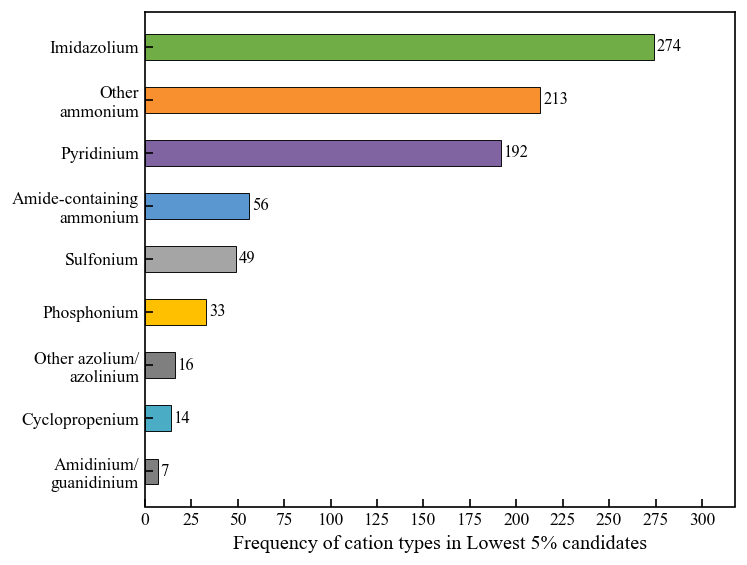

已保存图片及图数据：Lowest5pct_nonhalide_candidate_cation_type_frequency
PNG：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\PNG\Lowest5pct_nonhalide_candidate_cation_type_frequency.png
SVG：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\SVG\Lowest5pct_nonhalide_candidate_cation_type_frequency.svg
PDF：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\PDF\Lowest5pct_nonhalide_candidate_cation_type_frequency.pdf
CSV：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\CSV\Lowest5pct_nonhalide_candidate_cation_type_frequency.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\cation_type_frequency_lowest5pct.csv
已保存表格：D:\jupyter\IL_ML_Pr

,cation_type,frequency,candidate_set,candidate_set_display,candidate_count,percentage,display_order,display_label,color
0,Imidazolium,274,Lowest5pct,Lowest 5%,854,32.084309,1,Imidazolium,#70AD47
1,Other ammonium,213,Lowest5pct,Lowest 5%,854,24.941452,2,Other\nammonium,#F89030
2,Pyridinium,192,Lowest5pct,Lowest 5%,854,22.482436,3,Pyridinium,#8064A2
3,Amide-containing ammonium,56,Lowest5pct,Lowest 5%,854,6.557377,4,Amide-containing\nammonium,#5A97D0
4,Sulfonium,49,Lowest5pct,Lowest 5%,854,5.737705,5,Sulfonium,#A5A5A5
5,Phosphonium,33,Lowest5pct,Lowest 5%,854,3.864169,6,Phosphonium,#FFC000
6,Other azolium/azolinium,16,Lowest5pct,Lowest 5%,854,1.873536,7,Other azolium/\nazolinium,#7F7F7F
7,Cyclopropenium,14,Lowest5pct,Lowest 5%,854,1.639344,8,Cyclopropenium,#4BACC6
8,Amidinium/guanidinium,7,Lowest5pct,Lowest 5%,854,0.819672,9,Amidinium/\nguanidinium,#7F7F7F


In [7]:
# Cell 6 | 统计并绘制最低5%候选的阳离子类型频次

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator


# ============================================================
# 1. 检查必要对象
# ============================================================

required_cell6_objects = [
    "FINAL_LOWEST5PCT_CLASSIFIED_DF",
    "classified_candidate_set_manifest_path",
    "save_table",
    "save_json",
    "save_figure",
    "format_axes_consistently",
    "mm_to_data_x",
]

missing_cell6_objects = [
    object_name
    for object_name in required_cell6_objects
    if object_name not in globals()
]

if missing_cell6_objects:
    raise RuntimeError(
        "Cell 6缺少必要上游对象。"
        "\n请确认已经依次运行Cell 0～Cell 5。"
        f"\n缺少对象：{missing_cell6_objects}"
    )


# ============================================================
# 2. 正式输出名称与横坐标名称
# ============================================================

CATION_FIGURE_NAME = (
    "Lowest5pct_nonhalide_candidate_"
    "cation_type_frequency"
)

CATION_X_AXIS_LABEL = (
    "Frequency of cation types "
    "in Lowest 5% candidates"
)


# ============================================================
# 3. 清理同名旧记录
# ============================================================

GENERATED_FIGURE_RECORDS[:] = [
    record
    for record in GENERATED_FIGURE_RECORDS
    if record.get("figure_name")
    != CATION_FIGURE_NAME
]

CELL6_TABLE_FILENAMES = {
    "cation_type_frequency_lowest5pct.csv",
    "cation_type_frequency_wide.csv",
    "cation_type_frequency_integrity_audit.csv",
}

GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if record.get("filename")
    not in CELL6_TABLE_FILENAMES
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if record.get("filename")
    != "cation_type_frequency_manifest.json"
]


# ============================================================
# 4. 阳离子标签和颜色
# ============================================================

CATION_TYPE_LABEL_MAP = {
    "Amide-containing ammonium": (
        "Amide-containing\nammonium"
    ),
    "Other ammonium": (
        "Other\nammonium"
    ),
    "Imidazolium": "Imidazolium",
    "Pyridinium": "Pyridinium",
    "Pyrrolidinium": "Pyrrolidinium",
    "Pyrrolidinium/azolinium": (
        "Pyrrolidinium/\nazolinium"
    ),
    "Other azolium/azolinium": (
        "Other azolium/\nazolinium"
    ),
    "Sulfonium": "Sulfonium",
    "Phosphonium": "Phosphonium",
    "Cyclopropenium": "Cyclopropenium",
    "Amidinium/guanidinium": (
        "Amidinium/\nguanidinium"
    ),
}

CATION_TYPE_COLOR_MAP = {
    "Amide-containing ammonium": BLUE,
    "Other ammonium": ORANGE,
    "Imidazolium": "#70AD47",
    "Pyridinium": "#8064A2",
    "Pyrrolidinium": "#7F7F7F",
    "Pyrrolidinium/azolinium": "#7F7F7F",
    "Other azolium/azolinium": "#7F7F7F",
    "Sulfonium": "#A5A5A5",
    "Phosphonium": "#FFC000",
    "Cyclopropenium": "#4BACC6",
    "Amidinium/guanidinium": "#7F7F7F",
}


# ============================================================
# 5. 统计阳离子类型频次
# ============================================================

cation_type_frequency_df = (
    FINAL_LOWEST5PCT_CLASSIFIED_DF[
        "cation_type"
    ]
    .value_counts(dropna=False)
    .rename_axis("cation_type")
    .reset_index(name="frequency")
    .sort_values(
        by=[
            "frequency",
            "cation_type",
        ],
        ascending=[
            False,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

cation_type_frequency_df[
    "candidate_set"
] = "Lowest5pct"

cation_type_frequency_df[
    "candidate_set_display"
] = "Lowest 5%"

cation_type_frequency_df[
    "candidate_count"
] = len(
    FINAL_LOWEST5PCT_CLASSIFIED_DF
)

cation_type_frequency_df[
    "percentage"
] = (
    cation_type_frequency_df[
        "frequency"
    ]
    / len(
        FINAL_LOWEST5PCT_CLASSIFIED_DF
    )
    * 100.0
)

cation_type_frequency_df[
    "display_order"
] = np.arange(
    1,
    len(cation_type_frequency_df) + 1,
    dtype=int,
)

cation_type_frequency_df[
    "display_label"
] = (
    cation_type_frequency_df[
        "cation_type"
    ]
    .map(CATION_TYPE_LABEL_MAP)
    .fillna(
        cation_type_frequency_df[
            "cation_type"
        ]
    )
)

cation_type_frequency_df[
    "color"
] = (
    cation_type_frequency_df[
        "cation_type"
    ]
    .map(CATION_TYPE_COLOR_MAP)
    .fillna("#808080")
)

cation_type_frequency_wide_df = (
    cation_type_frequency_df[
        [
            "cation_type",
            "frequency",
            "percentage",
        ]
    ]
    .copy()
)


# ============================================================
# 6. 统计结果审计
# ============================================================

cation_audit_records = [
    {
        "check_item": "候选数量",
        "expected": 854,
        "actual": int(
            len(
                FINAL_LOWEST5PCT_CLASSIFIED_DF
            )
        ),
        "passed": bool(
            len(
                FINAL_LOWEST5PCT_CLASSIFIED_DF
            )
            == 854
        ),
    },
    {
        "check_item": "阳离子频次合计",
        "expected": 854,
        "actual": int(
            cation_type_frequency_df[
                "frequency"
            ].sum()
        ),
        "passed": bool(
            cation_type_frequency_df[
                "frequency"
            ].sum()
            == 854
        ),
    },
    {
        "check_item": "百分比合计约为100%",
        "expected": True,
        "actual": bool(
            np.isclose(
                cation_type_frequency_df[
                    "percentage"
                ].sum(),
                100.0,
                atol=1e-10,
                rtol=0.0,
            )
        ),
        "passed": bool(
            np.isclose(
                cation_type_frequency_df[
                    "percentage"
                ].sum(),
                100.0,
                atol=1e-10,
                rtol=0.0,
            )
        ),
    },
]

cation_type_frequency_audit_df = (
    pd.DataFrame(
        cation_audit_records
    )
)

if not cation_type_frequency_audit_df[
    "passed"
].all():
    display(
        cation_type_frequency_audit_df
    )

    raise RuntimeError(
        "Cell 6阳离子类型频次审计未通过。"
    )


# ============================================================
# 7. 主刻度间隔函数
# ============================================================

def choose_major_tick_interval(
    maximum_count,
):
    maximum_count = int(
        maximum_count
    )

    if maximum_count <= 10:
        return 2

    if maximum_count <= 30:
        return 5

    if maximum_count <= 100:
        return 10

    if maximum_count <= 300:
        return 25

    if maximum_count <= 700:
        return 50

    return 100


# ============================================================
# 8. 绘制完整阳离子类型频次图
# ============================================================

plot_df = (
    cation_type_frequency_df
    .sort_values(
        "display_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

category_count = int(
    len(plot_df)
)

figure_height = max(
    2.8,
    0.48 * category_count + 0.90,
)

figure, axis = plt.subplots(
    figsize=(
        8.00,
        figure_height,
    )
)

y_positions = np.arange(
    category_count
)

axis.barh(
    y_positions,
    plot_df[
        "frequency"
    ].to_numpy(dtype=float),
    height=0.48,
    color=plot_df[
        "color"
    ].tolist(),
    edgecolor="black",
    linewidth=0.55,
)

axis.set_yticks(
    y_positions
)

axis.set_yticklabels(
    plot_df[
        "display_label"
    ].tolist()
)

axis.invert_yaxis()

axis.set_xlabel(
    CATION_X_AXIS_LABEL
)

axis.set_ylabel("")

maximum_count = int(
    plot_df[
        "frequency"
    ].max()
)

x_margin = max(
    1.5,
    maximum_count * 0.16,
)

axis.set_xlim(
    0,
    maximum_count + x_margin,
)

axis.xaxis.set_major_locator(
    MultipleLocator(
        choose_major_tick_interval(
            maximum_count
        )
    )
)

format_axes_consistently(
    axis
)

axis.grid(False)

figure.canvas.draw()

label_offset = mm_to_data_x(
    axis,
    mm=0.8,
)

for (
    y_position,
    frequency,
) in zip(
    y_positions,
    plot_df[
        "frequency"
    ].to_numpy(dtype=int),
):
    axis.text(
        frequency + label_offset,
        y_position,
        str(frequency),
        ha="left",
        va="center",
        fontsize=10.0,
        family="Times New Roman",
    )

figure.subplots_adjust(
    left=0.35,
    right=0.965,
    bottom=0.18,
    top=0.97,
)

cation_figure_record = (
    save_figure(
        figure=figure,
        base_name=(
            CATION_FIGURE_NAME
        ),
        data_df=plot_df,
        tight=True,
    )
)


# ============================================================
# 9. 保存表格
# ============================================================

cation_type_frequency_path = (
    save_table(
        cation_type_frequency_df,
        "cation_type_frequency_lowest5pct.csv",
        index=False,
    )
)

cation_type_frequency_wide_path = (
    save_table(
        cation_type_frequency_wide_df,
        "cation_type_frequency_wide.csv",
        index=False,
    )
)

cation_type_frequency_audit_path = (
    save_table(
        cation_type_frequency_audit_df,
        (
            "cation_type_frequency_"
            "integrity_audit.csv"
        ),
        index=False,
    )
)


# ============================================================
# 10. 保存manifest
# ============================================================

cell6_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "lowest5pct_cation_type_"
        "frequency_completed"
    ),
    "candidate_set": "Lowest5pct",
    "candidate_set_display": "Lowest 5%",
    "candidate_count": 854,
    "x_axis_label": (
        CATION_X_AXIS_LABEL
    ),
    "Top20_included": False,
    "Top50_included": False,
    "Top100_included": False,
    "source_manifest": {
        "path": str(
            classified_candidate_set_manifest_path.resolve()
        ),
        "sha256": sha256_file(
            classified_candidate_set_manifest_path
        ),
    },
    "outputs": {
        "frequency_table": {
            "path": str(
                cation_type_frequency_path.resolve()
            ),
            "sha256": sha256_file(
                cation_type_frequency_path
            ),
        },
        "wide_table": {
            "path": str(
                cation_type_frequency_wide_path.resolve()
            ),
            "sha256": sha256_file(
                cation_type_frequency_wide_path
            ),
        },
        "integrity_audit": {
            "path": str(
                cation_type_frequency_audit_path.resolve()
            ),
            "sha256": sha256_file(
                cation_type_frequency_audit_path
            ),
        },
        "figure": (
            cation_figure_record
        ),
    },
    "audit_summary": {
        "total_checks": int(
            len(
                cation_type_frequency_audit_df
            )
        ),
        "failed_checks": int(
            (
                ~cation_type_frequency_audit_df[
                    "passed"
                ]
            ).sum()
        ),
        "all_passed": bool(
            cation_type_frequency_audit_df[
                "passed"
            ].all()
        ),
    },
}

cation_type_frequency_manifest_path = (
    save_json(
        cell6_manifest,
        "cation_type_frequency_manifest.json",
    )
)


# ============================================================
# 11. 固定后续使用对象
# ============================================================

FORMAL_CATION_TYPE_FREQUENCY_DF = (
    cation_type_frequency_df
)


print("=" * 100)
print(
    "Cell 6最低5%阳离子类型频次完成 ✓"
)
print("=" * 100)

display(
    cation_type_frequency_df
)

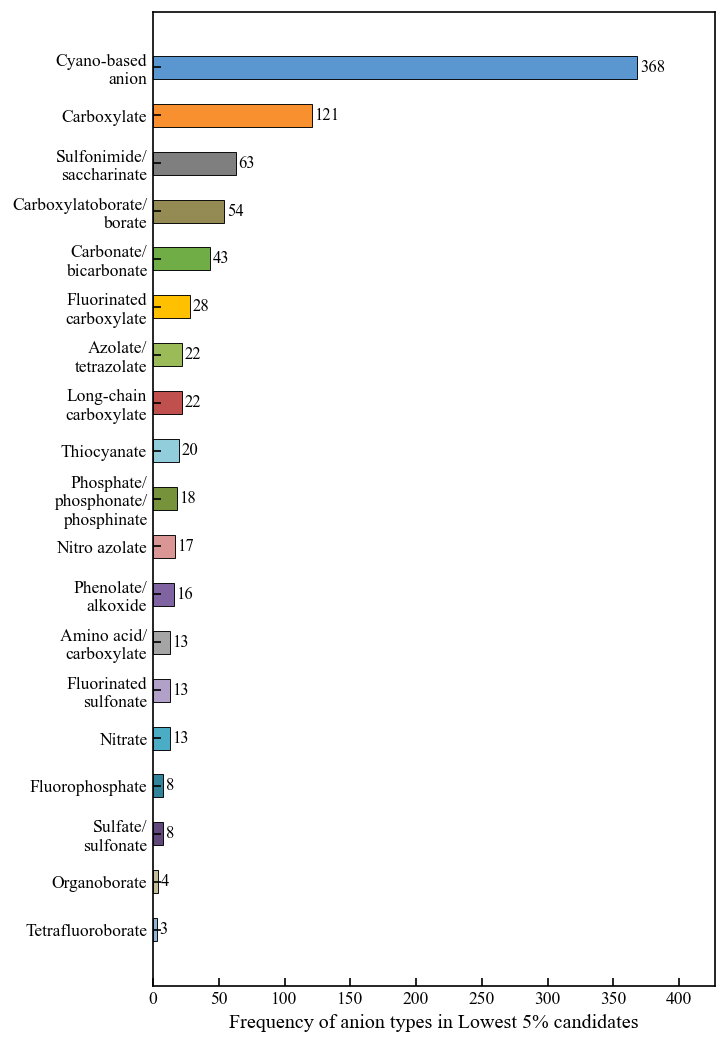

已保存图片及图数据：Lowest5pct_nonhalide_candidate_anion_type_frequency
PNG：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\PNG\Lowest5pct_nonhalide_candidate_anion_type_frequency.png
SVG：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\SVG\Lowest5pct_nonhalide_candidate_anion_type_frequency.svg
PDF：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\PDF\Lowest5pct_nonhalide_candidate_anion_type_frequency.pdf
CSV：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\CSV\Lowest5pct_nonhalide_candidate_anion_type_frequency.csv


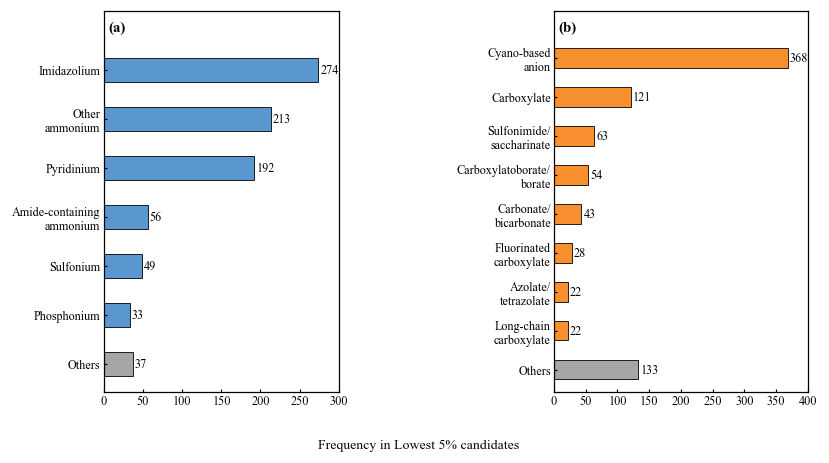

已保存图片及图数据：Lowest5pct_nonhalide_candidate_cation_anion_type_frequency_combined
PNG：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\PNG\Lowest5pct_nonhalide_candidate_cation_anion_type_frequency_combined.png
SVG：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\SVG\Lowest5pct_nonhalide_candidate_cation_anion_type_frequency_combined.svg
PDF：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\PDF\Lowest5pct_nonhalide_candidate_cation_anion_type_frequency_combined.pdf
CSV：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\CSV\Lowest5pct_nonhalide_candidate_cation_anion_type_frequency_combined.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_ana

,ion_role,original_type,display_label,frequency,percentage,is_aggregated,included_type_count,included_types,display_order
0,cation,Imidazolium,Imidazolium,274,32.084309,False,1,Imidazolium,1
1,cation,Other ammonium,Other\nammonium,213,24.941452,False,1,Other ammonium,2
2,cation,Pyridinium,Pyridinium,192,22.482436,False,1,Pyridinium,3
3,cation,Amide-containing ammonium,Amide-containing\nammonium,56,6.557377,False,1,Amide-containing ammonium,4
4,cation,Sulfonium,Sulfonium,49,5.737705,False,1,Sulfonium,5
5,cation,Phosphonium,Phosphonium,33,3.864169,False,1,Phosphonium,6
6,cation,Others,Others,37,4.332553,True,3,Other azolium/azolinium | Cyclopropenium | Ami...,7
7,anion,Cyano-based anion,Cyano-based\nanion,368,43.091335,False,1,Cyano-based anion,1
8,anion,Carboxylate,Carboxylate,121,14.168618,False,1,Carboxylate,2
9,anion,Sulfonimide/saccharinate,Sulfonimide/\nsaccharinate,63,7.377049,False,1,Sulfonimide/saccharinate,3


,check_item,expected,actual,passed
0,组合图阳离子频次合计,854,854,True
1,组合图阴离子频次合计,854,854,True
2,阳离子Others频次,37,37,True
3,阳离子Others合并类型数,3,3,True
4,阴离子Others频次,133,133,True


In [13]:
# Cell 7 | 绘制完整阴离子频次图及正文用阴阳离子组合图

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator


# ============================================================
# 1. 检查必要对象
# ============================================================

required_cell7_objects = [
    "FINAL_LOWEST5PCT_CLASSIFIED_DF",
    "FORMAL_CATION_TYPE_FREQUENCY_DF",
    "CATION_TYPE_LABEL_MAP",
    "cation_type_frequency_manifest_path",
    "save_table",
    "save_json",
    "save_figure",
    "format_axes_consistently",
    "mm_to_data_x",
    "choose_major_tick_interval",
    "sha256_file",
    "BLUE",
    "ORANGE",
    "GENERATED_FIGURE_RECORDS",
    "GENERATED_TABLE_RECORDS",
    "GENERATED_LOG_RECORDS",
]

missing_cell7_objects = [
    object_name
    for object_name in required_cell7_objects
    if object_name not in globals()
]

if missing_cell7_objects:
    raise RuntimeError(
        "Cell 7缺少必要上游对象。"
        "\n请确认已经运行修改后的Cell 5和Cell 6。"
        f"\n缺少对象：{missing_cell7_objects}"
    )


# ============================================================
# 2. 正式输出名称与绘图参数
# ============================================================

ANION_FIGURE_NAME = (
    "Lowest5pct_nonhalide_candidate_"
    "anion_type_frequency"
)

COMBINED_FIGURE_NAME = (
    "Lowest5pct_nonhalide_candidate_"
    "cation_anion_type_frequency_combined"
)

ANION_X_AXIS_LABEL = (
    "Frequency of anion types "
    "in Lowest 5% candidates"
)

COMBINED_X_AXIS_LABEL = (
    "Frequency in Lowest 5% candidates"
)

# 阳离子保留前6类，剩余3类合并为Others。
COMBINED_CATION_TOP_N = 6

# 阴离子保留前8类，剩余11类合并为Others。
COMBINED_ANION_TOP_N = 8

COMBINED_MAJOR_TICK_INTERVAL = 50
COMBINED_TICK_LENGTH_PT = 2.0
COMBINED_TICK_WIDTH_PT = 0.7


# ============================================================
# 3. 清理本Cell旧记录
# ============================================================

CELL7_FIGURE_NAMES = {
    ANION_FIGURE_NAME,
    COMBINED_FIGURE_NAME,
}

GENERATED_FIGURE_RECORDS[:] = [
    record
    for record in GENERATED_FIGURE_RECORDS
    if record.get("figure_name")
    not in CELL7_FIGURE_NAMES
]

CELL7_TABLE_FILENAMES = {
    "anion_type_frequency_lowest5pct.csv",
    "anion_type_frequency_wide.csv",
    "anion_type_frequency_integrity_audit.csv",
    "lowest5pct_cation_anion_type_frequency_compact.csv",
    "lowest5pct_cation_anion_type_frequency_compact_audit.csv",
}

GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if record.get("filename")
    not in CELL7_TABLE_FILENAMES
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if record.get("filename")
    != "anion_type_frequency_manifest.json"
]


# ============================================================
# 4. 阴离子标签与颜色
# ============================================================

ANION_TYPE_LABEL_MAP = {
    "Carbonate/bicarbonate": "Carbonate/\nbicarbonate",
    "Cyano-based anion": "Cyano-based\nanion",
    "Phenolate/alkoxide": "Phenolate/\nalkoxide",
    "Amino acid/carboxylate": "Amino acid/\ncarboxylate",
    "Carboxylate": "Carboxylate",
    "Fluorinated carboxylate": "Fluorinated\ncarboxylate",
    "Nitrate": "Nitrate",
    "Long-chain carboxylate": "Long-chain\ncarboxylate",
    "Azolate/tetrazolate": "Azolate/\ntetrazolate",
    "Carboxylatoborate/borate": "Carboxylatoborate/\nborate",
    "Sulfonimide/saccharinate": "Sulfonimide/\nsaccharinate",
    "Thiocyanate": "Thiocyanate",
    "Fluorinated sulfonate": "Fluorinated\nsulfonate",
    "Nitro azolate": "Nitro azolate",
    "Phosphate/phosphonate/phosphinate": (
        "Phosphate/\nphosphonate/\nphosphinate"
    ),
    "Fluorophosphate": "Fluorophosphate",
    "Organoborate": "Organoborate",
    "Sulfate/sulfonate": "Sulfate/\nsulfonate",
    "Tetrafluoroborate": "Tetrafluoroborate",
}

ANION_TYPE_COLOR_MAP = {
    "Cyano-based anion": BLUE,
    "Carboxylate": ORANGE,
    "Carbonate/bicarbonate": "#70AD47",
    "Phenolate/alkoxide": "#8064A2",
    "Amino acid/carboxylate": "#A5A5A5",
    "Fluorinated carboxylate": "#FFC000",
    "Nitrate": "#4BACC6",
    "Long-chain carboxylate": "#C0504D",
    "Azolate/tetrazolate": "#9BBB59",
    "Carboxylatoborate/borate": "#948A54",
    "Sulfonimide/saccharinate": "#7F7F7F",
    "Thiocyanate": "#92CDDC",
    "Fluorinated sulfonate": "#B1A0C7",
    "Nitro azolate": "#D99694",
    "Phosphate/phosphonate/phosphinate": "#76933C",
    "Fluorophosphate": "#31859B",
    "Organoborate": "#C4BD97",
    "Sulfate/sulfonate": "#60497A",
    "Tetrafluoroborate": "#95B3D7",
}


# ============================================================
# 5. 统计完整阴离子类型频次
# ============================================================

anion_type_frequency_df = (
    FINAL_LOWEST5PCT_CLASSIFIED_DF["anion_type"]
    .value_counts(dropna=False)
    .rename_axis("anion_type")
    .reset_index(name="frequency")
    .sort_values(
        by=["frequency", "anion_type"],
        ascending=[False, True],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

anion_type_frequency_df["candidate_set"] = "Lowest5pct"
anion_type_frequency_df["candidate_set_display"] = "Lowest 5%"
anion_type_frequency_df["candidate_count"] = len(
    FINAL_LOWEST5PCT_CLASSIFIED_DF
)

anion_type_frequency_df["percentage"] = (
    anion_type_frequency_df["frequency"]
    / len(FINAL_LOWEST5PCT_CLASSIFIED_DF)
    * 100.0
)

anion_type_frequency_df["display_order"] = np.arange(
    1,
    len(anion_type_frequency_df) + 1,
    dtype=int,
)

anion_type_frequency_df["display_label"] = (
    anion_type_frequency_df["anion_type"]
    .map(ANION_TYPE_LABEL_MAP)
    .fillna(anion_type_frequency_df["anion_type"])
)

anion_type_frequency_df["color"] = (
    anion_type_frequency_df["anion_type"]
    .map(ANION_TYPE_COLOR_MAP)
    .fillna("#808080")
)

anion_type_frequency_wide_df = (
    anion_type_frequency_df[
        [
            "anion_type",
            "frequency",
            "percentage",
        ]
    ]
    .copy()
)


# ============================================================
# 6. 完整阴离子统计审计
# ============================================================

anion_type_frequency_audit_df = pd.DataFrame(
    [
        {
            "check_item": "候选数量",
            "expected": 854,
            "actual": len(FINAL_LOWEST5PCT_CLASSIFIED_DF),
            "passed": (
                len(FINAL_LOWEST5PCT_CLASSIFIED_DF)
                == 854
            ),
        },
        {
            "check_item": "阴离子频次合计",
            "expected": 854,
            "actual": int(
                anion_type_frequency_df["frequency"].sum()
            ),
            "passed": (
                int(
                    anion_type_frequency_df[
                        "frequency"
                    ].sum()
                )
                == 854
            ),
        },
        {
            "check_item": "阴离子类型数量",
            "expected": 19,
            "actual": len(anion_type_frequency_df),
            "passed": len(anion_type_frequency_df) == 19,
        },
        {
            "check_item": "百分比合计约为100%",
            "expected": True,
            "actual": bool(
                np.isclose(
                    anion_type_frequency_df[
                        "percentage"
                    ].sum(),
                    100.0,
                    atol=1e-10,
                    rtol=0.0,
                )
            ),
            "passed": bool(
                np.isclose(
                    anion_type_frequency_df[
                        "percentage"
                    ].sum(),
                    100.0,
                    atol=1e-10,
                    rtol=0.0,
                )
            ),
        },
    ]
)

if not anion_type_frequency_audit_df["passed"].all():
    display(anion_type_frequency_audit_df)
    raise RuntimeError(
        "Cell 7阴离子类型频次审计未通过。"
    )


# ============================================================
# 7. 绘制完整阴离子类型频次图
# ============================================================

anion_plot_df = (
    anion_type_frequency_df
    .sort_values(
        "display_order",
        kind="mergesort",
    )
    .reset_index(drop=True)
)

anion_figure_height = max(
    3.0,
    0.48 * len(anion_plot_df) + 0.90,
)

anion_figure, anion_axis = plt.subplots(
    figsize=(8.00, anion_figure_height)
)

anion_y_positions = np.arange(
    len(anion_plot_df)
)

anion_axis.barh(
    anion_y_positions,
    anion_plot_df["frequency"].to_numpy(
        dtype=float
    ),
    height=0.48,
    color=anion_plot_df["color"].tolist(),
    edgecolor="black",
    linewidth=0.55,
)

anion_axis.set_yticks(anion_y_positions)
anion_axis.set_yticklabels(
    anion_plot_df["display_label"].tolist()
)
anion_axis.invert_yaxis()

anion_axis.set_xlabel(ANION_X_AXIS_LABEL)
anion_axis.set_ylabel("")

anion_maximum_count = int(
    anion_plot_df["frequency"].max()
)

anion_axis.set_xlim(
    0,
    anion_maximum_count
    + max(
        1.5,
        anion_maximum_count * 0.16,
    ),
)

anion_axis.xaxis.set_major_locator(
    MultipleLocator(
        choose_major_tick_interval(
            anion_maximum_count
        )
    )
)

format_axes_consistently(anion_axis)
anion_axis.grid(False)

anion_figure.canvas.draw()

anion_label_offset = mm_to_data_x(
    anion_axis,
    mm=0.8,
)

for y_position, frequency in zip(
    anion_y_positions,
    anion_plot_df["frequency"].to_numpy(
        dtype=int
    ),
):
    anion_axis.text(
        frequency + anion_label_offset,
        y_position,
        str(frequency),
        ha="left",
        va="center",
        fontsize=10.0,
        family="Times New Roman",
    )

anion_figure.subplots_adjust(
    left=0.38,
    right=0.965,
    bottom=0.17,
    top=0.98,
)

anion_figure_record = save_figure(
    figure=anion_figure,
    base_name=ANION_FIGURE_NAME,
    data_df=anion_plot_df,
    tight=True,
)


# ============================================================
# 8. 构建正文组合图数据
# ============================================================

def build_compact_frequency_panel(
    source_dataframe,
    type_column,
    ion_role,
    label_map,
    top_n,
):
    working_df = (
        source_dataframe
        .sort_values(
            by=["frequency", type_column],
            ascending=[False, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
        .copy()
    )

    top_df = (
        working_df
        .head(top_n)
        .copy()
        .reset_index(drop=True)
    )

    remaining_df = (
        working_df
        .iloc[top_n:]
        .copy()
        .reset_index(drop=True)
    )

    records = []

    for _, row in top_df.iterrows():
        original_type = str(row[type_column])

        records.append(
            {
                "ion_role": ion_role,
                "original_type": original_type,
                "display_label": label_map.get(
                    original_type,
                    original_type,
                ),
                "frequency": int(row["frequency"]),
                "percentage": float(
                    row["percentage"]
                ),
                "is_aggregated": False,
                "included_type_count": 1,
                "included_types": original_type,
            }
        )

    if not remaining_df.empty:
        records.append(
            {
                "ion_role": ion_role,
                "original_type": "Others",
                "display_label": "Others",
                "frequency": int(
                    remaining_df["frequency"].sum()
                ),
                "percentage": float(
                    remaining_df["percentage"].sum()
                ),
                "is_aggregated": True,
                "included_type_count": int(
                    len(remaining_df)
                ),
                "included_types": " | ".join(
                    remaining_df[
                        type_column
                    ]
                    .astype(str)
                    .tolist()
                ),
            }
        )

    compact_df = pd.DataFrame(records)

    compact_df["display_order"] = np.arange(
        1,
        len(compact_df) + 1,
        dtype=int,
    )

    return compact_df


compact_cation_df = build_compact_frequency_panel(
    source_dataframe=FORMAL_CATION_TYPE_FREQUENCY_DF,
    type_column="cation_type",
    ion_role="cation",
    label_map=CATION_TYPE_LABEL_MAP,
    top_n=COMBINED_CATION_TOP_N,
)

compact_anion_df = build_compact_frequency_panel(
    source_dataframe=anion_type_frequency_df,
    type_column="anion_type",
    ion_role="anion",
    label_map=ANION_TYPE_LABEL_MAP,
    top_n=COMBINED_ANION_TOP_N,
)

combined_frequency_plot_df = pd.concat(
    [
        compact_cation_df,
        compact_anion_df,
    ],
    ignore_index=True,
)


# ============================================================
# 9. 核对新的Others数值
# ============================================================

cation_others_df = compact_cation_df.loc[
    compact_cation_df[
        "original_type"
    ].eq("Others")
].copy()

if len(cation_others_df) != 1:
    raise RuntimeError(
        "阳离子组合图中未得到唯一的Others行。"
    )

cation_others_frequency = int(
    cation_others_df["frequency"].iloc[0]
)

cation_others_type_count = int(
    cation_others_df[
        "included_type_count"
    ].iloc[0]
)

cation_others_included_types = str(
    cation_others_df[
        "included_types"
    ].iloc[0]
)

expected_cation_others_types = {
    "Other azolium/azolinium",
    "Cyclopropenium",
    "Amidinium/guanidinium",
}

actual_cation_others_types = set(
    cation_others_included_types.split(" | ")
)

if cation_others_frequency != 37:
    raise RuntimeError(
        "阳离子Others频次不是37。"
        f"\n实际频次：{cation_others_frequency}"
    )

if cation_others_type_count != 3:
    raise RuntimeError(
        "阳离子Others未合并3种低频类型。"
        f"\n实际类型数：{cation_others_type_count}"
    )

if (
    actual_cation_others_types
    != expected_cation_others_types
):
    raise RuntimeError(
        "阳离子Others包含的类型不正确。"
        f"\n实际类型：{actual_cation_others_types}"
    )


# ============================================================
# 10. 组合图数据审计
# ============================================================

combined_frequency_audit_df = pd.DataFrame(
    [
        {
            "check_item": "组合图阳离子频次合计",
            "expected": 854,
            "actual": int(
                compact_cation_df[
                    "frequency"
                ].sum()
            ),
            "passed": (
                int(
                    compact_cation_df[
                        "frequency"
                    ].sum()
                )
                == 854
            ),
        },
        {
            "check_item": "组合图阴离子频次合计",
            "expected": 854,
            "actual": int(
                compact_anion_df[
                    "frequency"
                ].sum()
            ),
            "passed": (
                int(
                    compact_anion_df[
                        "frequency"
                    ].sum()
                )
                == 854
            ),
        },
        {
            "check_item": "阳离子Others频次",
            "expected": 37,
            "actual": cation_others_frequency,
            "passed": cation_others_frequency == 37,
        },
        {
            "check_item": "阳离子Others合并类型数",
            "expected": 3,
            "actual": cation_others_type_count,
            "passed": cation_others_type_count == 3,
        },
        {
            "check_item": "阴离子Others频次",
            "expected": 133,
            "actual": int(
                compact_anion_df.loc[
                    compact_anion_df[
                        "original_type"
                    ].eq("Others"),
                    "frequency",
                ].iloc[0]
            ),
            "passed": (
                int(
                    compact_anion_df.loc[
                        compact_anion_df[
                            "original_type"
                        ].eq("Others"),
                        "frequency",
                    ].iloc[0]
                )
                == 133
            ),
        },
    ]
)

if not combined_frequency_audit_df["passed"].all():
    display(combined_frequency_audit_df)
    raise RuntimeError(
        "正文组合频次图数据审计未通过。"
    )


# ============================================================
# 11. 绘制正文双面板组合图
# ============================================================

def calculate_compact_axis_upper(
    maximum_count,
    tick_interval=50,
):
    label_room = max(
        4.0,
        float(maximum_count) * 0.035,
    )

    axis_upper = (
        np.ceil(
            (
                float(maximum_count)
                + label_room
            )
            / tick_interval
        )
        * tick_interval
    )

    return max(
        float(tick_interval),
        float(axis_upper),
    )


def draw_compact_frequency_panel(
    axis,
    plot_dataframe,
    panel_label,
    bar_color,
):
    plot_df = (
        plot_dataframe
        .sort_values(
            "display_order",
            kind="mergesort",
        )
        .reset_index(drop=True)
        .copy()
    )

    y_positions = np.arange(
        len(plot_df)
    )

    bar_colors = [
        (
            "#A6A6A6"
            if is_aggregated
            else bar_color
        )
        for is_aggregated
        in plot_df["is_aggregated"].tolist()
    ]

    axis.barh(
        y_positions,
        plot_df["frequency"].to_numpy(
            dtype=float
        ),
        height=0.50,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.50,
    )

    axis.set_yticks(y_positions)
    axis.set_yticklabels(
        plot_df["display_label"].tolist(),
        fontsize=7.4,
        family="Times New Roman",
    )

    axis.invert_yaxis()

    axis.set_ylim(
        len(plot_df) - 0.42,
        -1.20,
    )

    axis.set_xlabel("")
    axis.set_ylabel("")

    maximum_count = int(
        plot_df["frequency"].max()
    )

    axis.set_xlim(
        0,
        calculate_compact_axis_upper(
            maximum_count,
            COMBINED_MAJOR_TICK_INTERVAL,
        ),
    )

    axis.xaxis.set_major_locator(
        MultipleLocator(
            COMBINED_MAJOR_TICK_INTERVAL
        )
    )

    format_axes_consistently(axis)
    axis.grid(False)

    axis.tick_params(
        axis="both",
        which="major",
        labelsize=7.3,
        length=COMBINED_TICK_LENGTH_PT,
        width=COMBINED_TICK_WIDTH_PT,
        pad=2.0,
        direction="in",
        top=False,
        right=False,
    )

    for side in [
        "top",
        "right",
        "bottom",
        "left",
    ]:
        axis.spines[side].set_linewidth(0.75)

    axis.figure.canvas.draw()

    label_offset = mm_to_data_x(
        axis,
        mm=0.55,
    )

    for y_position, frequency in zip(
        y_positions,
        plot_df["frequency"].to_numpy(
            dtype=int
        ),
    ):
        axis.text(
            frequency + label_offset,
            y_position,
            str(frequency),
            ha="left",
            va="center",
            fontsize=7.3,
            family="Times New Roman",
            clip_on=False,
        )

    axis.text(
        0.018,
        0.975,
        panel_label,
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=9.0,
        fontweight="bold",
        family="Times New Roman",
    )


combined_figure, (
    cation_axis,
    compact_anion_axis,
) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(7.20, 3.85),
    gridspec_kw={
        "width_ratios": [1.00, 1.08],
    },
)

draw_compact_frequency_panel(
    axis=cation_axis,
    plot_dataframe=compact_cation_df,
    panel_label="(a)",
    bar_color=BLUE,
)

draw_compact_frequency_panel(
    axis=compact_anion_axis,
    plot_dataframe=compact_anion_df,
    panel_label="(b)",
    bar_color=ORANGE,
)

combined_figure.text(
    0.54,
    0.046,
    COMBINED_X_AXIS_LABEL,
    ha="center",
    va="center",
    fontsize=8.3,
    family="Times New Roman",
)

combined_figure.subplots_adjust(
    left=0.175,
    right=0.990,
    bottom=0.160,
    top=0.985,
    wspace=0.88,
)

combined_figure_record = save_figure(
    figure=combined_figure,
    base_name=COMBINED_FIGURE_NAME,
    data_df=combined_frequency_plot_df,
    tight=True,
)


# ============================================================
# 12. 保存表格
# ============================================================

anion_type_frequency_path = save_table(
    anion_type_frequency_df,
    "anion_type_frequency_lowest5pct.csv",
    index=False,
)

anion_type_frequency_wide_path = save_table(
    anion_type_frequency_wide_df,
    "anion_type_frequency_wide.csv",
    index=False,
)

anion_type_frequency_audit_path = save_table(
    anion_type_frequency_audit_df,
    "anion_type_frequency_integrity_audit.csv",
    index=False,
)

combined_frequency_table_path = save_table(
    combined_frequency_plot_df,
    "lowest5pct_cation_anion_type_frequency_compact.csv",
    index=False,
)

combined_frequency_audit_path = save_table(
    combined_frequency_audit_df,
    (
        "lowest5pct_cation_anion_"
        "type_frequency_compact_audit.csv"
    ),
    index=False,
)


# ============================================================
# 13. 保存manifest
# ============================================================

cell7_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "lowest5pct_anion_and_combined_"
        "type_frequency_completed"
    ),
    "candidate_set": "Lowest5pct",
    "candidate_set_display": "Lowest 5%",
    "candidate_count": 854,
    "main_text_combined_figure": {
        "cation_top_n": COMBINED_CATION_TOP_N,
        "anion_top_n": COMBINED_ANION_TOP_N,
        "cation_others_frequency": (
            cation_others_frequency
        ),
        "cation_others_type_count": (
            cation_others_type_count
        ),
        "cation_others_included_types": (
            sorted(actual_cation_others_types)
        ),
        "anion_others_frequency": 133,
        "remaining_categories_aggregated_as": (
            "Others"
        ),
        "panel_a": "cation types",
        "panel_b": "anion types",
        "x_axis_label": COMBINED_X_AXIS_LABEL,
    },
    "Top20_included": False,
    "Top50_included": False,
    "Top100_included": False,
    "source_manifest": {
        "path": str(
            cation_type_frequency_manifest_path.resolve()
        ),
        "sha256": sha256_file(
            cation_type_frequency_manifest_path
        ),
    },
    "outputs": {
        "anion_frequency_table": str(
            anion_type_frequency_path.resolve()
        ),
        "complete_anion_figure": (
            anion_figure_record
        ),
        "combined_main_figure": (
            combined_figure_record
        ),
        "combined_main_figure_table": str(
            combined_frequency_table_path.resolve()
        ),
        "combined_main_figure_audit": str(
            combined_frequency_audit_path.resolve()
        ),
    },
    "audit_summary": {
        "total_checks": int(
            len(anion_type_frequency_audit_df)
            + len(combined_frequency_audit_df)
        ),
        "failed_checks": int(
            (
                ~anion_type_frequency_audit_df[
                    "passed"
                ]
            ).sum()
            + (
                ~combined_frequency_audit_df[
                    "passed"
                ]
            ).sum()
        ),
        "all_passed": bool(
            anion_type_frequency_audit_df[
                "passed"
            ].all()
            and combined_frequency_audit_df[
                "passed"
            ].all()
        ),
    },
}

anion_type_frequency_manifest_path = save_json(
    cell7_manifest,
    "anion_type_frequency_manifest.json",
)


# ============================================================
# 14. 固定后续使用对象
# ============================================================

FORMAL_ANION_TYPE_FREQUENCY_DF = (
    anion_type_frequency_df
)

FORMAL_COMBINED_ION_TYPE_FREQUENCY_DF = (
    combined_frequency_plot_df
)

FORMAL_COMBINED_ION_TYPE_FIGURE_RECORD = (
    combined_figure_record
)


print("=" * 100)
print(
    "Cell 7完整阴离子图及正文组合图生成完成 ✓"
)
print("=" * 100)

print(
    "阳离子Others频次："
    f"{cation_others_frequency}"
)

print(
    "阳离子Others包含："
    f"{cation_others_included_types}"
)

display(combined_frequency_plot_df)
display(combined_frequency_audit_df)

In [14]:
# Cell 8 | 按最低5%候选内部频次建立热图独立离子编号

from datetime import datetime

import numpy as np
import pandas as pd


# ============================================================
# 1. 检查必要对象
# ============================================================

required_cell8_objects = [
    "FINAL_LOWEST5PCT_CLASSIFIED_DF",
    "anion_type_frequency_manifest_path",
    "TABLE_DIR",
    "save_table",
    "save_json",
    "sha256_file",
    "GENERATED_TABLE_RECORDS",
    "GENERATED_LOG_RECORDS",
]

missing_cell8_objects = [
    object_name
    for object_name in required_cell8_objects
    if object_name not in globals()
]

if missing_cell8_objects:
    raise RuntimeError(
        "Cell 8缺少必要上游对象。"
        "\n请确认已经运行修改后的Cell 7。"
        f"\n缺少对象：{missing_cell8_objects}"
    )


# ============================================================
# 2. 文件名称
# ============================================================

CATION_AXIS_FILENAME = (
    "lowest5pct_cation_axis_"
    "frequency_order_for_heatmap.csv"
)

ANION_AXIS_FILENAME = (
    "lowest5pct_anion_axis_"
    "frequency_order_for_heatmap.csv"
)

PRED_ETA_MATRIX_FILENAME = (
    "lowest5pct_frequency_order_"
    "pred_eta_matrix.csv"
)

PRESENCE_MATRIX_FILENAME = (
    "lowest5pct_frequency_order_"
    "presence_matrix.csv"
)

HEATMAP_POINTS_FILENAME = (
    "lowest5pct_heatmap_points.csv"
)

HEATMAP_PREPARATION_SUMMARY_FILENAME = (
    "cation_anion_heatmap_"
    "preparation_summary.csv"
)

HEATMAP_PREPARATION_AUDIT_FILENAME = (
    "cation_anion_heatmap_"
    "preparation_integrity_audit.csv"
)

HEATMAP_PREPARATION_MANIFEST_FILENAME = (
    "cation_anion_heatmap_"
    "preparation_manifest.json"
)


# ============================================================
# 3. 删除旧编号方案文件
# ============================================================

old_heatmap_table_filenames = {
    "full_nonhalide_cation_axis_for_heatmap.csv",
    "full_nonhalide_anion_axis_for_heatmap.csv",
    "lowest5pct_full_pred_eta_matrix.csv",
    "lowest5pct_full_presence_matrix.csv",
}

for filename in old_heatmap_table_filenames:
    old_path = TABLE_DIR / filename

    if old_path.is_file():
        old_path.unlink()


CELL8_TABLE_FILENAMES = {
    CATION_AXIS_FILENAME,
    ANION_AXIS_FILENAME,
    PRED_ETA_MATRIX_FILENAME,
    PRESENCE_MATRIX_FILENAME,
    HEATMAP_POINTS_FILENAME,
    HEATMAP_PREPARATION_SUMMARY_FILENAME,
    HEATMAP_PREPARATION_AUDIT_FILENAME,
}.union(old_heatmap_table_filenames)

GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if record.get("filename")
    not in CELL8_TABLE_FILENAMES
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if record.get("filename")
    != HEATMAP_PREPARATION_MANIFEST_FILENAME
]


# ============================================================
# 4. 建立与黏度排名无关的频次排序编号
# ============================================================

def build_frequency_order_axis(
    candidate_dataframe,
    ion_role,
):
    if ion_role == "cation":
        smiles_column = "cation_smiles"
        canonical_column = (
            "cation_canonical_smiles"
        )
        type_column = "cation_type"
        source_code_column = "cation_code"
        code_prefix = "HC"
    elif ion_role == "anion":
        smiles_column = "anion_smiles"
        canonical_column = (
            "anion_canonical_smiles"
        )
        type_column = "anion_type"
        source_code_column = "anion_code"
        code_prefix = "HA"
    else:
        raise ValueError(
            f"未知离子角色：{ion_role}"
        )

    required_columns = {
        smiles_column,
        canonical_column,
        type_column,
        source_code_column,
        "virtual_IL_key",
    }

    missing_columns = (
        required_columns
        - set(candidate_dataframe.columns)
    )

    if missing_columns:
        raise RuntimeError(
            f"{ion_role}坐标构建缺少字段："
            f"{sorted(missing_columns)}"
        )

    consistency_df = (
        candidate_dataframe
        .groupby(
            smiles_column,
            dropna=False,
            sort=False,
        )
        .agg(
            canonical_count=(
                canonical_column,
                "nunique",
            ),
            type_count=(
                type_column,
                "nunique",
            ),
            source_code_count=(
                source_code_column,
                "nunique",
            ),
        )
        .reset_index()
    )

    inconsistent_df = consistency_df.loc[
        (
            consistency_df[
                "canonical_count"
            ]
            != 1
        )
        | (
            consistency_df[
                "type_count"
            ]
            != 1
        )
        | (
            consistency_df[
                "source_code_count"
            ]
            != 1
        )
    ].copy()

    if not inconsistent_df.empty:
        display(inconsistent_df)

        raise RuntimeError(
            f"{ion_role}结构对应多个分类或编号。"
        )

    axis_df = (
        candidate_dataframe
        .groupby(
            smiles_column,
            dropna=False,
            sort=False,
        )
        .agg(
            count_in_lowest5pct=(
                "virtual_IL_key",
                "size",
            ),
            ion_type=(
                type_column,
                "first",
            ),
            source_code=(
                source_code_column,
                "first",
            ),
            canonical_smiles=(
                canonical_column,
                "first",
            ),
        )
        .reset_index()
    )

    axis_df["canonical_smiles"] = (
        axis_df["canonical_smiles"]
        .fillna(
            axis_df[smiles_column]
        )
        .astype(str)
    )

    axis_df = (
        axis_df
        .sort_values(
            by=[
                "count_in_lowest5pct",
                "canonical_smiles",
                "source_code",
            ],
            ascending=[
                False,
                True,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    number_column = (
        f"heatmap_{ion_role}_number"
    )

    code_column = (
        f"heatmap_{ion_role}_code"
    )

    axis_df[number_column] = np.arange(
        1,
        len(axis_df) + 1,
        dtype=int,
    )

    axis_df[code_column] = [
        f"{code_prefix}{number:03d}"
        for number in axis_df[
            number_column
        ].tolist()
    ]

    axis_df[
        "percentage_in_lowest5pct"
    ] = (
        axis_df["count_in_lowest5pct"]
        / len(candidate_dataframe)
        * 100.0
    )

    axis_df["ordering_rule"] = (
        "frequency_desc_then_"
        "canonical_smiles_asc"
    )

    axis_df = axis_df.rename(
        columns={
            "ion_type": type_column,
            "source_code": (
                f"source_{ion_role}_code"
            ),
            "canonical_smiles": (
                f"{ion_role}_canonical_smiles"
            ),
        }
    )

    formal_columns = [
        number_column,
        code_column,
        smiles_column,
        f"{ion_role}_canonical_smiles",
        type_column,
        f"source_{ion_role}_code",
        "count_in_lowest5pct",
        "percentage_in_lowest5pct",
        "ordering_rule",
    ]

    return axis_df[formal_columns].copy()


heatmap_cation_axis_df = (
    build_frequency_order_axis(
        candidate_dataframe=(
            FINAL_LOWEST5PCT_CLASSIFIED_DF
        ),
        ion_role="cation",
    )
)

heatmap_anion_axis_df = (
    build_frequency_order_axis(
        candidate_dataframe=(
            FINAL_LOWEST5PCT_CLASSIFIED_DF
        ),
        ion_role="anion",
    )
)


HEATMAP_CATION_COUNT = int(
    len(heatmap_cation_axis_df)
)

HEATMAP_ANION_COUNT = int(
    len(heatmap_anion_axis_df)
)

# 保留旧变量名，保证Cell 9调用方式兼容。
HEATMAP_FULL_CATION_COUNT = (
    HEATMAP_CATION_COUNT
)

HEATMAP_FULL_ANION_COUNT = (
    HEATMAP_ANION_COUNT
)


if HEATMAP_CATION_COUNT != 114:
    raise RuntimeError(
        "最低5%候选中的唯一阳离子数量不是114。"
        f"\n实际数量：{HEATMAP_CATION_COUNT}"
    )

if HEATMAP_ANION_COUNT != 64:
    raise RuntimeError(
        "最低5%候选中的唯一阴离子数量不是64。"
        f"\n实际数量：{HEATMAP_ANION_COUNT}"
    )


# ============================================================
# 5. 将最低5%候选映射至独立热图编号
# ============================================================

heatmap_points_df = (
    FINAL_LOWEST5PCT_CLASSIFIED_DF
    .copy()
    .reset_index(drop=True)
)

heatmap_points_df["candidate_set"] = (
    "Lowest5pct"
)

heatmap_points_df[
    "candidate_set_display"
] = "Lowest 5%"


heatmap_points_df = (
    heatmap_points_df
    .merge(
        heatmap_cation_axis_df[
            [
                "cation_smiles",
                "heatmap_cation_number",
                "heatmap_cation_code",
                "count_in_lowest5pct",
            ]
        ].rename(
            columns={
                "count_in_lowest5pct": (
                    "cation_count_in_lowest5pct"
                )
            }
        ),
        on="cation_smiles",
        how="left",
        validate="many_to_one",
    )
    .merge(
        heatmap_anion_axis_df[
            [
                "anion_smiles",
                "heatmap_anion_number",
                "heatmap_anion_code",
                "count_in_lowest5pct",
            ]
        ].rename(
            columns={
                "count_in_lowest5pct": (
                    "anion_count_in_lowest5pct"
                )
            }
        ),
        on="anion_smiles",
        how="left",
        validate="many_to_one",
    )
)

mapping_columns = [
    "heatmap_cation_number",
    "heatmap_cation_code",
    "heatmap_anion_number",
    "heatmap_anion_code",
]

if heatmap_points_df[
    mapping_columns
].isna().any().any():
    raise RuntimeError(
        "最低5%候选无法完整映射到新的热图编号。"
    )


heatmap_points_df[
    "heatmap_cation_number"
] = (
    heatmap_points_df[
        "heatmap_cation_number"
    ].astype(int)
)

heatmap_points_df[
    "heatmap_anion_number"
] = (
    heatmap_points_df[
        "heatmap_anion_number"
    ].astype(int)
)


pair_columns = [
    "heatmap_cation_number",
    "heatmap_anion_number",
]

if heatmap_points_df[
    pair_columns
].duplicated().any():
    duplicate_rows = heatmap_points_df.loc[
        heatmap_points_df[
            pair_columns
        ].duplicated(keep=False)
    ].copy()

    display(duplicate_rows)

    raise RuntimeError(
        "最低5%候选中存在重复完整离子对。"
    )


# ============================================================
# 6. 构建64×114热图矩阵
# ============================================================

matrix_values = np.full(
    (
        HEATMAP_ANION_COUNT,
        HEATMAP_CATION_COUNT,
    ),
    np.nan,
    dtype=float,
)

presence_values = np.zeros(
    (
        HEATMAP_ANION_COUNT,
        HEATMAP_CATION_COUNT,
    ),
    dtype=int,
)

row_indices = (
    heatmap_points_df[
        "heatmap_anion_number"
    ].to_numpy(dtype=int)
    - 1
)

column_indices = (
    heatmap_points_df[
        "heatmap_cation_number"
    ].to_numpy(dtype=int)
    - 1
)

matrix_values[
    row_indices,
    column_indices,
] = heatmap_points_df[
    "pred_eta_mPa_s"
].to_numpy(dtype=float)

presence_values[
    row_indices,
    column_indices,
] = 1


cation_code_order = (
    heatmap_cation_axis_df[
        "heatmap_cation_code"
    ].tolist()
)

anion_code_order = (
    heatmap_anion_axis_df[
        "heatmap_anion_code"
    ].tolist()
)


pred_eta_matrix_df = pd.DataFrame(
    matrix_values,
    index=anion_code_order,
    columns=cation_code_order,
)

pred_eta_matrix_df.index.name = (
    "heatmap_anion_code"
)

presence_matrix_df = pd.DataFrame(
    presence_values,
    index=anion_code_order,
    columns=cation_code_order,
)

presence_matrix_df.index.name = (
    "heatmap_anion_code"
)


# ============================================================
# 7. 数据审计
# ============================================================

def is_frequency_axis_ordered(
    axis_dataframe,
    canonical_column,
):
    expected_df = (
        axis_dataframe
        .sort_values(
            by=[
                "count_in_lowest5pct",
                canonical_column,
            ],
            ascending=[
                False,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    actual_key = axis_dataframe[
        [
            "count_in_lowest5pct",
            canonical_column,
        ]
    ].reset_index(drop=True)

    expected_key = expected_df[
        [
            "count_in_lowest5pct",
            canonical_column,
        ]
    ].reset_index(drop=True)

    return actual_key.equals(expected_key)


occupied_cell_count = int(
    presence_values.sum()
)

heatmap_preparation_audit_df = pd.DataFrame(
    [
        {
            "check_item": "候选数量",
            "expected": 854,
            "actual": len(heatmap_points_df),
            "passed": (
                len(heatmap_points_df)
                == 854
            ),
        },
        {
            "check_item": "最低5%唯一阳离子数量",
            "expected": 114,
            "actual": HEATMAP_CATION_COUNT,
            "passed": (
                HEATMAP_CATION_COUNT
                == 114
            ),
        },
        {
            "check_item": "最低5%唯一阴离子数量",
            "expected": 64,
            "actual": HEATMAP_ANION_COUNT,
            "passed": (
                HEATMAP_ANION_COUNT
                == 64
            ),
        },
        {
            "check_item": "矩阵形状",
            "expected": "[64, 114]",
            "actual": str(
                list(matrix_values.shape)
            ),
            "passed": (
                matrix_values.shape
                == (64, 114)
            ),
        },
        {
            "check_item": "有效矩阵单元格数量",
            "expected": 854,
            "actual": int(
                np.isfinite(
                    matrix_values
                ).sum()
            ),
            "passed": (
                int(
                    np.isfinite(
                        matrix_values
                    ).sum()
                )
                == 854
            ),
        },
        {
            "check_item": "存在性矩阵合计",
            "expected": 854,
            "actual": occupied_cell_count,
            "passed": (
                occupied_cell_count
                == 854
            ),
        },
        {
            "check_item": "阳离子频次合计",
            "expected": 854,
            "actual": int(
                heatmap_cation_axis_df[
                    "count_in_lowest5pct"
                ].sum()
            ),
            "passed": (
                int(
                    heatmap_cation_axis_df[
                        "count_in_lowest5pct"
                    ].sum()
                )
                == 854
            ),
        },
        {
            "check_item": "阴离子频次合计",
            "expected": 854,
            "actual": int(
                heatmap_anion_axis_df[
                    "count_in_lowest5pct"
                ].sum()
            ),
            "passed": (
                int(
                    heatmap_anion_axis_df[
                        "count_in_lowest5pct"
                    ].sum()
                )
                == 854
            ),
        },
        {
            "check_item": "阳离子坐标按频次排序",
            "expected": True,
            "actual": is_frequency_axis_ordered(
                heatmap_cation_axis_df,
                "cation_canonical_smiles",
            ),
            "passed": is_frequency_axis_ordered(
                heatmap_cation_axis_df,
                "cation_canonical_smiles",
            ),
        },
        {
            "check_item": "阴离子坐标按频次排序",
            "expected": True,
            "actual": is_frequency_axis_ordered(
                heatmap_anion_axis_df,
                "anion_canonical_smiles",
            ),
            "passed": is_frequency_axis_ordered(
                heatmap_anion_axis_df,
                "anion_canonical_smiles",
            ),
        },
    ]
)

if not heatmap_preparation_audit_df[
    "passed"
].all():
    display(heatmap_preparation_audit_df)

    raise RuntimeError(
        "Cell 8热图数据准备审计未通过。"
    )


# ============================================================
# 8. 保存结果
# ============================================================

heatmap_cation_axis_path = save_table(
    heatmap_cation_axis_df,
    CATION_AXIS_FILENAME,
    index=False,
)

heatmap_anion_axis_path = save_table(
    heatmap_anion_axis_df,
    ANION_AXIS_FILENAME,
    index=False,
)

pred_eta_matrix_path = save_table(
    pred_eta_matrix_df.reset_index(),
    PRED_ETA_MATRIX_FILENAME,
    index=False,
)

presence_matrix_path = save_table(
    presence_matrix_df.reset_index(),
    PRESENCE_MATRIX_FILENAME,
    index=False,
)

heatmap_points_path = save_table(
    heatmap_points_df,
    HEATMAP_POINTS_FILENAME,
    index=False,
)


heatmap_preparation_summary_df = pd.DataFrame(
    [
        {
            "candidate_set": "Lowest5pct",
            "candidate_set_display": "Lowest 5%",
            "candidate_count": 854,
            "axis_ordering": (
                "frequency_desc_then_"
                "canonical_smiles_asc"
            ),
            "cation_axis_count": (
                HEATMAP_CATION_COUNT
            ),
            "anion_axis_count": (
                HEATMAP_ANION_COUNT
            ),
            "matrix_rows": (
                HEATMAP_ANION_COUNT
            ),
            "matrix_columns": (
                HEATMAP_CATION_COUNT
            ),
            "total_matrix_cell_count": int(
                HEATMAP_ANION_COUNT
                * HEATMAP_CATION_COUNT
            ),
            "occupied_cell_count": (
                occupied_cell_count
            ),
            "empty_cell_count": int(
                HEATMAP_ANION_COUNT
                * HEATMAP_CATION_COUNT
                - occupied_cell_count
            ),
            "occupancy_percentage": float(
                occupied_cell_count
                / (
                    HEATMAP_ANION_COUNT
                    * HEATMAP_CATION_COUNT
                )
                * 100.0
            ),
            "minimum_pred_eta_mPa_s": float(
                heatmap_points_df[
                    "pred_eta_mPa_s"
                ].min()
            ),
            "maximum_pred_eta_mPa_s": float(
                heatmap_points_df[
                    "pred_eta_mPa_s"
                ].max()
            ),
        }
    ]
)

heatmap_preparation_summary_path = save_table(
    heatmap_preparation_summary_df,
    HEATMAP_PREPARATION_SUMMARY_FILENAME,
    index=False,
)

heatmap_preparation_audit_path = save_table(
    heatmap_preparation_audit_df,
    HEATMAP_PREPARATION_AUDIT_FILENAME,
    index=False,
)


# ============================================================
# 9. 保存manifest和正式对象
# ============================================================

heatmap_preparation_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "lowest5pct_frequency_order_"
        "heatmap_data_prepared"
    ),
    "candidate_set": "Lowest5pct",
    "candidate_set_display": "Lowest 5%",
    "candidate_count": 854,
    "heatmap_design": (
        "lowest5pct_observed_ions_"
        "frequency_order_axes"
    ),
    "axis_ordering": {
        "primary_key": (
            "count_in_lowest5pct descending"
        ),
        "tie_breaker": (
            "canonical_smiles ascending"
        ),
        "viscosity_rank_used_for_ordering": False,
    },
    "axis_definition": {
        "cation_count": (
            HEATMAP_CATION_COUNT
        ),
        "anion_count": (
            HEATMAP_ANION_COUNT
        ),
        "matrix_shape": [
            HEATMAP_ANION_COUNT,
            HEATMAP_CATION_COUNT,
        ],
    },
    "source_manifest": {
        "path": str(
            anion_type_frequency_manifest_path.resolve()
        ),
        "sha256": sha256_file(
            anion_type_frequency_manifest_path
        ),
    },
    "outputs": {
        "cation_axis": {
            "path": str(
                heatmap_cation_axis_path.resolve()
            ),
            "sha256": sha256_file(
                heatmap_cation_axis_path
            ),
        },
        "anion_axis": {
            "path": str(
                heatmap_anion_axis_path.resolve()
            ),
            "sha256": sha256_file(
                heatmap_anion_axis_path
            ),
        },
        "pred_eta_matrix": {
            "path": str(
                pred_eta_matrix_path.resolve()
            ),
            "sha256": sha256_file(
                pred_eta_matrix_path
            ),
        },
        "presence_matrix": {
            "path": str(
                presence_matrix_path.resolve()
            ),
            "sha256": sha256_file(
                presence_matrix_path
            ),
        },
        "heatmap_points": {
            "path": str(
                heatmap_points_path.resolve()
            ),
            "sha256": sha256_file(
                heatmap_points_path
            ),
        },
        "summary": {
            "path": str(
                heatmap_preparation_summary_path.resolve()
            ),
            "sha256": sha256_file(
                heatmap_preparation_summary_path
            ),
        },
        "integrity_audit": {
            "path": str(
                heatmap_preparation_audit_path.resolve()
            ),
            "sha256": sha256_file(
                heatmap_preparation_audit_path
            ),
        },
    },
    "audit_summary": {
        "total_checks": int(
            len(heatmap_preparation_audit_df)
        ),
        "failed_checks": int(
            (
                ~heatmap_preparation_audit_df[
                    "passed"
                ]
            ).sum()
        ),
        "all_passed": bool(
            heatmap_preparation_audit_df[
                "passed"
            ].all()
        ),
    },
}

heatmap_preparation_manifest_path = save_json(
    heatmap_preparation_manifest,
    HEATMAP_PREPARATION_MANIFEST_FILENAME,
)


HEATMAP_PREPARATION_RESULTS = {
    "Lowest5pct": {
        "candidate_count": 854,
        "candidate_set_display": "Lowest 5%",
        "axis_ordering": (
            "frequency_desc_then_"
            "canonical_smiles_asc"
        ),
        "cation_axis": (
            heatmap_cation_axis_df
        ),
        "anion_axis": (
            heatmap_anion_axis_df
        ),
        "pred_eta_matrix": (
            pred_eta_matrix_df
        ),
        "presence_matrix": (
            presence_matrix_df
        ),
        "heatmap_points": (
            heatmap_points_df
        ),
    }
}

HEATMAP_CANDIDATE_SETS = [
    "Lowest5pct",
]


print("=" * 100)
print(
    "Cell 8最低5%频次排序热图数据准备完成 ✓"
)
print("=" * 100)

print(
    "阳离子坐标数量："
    f"{HEATMAP_CATION_COUNT}"
)

print(
    "阴离子坐标数量："
    f"{HEATMAP_ANION_COUNT}"
)

display(heatmap_preparation_summary_df)
display(heatmap_preparation_audit_df)

已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\lowest5pct_cation_axis_frequency_order_for_heatmap.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\lowest5pct_anion_axis_frequency_order_for_heatmap.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\lowest5pct_frequency_order_pred_eta_matrix.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\lowest5pct_frequency_order_presence_matrix.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\lowest5pct_heatmap_points.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\catio

,candidate_set,candidate_set_display,candidate_count,axis_ordering,cation_axis_count,anion_axis_count,matrix_rows,matrix_columns,total_matrix_cell_count,occupied_cell_count,empty_cell_count,occupancy_percentage,minimum_pred_eta_mPa_s,maximum_pred_eta_mPa_s
0,Lowest5pct,Lowest 5%,854,frequency_desc_then_canonical_smiles_asc,114,64,64,114,7296,854,6442,11.705044,3.756926,64.597548


,check_item,expected,actual,passed
0,候选数量,854,854,True
1,最低5%唯一阳离子数量,114,114,True
2,最低5%唯一阴离子数量,64,64,True
3,矩阵形状,"[64, 114]","[64, 114]",True
4,有效矩阵单元格数量,854,854,True
5,存在性矩阵合计,854,854,True
6,阳离子频次合计,854,854,True
7,阴离子频次合计,854,854,True
8,阳离子坐标按频次排序,True,True,True
9,阴离子坐标按频次排序,True,True,True


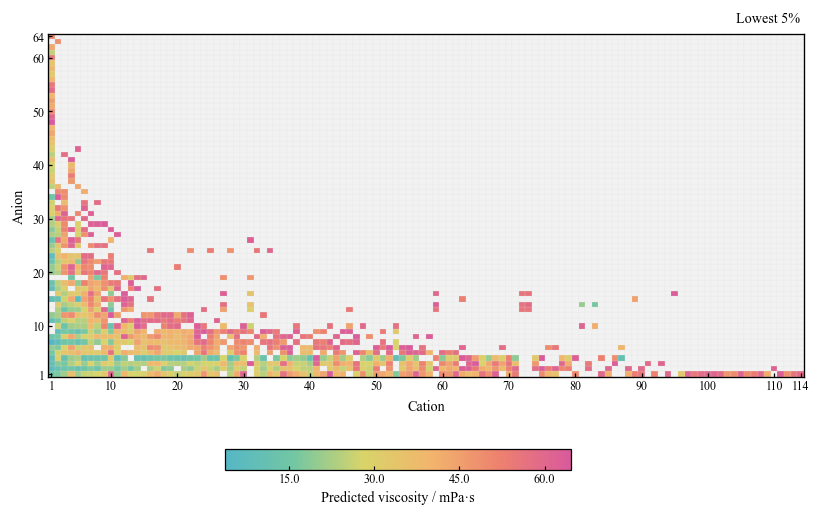

已保存图片及图数据：Lowest5pct_nonhalide_candidate_cation_anion_predicted_viscosity_heatmap
PNG：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\PNG\Lowest5pct_nonhalide_candidate_cation_anion_predicted_viscosity_heatmap.png
SVG：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\SVG\Lowest5pct_nonhalide_candidate_cation_anion_predicted_viscosity_heatmap.svg
PDF：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\PDF\Lowest5pct_nonhalide_candidate_cation_anion_predicted_viscosity_heatmap.pdf
CSV：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\figures\CSV\Lowest5pct_nonhalide_candidate_cation_anion_predicted_viscosity_heatmap.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_vis

,candidate_set,candidate_set_display,candidate_count,axis_ordering,cation_axis_count,anion_axis_count,matrix_rows,matrix_columns,occupied_cell_count,figure_width_inch,figure_height_inch,minimum_pred_eta_mPa_s,maximum_pred_eta_mPa_s,png_path,svg_path,pdf_path,csv_path
0,Lowest5pct,Lowest 5%,854,frequency_desc_then_canonical_smiles_asc,114,64,64,114,854,7.2,4.3,3.756926,64.597548,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...


,check_item,expected,actual,passed
0,预测黏度矩阵形状,"[64, 114]","[64, 114]",True
1,有效候选单元格数量,854,854,True
2,存在性矩阵合计,854,854,True
3,热图阳离子数量,114,114,True
4,热图阴离子数量,64,64,True
5,图宽设置,7.2,7.2,True
6,图高设置,4.3,4.3,True


In [15]:
# Cell 9 | 绘制频次排序的最低5%候选预测黏度热图

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import (
    LinearSegmentedColormap,
    Normalize,
)
from matplotlib.ticker import (
    FormatStrFormatter,
    MaxNLocator,
)


# ============================================================
# 1. 检查必要对象
# ============================================================

required_cell9_objects = [
    "HEATMAP_PREPARATION_RESULTS",
    "HEATMAP_CATION_COUNT",
    "HEATMAP_ANION_COUNT",
    "heatmap_preparation_manifest_path",
    "save_figure",
    "save_table",
    "save_json",
    "sha256_file",
    "GENERATED_FIGURE_RECORDS",
    "GENERATED_TABLE_RECORDS",
    "GENERATED_LOG_RECORDS",
]

missing_cell9_objects = [
    object_name
    for object_name in required_cell9_objects
    if object_name not in globals()
]

if missing_cell9_objects:
    raise RuntimeError(
        "Cell 9缺少必要上游对象。"
        "\n请确认已经运行修改后的Cell 8。"
        f"\n缺少对象：{missing_cell9_objects}"
    )


# ============================================================
# 2. 输出名称和图尺寸
# ============================================================

HEATMAP_FIGURE_NAME = (
    "Lowest5pct_nonhalide_candidate_"
    "cation_anion_predicted_viscosity_heatmap"
)

HEATMAP_FIGURE_WIDTH_INCH = 7.20
HEATMAP_FIGURE_HEIGHT_INCH = 4.30

CATION_MAJOR_TICK_INTERVAL = 10
ANION_MAJOR_TICK_INTERVAL = 10


# ============================================================
# 3. 清理旧记录
# ============================================================

GENERATED_FIGURE_RECORDS[:] = [
    record
    for record in GENERATED_FIGURE_RECORDS
    if record.get("figure_name")
    != HEATMAP_FIGURE_NAME
]

CELL9_TABLE_FILENAMES = {
    "cation_anion_heatmap_figure_summary.csv",
    "cation_anion_heatmap_figure_integrity_audit.csv",
}

GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if record.get("filename")
    not in CELL9_TABLE_FILENAMES
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if record.get("filename")
    != "cation_anion_heatmap_figure_manifest.json"
]


# ============================================================
# 4. 配色
# ============================================================

SONG_STYLE_HEATMAP_COLORS = [
    "#55B7C5",
    "#73C7A3",
    "#D8D46A",
    "#F2B46D",
    "#ED806F",
    "#D95A9D",
]

SONG_STYLE_HEATMAP_CMAP = (
    LinearSegmentedColormap.from_list(
        name="lowest5pct_viscosity",
        colors=SONG_STYLE_HEATMAP_COLORS,
        N=256,
    )
)

SONG_STYLE_HEATMAP_CMAP.set_bad(
    "#F2F2F2"
)


# ============================================================
# 5. 读取热图矩阵
# ============================================================

heatmap_result = (
    HEATMAP_PREPARATION_RESULTS[
        "Lowest5pct"
    ]
)

eta_matrix_df = (
    heatmap_result["pred_eta_matrix"]
)

presence_matrix_df = (
    heatmap_result["presence_matrix"]
)

heatmap_points_df = (
    heatmap_result["heatmap_points"]
)

matrix = eta_matrix_df.to_numpy(
    dtype=float
)

presence_matrix = (
    presence_matrix_df.to_numpy(
        dtype=int
    )
)

masked_matrix = np.ma.masked_invalid(
    matrix
)

valid_values = matrix[
    np.isfinite(matrix)
]


# ============================================================
# 6. 绘图前审计
# ============================================================

expected_matrix_shape = (
    HEATMAP_ANION_COUNT,
    HEATMAP_CATION_COUNT,
)

if expected_matrix_shape != (64, 114):
    raise RuntimeError(
        "热图坐标数量不是预期的64×114。"
        f"\n实际形状：{expected_matrix_shape}"
    )

if matrix.shape != expected_matrix_shape:
    raise RuntimeError(
        "预测黏度矩阵形状不正确。"
        f"\n预期：{expected_matrix_shape}"
        f"\n实际：{matrix.shape}"
    )

if presence_matrix.shape != expected_matrix_shape:
    raise RuntimeError(
        "存在性矩阵形状不正确。"
    )

if valid_values.size != 854:
    raise RuntimeError(
        "有效候选单元格数量不是854。"
        f"\n实际数量：{valid_values.size}"
    )

if int(presence_matrix.sum()) != 854:
    raise RuntimeError(
        "存在性矩阵候选数量不是854。"
    )


# ============================================================
# 7. 颜色范围
# ============================================================

value_min = float(valid_values.min())
value_max = float(valid_values.max())

if np.isclose(value_min, value_max):
    value_max = value_min + 1e-9

normalization = Normalize(
    vmin=value_min,
    vmax=value_max,
)


# ============================================================
# 8. 建立期刊尺寸画布
# ============================================================

figure = plt.figure(
    figsize=(
        HEATMAP_FIGURE_WIDTH_INCH,
        HEATMAP_FIGURE_HEIGHT_INCH,
    )
)

axis = figure.add_axes(
    [
        0.095,
        0.275,
        0.875,
        0.665,
    ]
)

colorbar_axis = figure.add_axes(
    [
        0.300,
        0.095,
        0.400,
        0.040,
    ]
)


# ============================================================
# 9. 绘制热图
# ============================================================

x_edges = np.arange(
    HEATMAP_CATION_COUNT + 1,
    dtype=float,
)

y_edges = np.arange(
    HEATMAP_ANION_COUNT + 1,
    dtype=float,
)

heatmap_mesh = axis.pcolormesh(
    x_edges,
    y_edges,
    masked_matrix,
    cmap=SONG_STYLE_HEATMAP_CMAP,
    norm=normalization,
    shading="flat",
    edgecolors="#E2E2E2",
    linewidth=0.10,
    antialiased=True,
)

axis.set_xlim(
    0,
    HEATMAP_CATION_COUNT,
)

axis.set_ylim(
    0,
    HEATMAP_ANION_COUNT,
)

axis.set_aspect("auto")

axis.set_xlabel(
    "Cation",
    fontsize=8.5,
    family="Times New Roman",
    labelpad=4.0,
)

axis.set_ylabel(
    "Anion",
    fontsize=8.5,
    family="Times New Roman",
    labelpad=4.0,
)


# ============================================================
# 10. 构建坐标刻度
# ============================================================

def build_serial_ticks(
    maximum_number,
    interval,
):
    tick_values = [1]

    tick_values.extend(
        range(
            interval,
            maximum_number + 1,
            interval,
        )
    )

    if tick_values[-1] != maximum_number:
        tick_values.append(maximum_number)

    return np.array(
        sorted(set(tick_values)),
        dtype=int,
    )


cation_tick_numbers = build_serial_ticks(
    HEATMAP_CATION_COUNT,
    CATION_MAJOR_TICK_INTERVAL,
)

anion_tick_numbers = build_serial_ticks(
    HEATMAP_ANION_COUNT,
    ANION_MAJOR_TICK_INTERVAL,
)

axis.set_xticks(
    cation_tick_numbers - 0.5
)

axis.set_xticklabels(
    [
        str(value)
        for value in cation_tick_numbers
    ],
    fontsize=7.2,
    family="Times New Roman",
)

axis.set_yticks(
    anion_tick_numbers - 0.5
)

axis.set_yticklabels(
    [
        str(value)
        for value in anion_tick_numbers
    ],
    fontsize=7.2,
    family="Times New Roman",
)


# ============================================================
# 11. 坐标轴样式
# ============================================================

axis.grid(False)

axis.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=2.3,
    width=0.75,
    pad=2.0,
    top=False,
    right=False,
)

for side in [
    "top",
    "right",
    "bottom",
    "left",
]:
    axis.spines[side].set_visible(True)
    axis.spines[side].set_linewidth(0.80)


axis.text(
    0.995,
    1.025,
    "Lowest 5%",
    transform=axis.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.5,
    family="Times New Roman",
)


# ============================================================
# 12. 水平色条
# ============================================================

colorbar = figure.colorbar(
    heatmap_mesh,
    cax=colorbar_axis,
    orientation="horizontal",
)

colorbar.set_label(
    "Predicted viscosity / mPa·s",
    family="Times New Roman",
    fontsize=8.5,
    labelpad=3.0,
)

colorbar.locator = MaxNLocator(
    nbins=5
)

colorbar.formatter = FormatStrFormatter(
    "%.1f"
)

colorbar.update_ticks()

colorbar.ax.tick_params(
    labelsize=7.3,
    direction="in",
    length=2.3,
    width=0.70,
    pad=2.0,
)

for tick_label in (
    colorbar.ax.get_xticklabels()
):
    tick_label.set_fontfamily(
        "Times New Roman"
    )

colorbar.outline.set_linewidth(0.75)


# ============================================================
# 13. 保存图片
# ============================================================

heatmap_figure_record = save_figure(
    figure=figure,
    base_name=HEATMAP_FIGURE_NAME,
    data_df=heatmap_points_df,
    tight=False,
)

heatmap_figure_record.update(
    {
        "candidate_set": "Lowest5pct",
        "candidate_set_display": "Lowest 5%",
        "chart_type": (
            "frequency_order_serial_"
            "number_heatmap"
        ),
        "axis_ordering": (
            "frequency_desc_then_"
            "canonical_smiles_asc"
        ),
        "viscosity_rank_used_for_axis_order": (
            False
        ),
        "matrix_shape": [
            HEATMAP_ANION_COUNT,
            HEATMAP_CATION_COUNT,
        ],
        "candidate_cell_count": 854,
        "figure_width_inch": (
            HEATMAP_FIGURE_WIDTH_INCH
        ),
        "figure_height_inch": (
            HEATMAP_FIGURE_HEIGHT_INCH
        ),
        "cation_major_tick_interval": (
            CATION_MAJOR_TICK_INTERVAL
        ),
        "anion_major_tick_interval": (
            ANION_MAJOR_TICK_INTERVAL
        ),
        "color_scale_min": value_min,
        "color_scale_max": value_max,
        "png_dpi": 300,
        "embedded_title": False,
    }
)


# ============================================================
# 14. 图片审计
# ============================================================

heatmap_figure_audit_df = pd.DataFrame(
    [
        {
            "check_item": "预测黏度矩阵形状",
            "expected": "[64, 114]",
            "actual": str(list(matrix.shape)),
            "passed": (
                matrix.shape == (64, 114)
            ),
        },
        {
            "check_item": "有效候选单元格数量",
            "expected": 854,
            "actual": int(valid_values.size),
            "passed": (
                valid_values.size == 854
            ),
        },
        {
            "check_item": "存在性矩阵合计",
            "expected": 854,
            "actual": int(
                presence_matrix.sum()
            ),
            "passed": (
                int(presence_matrix.sum())
                == 854
            ),
        },
        {
            "check_item": "热图阳离子数量",
            "expected": 114,
            "actual": HEATMAP_CATION_COUNT,
            "passed": (
                HEATMAP_CATION_COUNT == 114
            ),
        },
        {
            "check_item": "热图阴离子数量",
            "expected": 64,
            "actual": HEATMAP_ANION_COUNT,
            "passed": (
                HEATMAP_ANION_COUNT == 64
            ),
        },
        {
            "check_item": "图宽设置",
            "expected": (
                HEATMAP_FIGURE_WIDTH_INCH
            ),
            "actual": float(
                figure.get_figwidth()
            ),
            "passed": bool(
                np.isclose(
                    figure.get_figwidth(),
                    HEATMAP_FIGURE_WIDTH_INCH,
                    atol=1e-12,
                    rtol=0.0,
                )
            ),
        },
        {
            "check_item": "图高设置",
            "expected": (
                HEATMAP_FIGURE_HEIGHT_INCH
            ),
            "actual": float(
                figure.get_figheight()
            ),
            "passed": bool(
                np.isclose(
                    figure.get_figheight(),
                    HEATMAP_FIGURE_HEIGHT_INCH,
                    atol=1e-12,
                    rtol=0.0,
                )
            ),
        },
    ]
)

if not heatmap_figure_audit_df[
    "passed"
].all():
    display(heatmap_figure_audit_df)

    raise RuntimeError(
        "Cell 9热图图片审计未通过。"
    )


# ============================================================
# 15. 保存汇总和manifest
# ============================================================

heatmap_figure_summary_df = pd.DataFrame(
    [
        {
            "candidate_set": "Lowest5pct",
            "candidate_set_display": "Lowest 5%",
            "candidate_count": 854,
            "axis_ordering": (
                "frequency_desc_then_"
                "canonical_smiles_asc"
            ),
            "cation_axis_count": (
                HEATMAP_CATION_COUNT
            ),
            "anion_axis_count": (
                HEATMAP_ANION_COUNT
            ),
            "matrix_rows": (
                HEATMAP_ANION_COUNT
            ),
            "matrix_columns": (
                HEATMAP_CATION_COUNT
            ),
            "occupied_cell_count": 854,
            "figure_width_inch": (
                HEATMAP_FIGURE_WIDTH_INCH
            ),
            "figure_height_inch": (
                HEATMAP_FIGURE_HEIGHT_INCH
            ),
            "minimum_pred_eta_mPa_s": (
                value_min
            ),
            "maximum_pred_eta_mPa_s": (
                value_max
            ),
            "png_path": (
                heatmap_figure_record[
                    "png_path"
                ]
            ),
            "svg_path": (
                heatmap_figure_record[
                    "svg_path"
                ]
            ),
            "pdf_path": (
                heatmap_figure_record[
                    "pdf_path"
                ]
            ),
            "csv_path": (
                heatmap_figure_record[
                    "csv_path"
                ]
            ),
        }
    ]
)

heatmap_figure_summary_path = save_table(
    heatmap_figure_summary_df,
    "cation_anion_heatmap_figure_summary.csv",
    index=False,
)

heatmap_figure_audit_path = save_table(
    heatmap_figure_audit_df,
    (
        "cation_anion_heatmap_"
        "figure_integrity_audit.csv"
    ),
    index=False,
)


heatmap_figure_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "lowest5pct_heatmap_"
        "figure_completed"
    ),
    "candidate_set": "Lowest5pct",
    "candidate_set_display": "Lowest 5%",
    "candidate_count": 854,
    "heatmap_design": (
        "journal_width_frequency_"
        "ordered_observed_ion_axes"
    ),
    "axis_definition": {
        "cation_count": (
            HEATMAP_CATION_COUNT
        ),
        "anion_count": (
            HEATMAP_ANION_COUNT
        ),
        "matrix_shape": [
            HEATMAP_ANION_COUNT,
            HEATMAP_CATION_COUNT,
        ],
        "ordering": (
            "frequency_desc_then_"
            "canonical_smiles_asc"
        ),
        "viscosity_rank_used": False,
    },
    "figure_dimensions": {
        "width_inch": (
            HEATMAP_FIGURE_WIDTH_INCH
        ),
        "height_inch": (
            HEATMAP_FIGURE_HEIGHT_INCH
        ),
        "width_mm": (
            HEATMAP_FIGURE_WIDTH_INCH
            * 25.4
        ),
        "height_mm": (
            HEATMAP_FIGURE_HEIGHT_INCH
            * 25.4
        ),
        "png_dpi": 300,
    },
    "source_manifest": {
        "path": str(
            heatmap_preparation_manifest_path.resolve()
        ),
        "sha256": sha256_file(
            heatmap_preparation_manifest_path
        ),
    },
    "figure_output": heatmap_figure_record,
    "table_outputs": {
        "figure_summary": {
            "path": str(
                heatmap_figure_summary_path.resolve()
            ),
            "sha256": sha256_file(
                heatmap_figure_summary_path
            ),
        },
        "integrity_audit": {
            "path": str(
                heatmap_figure_audit_path.resolve()
            ),
            "sha256": sha256_file(
                heatmap_figure_audit_path
            ),
        },
    },
    "audit_summary": {
        "total_checks": int(
            len(heatmap_figure_audit_df)
        ),
        "failed_checks": int(
            (
                ~heatmap_figure_audit_df[
                    "passed"
                ]
            ).sum()
        ),
        "all_passed": bool(
            heatmap_figure_audit_df[
                "passed"
            ].all()
        ),
    },
}

heatmap_figure_manifest_path = save_json(
    heatmap_figure_manifest,
    "cation_anion_heatmap_figure_manifest.json",
)


print("=" * 100)
print(
    "Cell 9频次排序最低5%组合热图生成完成 ✓"
)
print("=" * 100)

print(
    "矩阵形状："
    f"{HEATMAP_ANION_COUNT} × "
    f"{HEATMAP_CATION_COUNT}"
)

print(
    "图片尺寸："
    f"{HEATMAP_FIGURE_WIDTH_INCH:.2f} × "
    f"{HEATMAP_FIGURE_HEIGHT_INCH:.2f} in"
)

print(
    "PNG分辨率：300 dpi"
)

print(
    "\nPNG路径："
)

print(
    heatmap_figure_record["png_path"]
)

display(heatmap_figure_summary_df)
display(heatmap_figure_audit_df)

In [17]:
# Cell 10 | 审计最低5%结构分析全部正式输出

from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. 检查必要对象
# ============================================================

required_cell10_objects = [
    "FINAL_CLASSIFIED_CANDIDATE_TABLES",
    "FINAL_LOWEST5PCT_CLASSIFIED_DF",
    "FORMAL_COMBINED_ION_TYPE_FREQUENCY_DF",
    "heatmap_cation_axis_df",
    "heatmap_anion_axis_df",
    "HEATMAP_CATION_COUNT",
    "HEATMAP_ANION_COUNT",
    "classified_candidate_set_manifest_path",
    "cation_type_frequency_manifest_path",
    "anion_type_frequency_manifest_path",
    "heatmap_preparation_manifest_path",
    "heatmap_figure_manifest_path",
    "GENERATED_FIGURE_RECORDS",
    "GENERATED_TABLE_RECORDS",
    "GENERATED_LOG_RECORDS",
    "TABLE_DIR",
    "OUT_ROOT",
    "TOTAL_NONHALIDE_CANDIDATE_COUNT",
    "COMBINED_FIGURE_NAME",
    "load_json",
    "save_table",
    "save_json",
    "sha256_file",
]

missing_cell10_objects = [
    object_name
    for object_name in required_cell10_objects
    if object_name not in globals()
]

if missing_cell10_objects:
    raise RuntimeError(
        "Cell 10缺少必要对象。"
        "\n请确认已经依次运行修改后的Cell 7～Cell 9。"
        f"\n缺少对象：{missing_cell10_objects}"
    )


# ============================================================
# 2. 最终审计函数
# ============================================================

final_audit_records = []


def add_final_check(
    section,
    check_item,
    actual,
    expected,
    note="",
):
    final_audit_records.append(
        {
            "section": section,
            "check_item": check_item,
            "expected": str(expected),
            "actual": str(actual),
            "passed": bool(
                actual == expected
            ),
            "note": note,
        }
    )


# ============================================================
# 3. 候选范围审计
# ============================================================

add_final_check(
    section="candidate_scope",
    check_item="正式候选集",
    actual=list(
        FINAL_CLASSIFIED_CANDIDATE_TABLES.keys()
    ),
    expected=["Lowest5pct"],
)

add_final_check(
    section="candidate_scope",
    check_item="最低5%候选数量",
    actual=len(
        FINAL_LOWEST5PCT_CLASSIFIED_DF
    ),
    expected=854,
)

add_final_check(
    section="candidate_scope",
    check_item="最低5%排名上限",
    actual=int(
        FINAL_LOWEST5PCT_CLASSIFIED_DF[
            "rank_viscosity_nonhalide"
        ].max()
    ),
    expected=854,
)


# ============================================================
# 4. 组合图Others审计
# ============================================================

cation_others_rows = (
    FORMAL_COMBINED_ION_TYPE_FREQUENCY_DF.loc[
        (
            FORMAL_COMBINED_ION_TYPE_FREQUENCY_DF[
                "ion_role"
            ].eq("cation")
        )
        & (
            FORMAL_COMBINED_ION_TYPE_FREQUENCY_DF[
                "original_type"
            ].eq("Others")
        )
    ]
)

add_final_check(
    section="combined_frequency",
    check_item="阳离子Others行数",
    actual=len(cation_others_rows),
    expected=1,
)

if len(cation_others_rows) == 1:
    add_final_check(
        section="combined_frequency",
        check_item="阳离子Others频次",
        actual=int(
            cation_others_rows[
                "frequency"
            ].iloc[0]
        ),
        expected=37,
    )

    add_final_check(
        section="combined_frequency",
        check_item="阳离子Others合并类型数",
        actual=int(
            cation_others_rows[
                "included_type_count"
            ].iloc[0]
        ),
        expected=3,
    )


# ============================================================
# 5. 热图坐标审计
# ============================================================

add_final_check(
    section="heatmap_axis",
    check_item="热图阳离子数量",
    actual=HEATMAP_CATION_COUNT,
    expected=114,
)

add_final_check(
    section="heatmap_axis",
    check_item="热图阴离子数量",
    actual=HEATMAP_ANION_COUNT,
    expected=64,
)

add_final_check(
    section="heatmap_axis",
    check_item="阳离子频次合计",
    actual=int(
        heatmap_cation_axis_df[
            "count_in_lowest5pct"
        ].sum()
    ),
    expected=854,
)

add_final_check(
    section="heatmap_axis",
    check_item="阴离子频次合计",
    actual=int(
        heatmap_anion_axis_df[
            "count_in_lowest5pct"
        ].sum()
    ),
    expected=854,
)

add_final_check(
    section="heatmap_axis",
    check_item="阳离子编号连续",
    actual=(
        heatmap_cation_axis_df[
            "heatmap_cation_number"
        ].tolist()
        == list(range(1, 115))
    ),
    expected=True,
)

add_final_check(
    section="heatmap_axis",
    check_item="阴离子编号连续",
    actual=(
        heatmap_anion_axis_df[
            "heatmap_anion_number"
        ].tolist()
        == list(range(1, 65))
    ),
    expected=True,
)


# ============================================================
# 6. Manifest审计
# ============================================================

manifest_checks = [
    (
        classified_candidate_set_manifest_path,
        (
            "lowest5pct_candidate_set_"
            "prepared_and_audited"
        ),
    ),
    (
        cation_type_frequency_manifest_path,
        (
            "lowest5pct_cation_type_"
            "frequency_completed"
        ),
    ),
    (
        anion_type_frequency_manifest_path,
        (
            "lowest5pct_anion_and_combined_"
            "type_frequency_completed"
        ),
    ),
    (
        heatmap_preparation_manifest_path,
        (
            "lowest5pct_frequency_order_"
            "heatmap_data_prepared"
        ),
    ),
    (
        heatmap_figure_manifest_path,
        (
            "lowest5pct_heatmap_"
            "figure_completed"
        ),
    ),
]

for manifest_path, expected_status in manifest_checks:
    manifest_exists = (
        manifest_path.is_file()
    )

    add_final_check(
        section="manifest",
        check_item=(
            f"{manifest_path.name}存在"
        ),
        actual=manifest_exists,
        expected=True,
    )

    if not manifest_exists:
        continue

    manifest_data = load_json(
        manifest_path
    )

    add_final_check(
        section="manifest",
        check_item=(
            f"{manifest_path.name}状态"
        ),
        actual=manifest_data["status"],
        expected=expected_status,
    )

    if (
        "audit_summary"
        in manifest_data
    ):
        add_final_check(
            section="manifest",
            check_item=(
                f"{manifest_path.name}"
                "失败项目数"
            ),
            actual=manifest_data[
                "audit_summary"
            ]["failed_checks"],
            expected=0,
        )


# ============================================================
# 7. 正式图片审计
# ============================================================

EXPECTED_FIGURE_NAMES = {
    (
        "Lowest5pct_nonhalide_candidate_"
        "cation_type_frequency"
    ),
    (
        "Lowest5pct_nonhalide_candidate_"
        "anion_type_frequency"
    ),
    (
        "Lowest5pct_nonhalide_candidate_"
        "cation_anion_type_frequency_combined"
    ),
    (
        "Lowest5pct_nonhalide_candidate_"
        "cation_anion_predicted_viscosity_heatmap"
    ),
}

actual_figure_names = {
    record["figure_name"]
    for record in GENERATED_FIGURE_RECORDS
    if record.get("figure_name")
    in EXPECTED_FIGURE_NAMES
}

add_final_check(
    section="figures",
    check_item="正式图片数量",
    actual=len(actual_figure_names),
    expected=4,
)

add_final_check(
    section="figures",
    check_item="正式图片名称",
    actual=actual_figure_names,
    expected=EXPECTED_FIGURE_NAMES,
)

for figure_record in GENERATED_FIGURE_RECORDS:
    figure_name = figure_record.get(
        "figure_name"
    )

    if figure_name not in EXPECTED_FIGURE_NAMES:
        continue

    for output_kind in [
        "png",
        "svg",
        "pdf",
        "csv",
    ]:
        output_path = Path(
            figure_record[
                f"{output_kind}_path"
            ]
        )

        add_final_check(
            section="figure_files",
            check_item=(
                f"{figure_name} "
                f"{output_kind.upper()}存在且非空"
            ),
            actual=bool(
                output_path.is_file()
                and output_path.stat().st_size
                > 0
            ),
            expected=True,
        )


# ============================================================
# 8. 核心表格审计
# ============================================================

required_table_filenames = {
    (
        "lowest5pct_nonhalide_candidates_"
        "with_ion_classification.csv"
    ),
    "classified_candidate_set_summary.csv",
    "classified_candidate_set_integrity_audit.csv",
    "cation_type_frequency_lowest5pct.csv",
    "anion_type_frequency_lowest5pct.csv",
    (
        "lowest5pct_cation_anion_"
        "type_frequency_compact.csv"
    ),
    (
        "lowest5pct_cation_anion_"
        "type_frequency_compact_audit.csv"
    ),
    (
        "lowest5pct_cation_axis_"
        "frequency_order_for_heatmap.csv"
    ),
    (
        "lowest5pct_anion_axis_"
        "frequency_order_for_heatmap.csv"
    ),
    (
        "lowest5pct_frequency_order_"
        "pred_eta_matrix.csv"
    ),
    (
        "lowest5pct_frequency_order_"
        "presence_matrix.csv"
    ),
    "lowest5pct_heatmap_points.csv",
    (
        "cation_anion_heatmap_"
        "preparation_summary.csv"
    ),
    (
        "cation_anion_heatmap_"
        "preparation_integrity_audit.csv"
    ),
    "cation_anion_heatmap_figure_summary.csv",
    (
        "cation_anion_heatmap_"
        "figure_integrity_audit.csv"
    ),
}

for filename in sorted(
    required_table_filenames
):
    file_path = TABLE_DIR / filename

    add_final_check(
        section="core_tables",
        check_item=(
            f"{filename}存在且非空"
        ),
        actual=bool(
            file_path.is_file()
            and file_path.stat().st_size
            > 0
        ),
        expected=True,
    )


# ============================================================
# 9. 旧热图坐标文件应被删除
# ============================================================

obsolete_heatmap_filenames = {
    "full_nonhalide_cation_axis_for_heatmap.csv",
    "full_nonhalide_anion_axis_for_heatmap.csv",
    "lowest5pct_full_pred_eta_matrix.csv",
    "lowest5pct_full_presence_matrix.csv",
}

for filename in sorted(
    obsolete_heatmap_filenames
):
    add_final_check(
        section="obsolete_heatmap_outputs",
        check_item=f"{filename}已删除",
        actual=not (
            TABLE_DIR / filename
        ).exists(),
        expected=True,
    )


# ============================================================
# 10. 检查Top20、Top50和Top100残留
# ============================================================

deprecated_top_files = []

for output_path in sorted(
    path
    for path in OUT_ROOT.rglob("*")
    if path.is_file()
):
    filename_lower = (
        output_path.name.lower()
    )

    if any(
        marker in filename_lower
        for marker in (
            "top20",
            "top50",
            "top100",
        )
    ):
        deprecated_top_files.append(
            str(output_path)
        )

add_final_check(
    section="deprecated_outputs",
    check_item=(
        "Top20、Top50和Top100残留文件数量"
    ),
    actual=len(deprecated_top_files),
    expected=0,
    note=" | ".join(
        deprecated_top_files
    ),
)


# ============================================================
# 11. 保存最终审计
# ============================================================

analysis_output_integrity_audit_df = (
    pd.DataFrame(final_audit_records)
)

analysis_output_integrity_audit_df[
    "passed"
] = (
    analysis_output_integrity_audit_df[
        "passed"
    ].astype(bool)
)

failed_final_audit_df = (
    analysis_output_integrity_audit_df.loc[
        ~analysis_output_integrity_audit_df[
            "passed"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

GENERATED_TABLE_RECORDS[:] = [
    record
    for record in GENERATED_TABLE_RECORDS
    if record.get("filename")
    not in {
        "analysis_output_integrity_audit.csv",
        "analysis_output_file_inventory.csv",
    }
]

GENERATED_LOG_RECORDS[:] = [
    record
    for record in GENERATED_LOG_RECORDS
    if record.get("filename")
    != "analysis_output_completion_manifest.json"
]

analysis_output_integrity_audit_path = (
    save_table(
        analysis_output_integrity_audit_df,
        "analysis_output_integrity_audit.csv",
        index=False,
    )
)

if not failed_final_audit_df.empty:
    display(failed_final_audit_df)

    raise RuntimeError(
        "Cell 10最终输出完整性审计未通过。"
    )


# ============================================================
# 12. 建立全部文件清单
# ============================================================

output_file_inventory_records = []

for output_file in sorted(
    path
    for path in OUT_ROOT.rglob("*")
    if path.is_file()
):
    output_file_inventory_records.append(
        {
            "relative_path": str(
                output_file.relative_to(
                    OUT_ROOT
                )
            ),
            "filename": output_file.name,
            "suffix": (
                output_file.suffix.lower()
            ),
            "size_bytes": int(
                output_file.stat().st_size
            ),
            "sha256": sha256_file(
                output_file
            ),
        }
    )

analysis_output_file_inventory_df = (
    pd.DataFrame(
        output_file_inventory_records
    )
)

analysis_output_file_inventory_path = (
    save_table(
        analysis_output_file_inventory_df,
        "analysis_output_file_inventory.csv",
        index=False,
    )
)


# ============================================================
# 13. 保存最终完成manifest
# ============================================================

analysis_output_completion_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": (
        "lowest5pct_only_structure_"
        "analysis_completed_and_audited"
    ),
    "output_root": str(
        OUT_ROOT.resolve()
    ),
    "formal_candidate_definition": {
        "candidate_set": "Lowest5pct",
        "candidate_set_display": "Lowest 5%",
        "total_nonhalide_candidates": (
            TOTAL_NONHALIDE_CANDIDATE_COUNT
        ),
        "selection_fraction": 0.05,
        "rounding_rule": "floor",
        "candidate_count": 854,
        "rank_range": [1, 854],
        "pred_eta_upper_limit_mPa_s": float(
            FINAL_LOWEST5PCT_CLASSIFIED_DF[
                "pred_eta_mPa_s"
            ].max()
        ),
        "T_K": 298.15,
        "P_bar": 1.01325,
    },
    "combined_frequency_definition": {
        "cation_top_n": 6,
        "cation_others_frequency": 37,
        "cation_others_type_count": 3,
        "anion_top_n": 8,
        "anion_others_frequency": 133,
    },
    "heatmap_definition": {
        "candidate_count": 854,
        "cation_axis_count": 114,
        "anion_axis_count": 64,
        "matrix_shape": [64, 114],
        "axis_ordering": (
            "frequency_desc_then_"
            "canonical_smiles_asc"
        ),
        "viscosity_rank_used_for_axis_order": (
            False
        ),
    },
    "discarded_candidate_scopes": [
        "Top20",
        "Top50",
        "Top100",
    ],
    "formal_outputs": {
        "main_text_recommended": {
            "ion_type_frequency_combined": (
                "Lowest5pct_nonhalide_candidate_"
                "cation_anion_type_frequency_combined"
            ),
            "cation_anion_heatmap": (
                "Lowest5pct_nonhalide_candidate_"
                "cation_anion_predicted_viscosity_heatmap"
            ),
        },
        "heatmap_axis_mapping_tables": {
            "cation": (
                "lowest5pct_cation_axis_"
                "frequency_order_for_heatmap.csv"
            ),
            "anion": (
                "lowest5pct_anion_axis_"
                "frequency_order_for_heatmap.csv"
            ),
        },
    },
    "figure_summary": {
        "total_figure_count": 4,
        "main_text_recommended_count": 2,
        "complete_frequency_figure_count": 2,
        "formats_per_figure": [
            "PNG",
            "SVG",
            "PDF",
            "CSV",
        ],
        "png_dpi": 300,
    },
    "deprecated_output_audit": {
        "Top20_file_count": 0,
        "Top50_file_count": 0,
        "Top100_file_count": 0,
        "obsolete_heatmap_axis_file_count": 0,
    },
    "audit_summary": {
        "total_checks": int(
            len(
                analysis_output_integrity_audit_df
            )
        ),
        "passed_checks": int(
            analysis_output_integrity_audit_df[
                "passed"
            ].sum()
        ),
        "failed_checks": int(
            (
                ~analysis_output_integrity_audit_df[
                    "passed"
                ]
            ).sum()
        ),
        "all_passed": bool(
            analysis_output_integrity_audit_df[
                "passed"
            ].all()
        ),
    },
    "audit_output": {
        "path": str(
            analysis_output_integrity_audit_path.resolve()
        ),
        "sha256": sha256_file(
            analysis_output_integrity_audit_path
        ),
    },
    "file_inventory": {
        "path": str(
            analysis_output_file_inventory_path.resolve()
        ),
        "sha256": sha256_file(
            analysis_output_file_inventory_path
        ),
        "file_count_before_final_manifest": int(
            len(
                analysis_output_file_inventory_df
            )
        ),
    },
}

analysis_output_completion_manifest_path = (
    save_json(
        analysis_output_completion_manifest,
        (
            "analysis_output_"
            "completion_manifest.json"
        ),
    )
)


print("=" * 100)
print(
    "Cell 10最低5%结构分析最终审计完成 ✓"
)
print("=" * 100)

print(
    "阳离子Others频次：37"
)

print(
    "热图矩阵：64 × 114"
)

print(
    "热图坐标排序："
    "最低5%内频次降序＋规范SMILES升序"
)

print(
    "正式图片数量：4"
)

print(
    "Top20、Top50和Top100残留文件数量：0"
)

print(
    "\n最终输出目录："
)

print(OUT_ROOT)

print(
    "\n最终manifest："
)

print(
    analysis_output_completion_manifest_path
)

已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\analysis_output_integrity_audit.csv
已保存表格：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\tables\analysis_output_file_inventory.csv
已保存日志：D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\analysis_output_completion_manifest.json
Cell 10最低5%结构分析最终审计完成 ✓
阳离子Others频次：37
热图矩阵：64 × 114
热图坐标排序：最低5%内频次降序＋规范SMILES升序
正式图片数量：4
Top20、Top50和Top100残留文件数量：0

最终输出目录：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis

最终manifest：
D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\mpnn_low_viscosity_structure_analysis\logs\analysis_output_completion_manifest.json
